# ML classification of E.coli serotype using Large Language Model

### 1. Import Packages

In [2]:
import numpy as np
import re
from IPython.lib.deepreload import reload
import pandas as pd
import logomaker as lm
import os, glob, subprocess, math, pickle, time, copy, seqlogo, json
from dna_features_viewer import GraphicFeature, GraphicRecord
from sklearn.metrics import classification_report
import matplotlib.gridspec as gridspec
from Bio import SeqIO, AlignIO, SearchIO
from Bio.Align import MultipleSeqAlignment
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio.SeqRecord import SeqRecord
import matplotlib.pyplot as plt
from multiprocessing import Pool
from subprocess import Popen
from dna_features_viewer import BiopythonTranslator
from dna_features_viewer import GraphicFeature, GraphicRecord
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from multiscorer.multiscorer import MultiScorer
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn import svm
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn import tree
from sklearn import neighbors
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso, LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import entropy
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
from matplotlib import rcParams
from sklearnex import patch_sklearn
from sklearn.model_selection import StratifiedShuffleSplit

In [4]:
patch_sklearn()
rcParams['figure.figsize'] = 8,8

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


### 2. To use MBGD ortholog definition, import the parsed data file

In [5]:
with open("2-1.split/GeneMeta.pickle", "rb") as infile:
    GeneMeta = pickle.load(infile)
with open("2-1.split/Gene2Cluster.pickle", "rb") as infile:
    Gene2Cluster = pickle.load(infile)
with open("2-1.split/ClusterMeta.pickle", "rb") as infile:
    ClusterMeta = pickle.load(infile)

### 3. Get the real serotype annotation information

In [6]:
meta = pd.read_csv("meta.csv", sep="\t", header=None)
meta.columns = ["acc", "O", "H"]
meta

,acc,O,H
0,ESC_AA7966AA_AS,O113,H21
1,ESC_AA8101AA_AS,O157,H7
2,ESC_AA8232AA_AS,O157,H7
3,ESC_AA8336AA_AS,O157,H7
4,ESC_AA8426AA_AS,O104,H4
...,...,...,...
9556,ESC_ZB9919AA_AS,O23,H15
9557,ESC_ZB9920AA_AS,O76,H19
9558,ESC_ZB9921AA_AS,O84,H2
9559,ESC_ZB9923AA_AS,O126,H27


In [7]:
meta_name = pd.read_csv("meta_name.csv", sep="\t", header=None)
meta_name.columns = ["entero_acc", "NCBI_acc", "PRJNA"]
meta_name

,entero_acc,NCBI_acc,PRJNA
0,ESC_BA3688AA_AS,SRR2132207,PRJNA268206
1,ESC_CA2124AA_AS,SRR2132202,PRJNA268206
2,ESC_CA2007AA_AS,SRR2131820,PRJNA268206
3,ESC_BA9644AA_AS,SRR2131819,PRJNA268206
4,ESC_CA5918AA_AS,SRR2131805,PRJNA268206
...,...,...,...
12667,ESC_JC4933AA_AS,SRR24326720,PRJNA218110
12668,ESC_JC5306AA_AS,SRR24347440,PRJNA292663
12669,ESC_JC5307AA_AS,SRR24347439,PRJNA292663
12670,ESC_JC5444AA_AS,SRR24374459,PRJNA218110


### 4. Filter out Mash Failed Samples 

In [8]:
ms_res = pd.read_csv("1-1.mash/mash_output.txt", sep="\t", header=None)
ms_res.columns = ["v1", "v2", "sample_name", "mash_dist"]
ms_res

,v1,v2,sample_name,mash_dist
0,..,Eco_over1kb,ESC_AA7966AA_AS,0.016443
1,..,Eco_over1kb,ESC_AA8101AA_AS,0.022493
2,..,Eco_over1kb,ESC_AA8232AA_AS,0.022784
3,..,Eco_over1kb,ESC_AA8336AA_AS,0.022638
4,..,Eco_over1kb,ESC_AA8426AA_AS,0.016725
...,...,...,...,...
9556,..,Eco_over1kb,ESC_ZB9919AA_AS,0.026060
9557,..,Eco_over1kb,ESC_ZB9920AA_AS,0.018313
9558,..,Eco_over1kb,ESC_ZB9921AA_AS,0.015998
9559,..,Eco_over1kb,ESC_ZB9923AA_AS,0.037064


In [9]:
filter_acc = ms_res[ms_res["mash_dist"] > 0.04]
len(filter_acc)

22

(array([5.030e+02, 4.782e+03, 3.306e+03, 9.410e+02, 7.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 2.000e+01]),
 array([0.00058191, 0.00961678, 0.01865165, 0.02768652, 0.03672139,
        0.04575625, 0.05479112, 0.06382599, 0.07286086, 0.08189573,
        0.0909306 ]),
 <BarContainer object of 10 artists>)

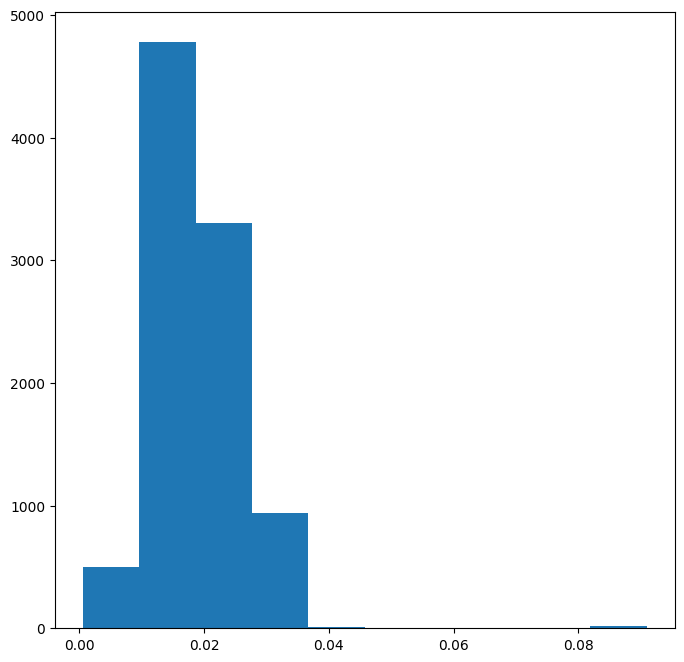

In [10]:
plt.hist(ms_res["mash_dist"])

In [11]:
meta = meta[~meta["acc"].isin(list(filter_acc["sample_name"]))]
meta_name = meta_name[meta_name["entero_acc"].isin(list(meta["acc"]))]
meta = pd.merge(meta, meta_name, left_on="acc", right_on="entero_acc", how="inner")
meta = meta.drop(["entero_acc"], axis=1)
meta

,acc,O,H,NCBI_acc,PRJNA
0,ESC_AA7966AA_AS,O113,H21,SRR1783858,PRJNA273275
1,ESC_AA8101AA_AS,O157,H7,SRR1658096,PRJNA232925
2,ESC_AA8232AA_AS,O157,H7,SRR1917598,PRJNA274145
3,ESC_AA8336AA_AS,O157,H7,SRR2016400,PRJNA282762
4,ESC_AA8426AA_AS,O104,H4,SRR349659,PRJNA73631
...,...,...,...,...,...
9534,ESC_ZB9919AA_AS,O23,H15,SRR16100691,PRJNA218110
9535,ESC_ZB9920AA_AS,O76,H19,SRR16100694,PRJNA218110
9536,ESC_ZB9921AA_AS,O84,H2,SRR16100699,PRJNA218110
9537,ESC_ZB9923AA_AS,O126,H27,SRR16100701,PRJNA218110


In [10]:
meta.to_csv("final_samples.csv")

In [7]:
OHtable = meta.set_index("acc").T.to_dict("list")
OHtable

{'ESC_AA7966AA_AS': ['O113', 'H21'],
 'ESC_AA8101AA_AS': ['O157', 'H7'],
 'ESC_AA8232AA_AS': ['O157', 'H7'],
 'ESC_AA8336AA_AS': ['O157', 'H7'],
 'ESC_AA8426AA_AS': ['O104', 'H4'],
 'ESC_AA8918AA_AS': ['O157', 'H7'],
 'ESC_AA9138AA_AS': ['O157', 'H7'],
 'ESC_AA9419AA_AS': ['O26', 'H11'],
 'ESC_AA9463AA_AS': ['O157', 'H7'],
 'ESC_AA9488AA_AS': ['O157', 'H7'],
 'ESC_AA9535AA_AS': ['O2', 'H6'],
 'ESC_AA9634AA_AS': ['O157', 'H7'],
 'ESC_AA9971AA_AS': ['O26', 'H11'],
 'ESC_AB7738AA_AS': ['O124', 'H30'],
 'ESC_AB7756AA_AS': ['O121', 'H30'],
 'ESC_AB7934AA_AS': ['O157', 'H7'],
 'ESC_AB7939AA_AS': ['O157', 'H7'],
 'ESC_AC0550AA_AS': ['O55', 'H10'],
 'ESC_AC0552AA_AS': ['O157', 'H7'],
 'ESC_AC0553AA_AS': ['O157', 'H7'],
 'ESC_AC0554AA_AS': ['O157', 'H7'],
 'ESC_AC0555AA_AS': ['O157', 'H7'],
 'ESC_AC0556AA_AS': ['O157', 'H7'],
 'ESC_AC0557AA_AS': ['O157', 'H7'],
 'ESC_AC0558AA_AS': ['O157', 'H7'],
 'ESC_AC0559AA_AS': ['O157', 'H7'],
 'ESC_AC0560AA_AS': ['O157', 'H7'],
 'ESC_AC0561AA_AS': ['O157'

###  5. Plot Data Distribution according to O types

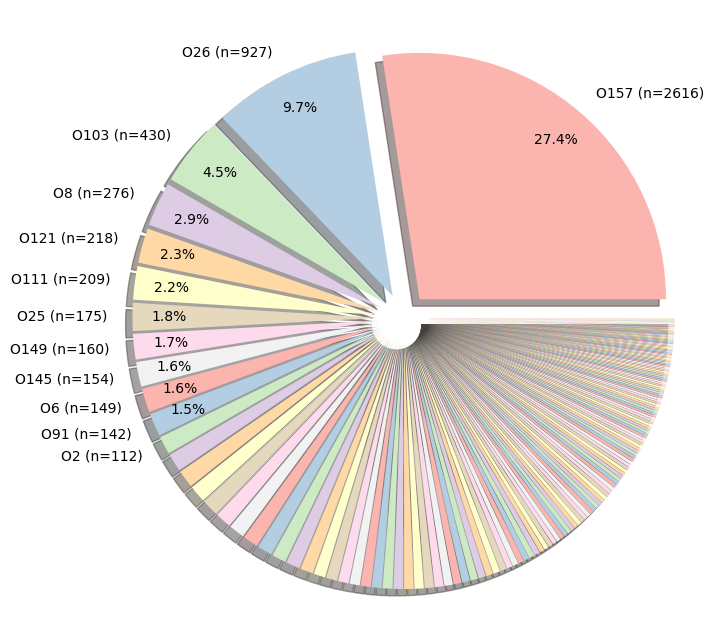

In [12]:
#to add percentages
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct >= 1.2 else ''

plt.pie(meta["O"].value_counts(),
        labels=["{} (n={})".format(name, meta["O"].value_counts()[name]) if idx <12 else "" for idx, name in enumerate(list(meta["O"].value_counts().keys()))],
        autopct=my_autopct,
        pctdistance=.85,
        explode=[0.1]*len(meta["O"].value_counts()),
        shadow=True,
        colors=plt.cm.Pastel1.colors
       )
plt.show() 

In [13]:
major_O_list = [k for k, v in dict(meta["O"].value_counts()).items() if v>=5]
len(major_O_list) ## Number of O classes having more than 5 data

159

In [14]:
sum([v for k, v in dict(meta["O"].value_counts()).items() if v>=10])

9225

### 6. Get Prediction Results from Conventional Tools: SerotypeFinder and ECTyper

#### SerotypeFinder

In [15]:
sfTable = pd.read_csv("Eco_over1kb/serotypeFinder/result.txt", sep="\t")
sfTable = sfTable[sfTable["file"].isin(list(meta["acc"]))]

In [16]:
sfTable

,file,O_type,O_tag,H_type,H_tag
0,ESC_QA9493AA_AS,O26,NaN,H11,NaN
1,ESC_AC5485AA_AS,O157,NaN,H7,NaN
2,ESC_ZB9018AA_AS,O25,NaN,H4,NaN
3,ESC_UA1309AA_AS,O163,NaN,H19,NaN
4,ESC_HA7517AA_AS,O157,NaN,H7,NaN
...,...,...,...,...,...
9557,ESC_PA5934AA_AS,O171,NaN,H2,NaN
9558,ESC_KA7850AA_AS,O157,NaN,H7,NaN
9559,ESC_TA2298AA_AS,O100/O154,ambiguous,H10,NaN
9560,ESC_WA9245AA_AS,O103,NaN,H2,NaN


In [17]:
"{}/{} ({:.2f}%) Entries were ambiguous O type in SerotypeFinder".format((sfTable["O_tag"] == "ambiguous").sum(),
                                                                         len(sfTable),
                                                                         (sfTable["O_tag"] == "ambiguous").sum()/len(sfTable))

'364/9539 (0.04%) Entries were ambiguous O type in SerotypeFinder'

In [18]:
"{}/{} ({:.2f}%) Entries could not determine O type in SerotypeFinder".format(len(sfTable) - sum(sfTable["O_type"].value_counts()),
                                                                       len(sfTable),
                                                                       100*(len(sfTable) - sum(sfTable["O_type"].value_counts()))/len(sfTable)
                                                                      )

'948/9539 (9.94%) Entries could not determine O type in SerotypeFinder'

In [19]:
compareTb = pd.merge(meta, sfTable, left_on="acc", right_on="file", how="inner")
compareTb

,acc,O,H,NCBI_acc,PRJNA,file,O_type,O_tag,H_type,H_tag
0,ESC_AA7966AA_AS,O113,H21,SRR1783858,PRJNA273275,ESC_AA7966AA_AS,O113,NaN,H21,NaN
1,ESC_AA8101AA_AS,O157,H7,SRR1658096,PRJNA232925,ESC_AA8101AA_AS,O157,NaN,H7,NaN
2,ESC_AA8232AA_AS,O157,H7,SRR1917598,PRJNA274145,ESC_AA8232AA_AS,O157,NaN,H7,NaN
3,ESC_AA8336AA_AS,O157,H7,SRR2016400,PRJNA282762,ESC_AA8336AA_AS,NaN,NaN,H7,NaN
4,ESC_AA8426AA_AS,O104,H4,SRR349659,PRJNA73631,ESC_AA8426AA_AS,O104,NaN,H4,NaN
...,...,...,...,...,...,...,...,...,...,...
9534,ESC_ZB9919AA_AS,O23,H15,SRR16100691,PRJNA218110,ESC_ZB9919AA_AS,O23,NaN,H15,NaN
9535,ESC_ZB9920AA_AS,O76,H19,SRR16100694,PRJNA218110,ESC_ZB9920AA_AS,O76,NaN,H19,NaN
9536,ESC_ZB9921AA_AS,O84,H2,SRR16100699,PRJNA218110,ESC_ZB9921AA_AS,O84,NaN,H2,NaN
9537,ESC_ZB9923AA_AS,O126,H27,SRR16100701,PRJNA218110,ESC_ZB9923AA_AS,O126,NaN,H27,NaN


In [20]:
compareTb[compareTb["O"] == "O157"]

,acc,O,H,NCBI_acc,PRJNA,file,O_type,O_tag,H_type,H_tag
1,ESC_AA8101AA_AS,O157,H7,SRR1658096,PRJNA232925,ESC_AA8101AA_AS,O157,NaN,H7,NaN
2,ESC_AA8232AA_AS,O157,H7,SRR1917598,PRJNA274145,ESC_AA8232AA_AS,O157,NaN,H7,NaN
3,ESC_AA8336AA_AS,O157,H7,SRR2016400,PRJNA282762,ESC_AA8336AA_AS,NaN,NaN,H7,NaN
5,ESC_AA8918AA_AS,O157,H7,SRR2126287,PRJNA268206,ESC_AA8918AA_AS,O157,NaN,H7,NaN
6,ESC_AA9138AA_AS,O157,H7,SRR2125994,PRJNA268206,ESC_AA9138AA_AS,O157,NaN,H7,NaN
...,...,...,...,...,...,...,...,...,...,...
9521,ESC_ZB8751AA_AS,O157,H7,SRR15992795,PRJNA218110,ESC_ZB8751AA_AS,O157,NaN,H7,NaN
9525,ESC_ZB8755AA_AS,O157,H7,SRR15992826,PRJNA218110,ESC_ZB8755AA_AS,O157,NaN,H7,NaN
9527,ESC_ZB9002AA_AS,O157,H7,SRR16039852,PRJNA218110,ESC_ZB9002AA_AS,O157,NaN,H7,NaN
9528,ESC_ZB9014AA_AS,O157,H7,SRR16060491,PRJNA218110,ESC_ZB9014AA_AS,O157,NaN,H7,NaN


In [21]:
sf_report = pd.DataFrame(classification_report(list(compareTb["O"]), list(compareTb["O_type"]), output_dict=True)).transpose()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [22]:
sf_report.loc["O157"]

precision       0.996000
recall          0.856651
f1-score        0.921085
support      2616.000000
Name: O157, dtype: float64

In [23]:
list(dict(meta["O"].value_counts()).values())[100:110]

[13, 13, 13, 13, 12, 12, 12, 12, 12, 11]

In [24]:
confusion_matrix(list(compareTb["O"]), list(compareTb["O_type"]), labels=["O157"])

array([[2241]])

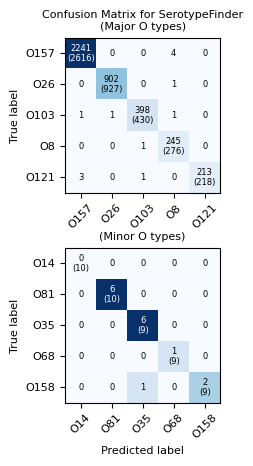

In [26]:
major_O_list = list(dict(meta["O"].value_counts()).keys())[0:5]
middle_O_list = list(dict(meta["O"].value_counts()).keys())[120:125]
major_cm = confusion_matrix(list(compareTb["O"]), list(compareTb["O_type"]), labels=major_O_list)
middle_cm = confusion_matrix(list(compareTb["O"]), list(compareTb["O_type"]), labels=middle_O_list)

major_O_count_sums = np.array(list(dict(meta["O"].value_counts()).values())[0:5])
middle_O_count_sums = np.array(list(dict(meta["O"].value_counts()).values())[120:125])
major_cm_rt = major_cm / major_O_count_sums[:, np.newaxis]
middle_cm_rt = middle_cm / middle_O_count_sums[:, np.newaxis]

# 혼동 행렬을 시각화하는 함수
def plot_confusion_matrix(ax, cm, labels, sum_value, title, ylabel, xlabel):
    #plt.figure(figsize=(6, 4))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=8)
    #plt.colorbar(cax, ax=ax)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels, fontsize=8)

    # 텍스트 표시
    fmt = ""#'.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, format(cm[i, j] if i!=j else str(cm[i, j])+"\n("+str(sum_value[i])+")", fmt),
                 ha="center", va="center", fontsize=6,
                 color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8)
    #plt.tight_layout()

# 레이블 예시
labels = ['Class 1', 'Class 2', 'Class 3']

# 혼동 행렬 플롯
fig, ax = plt.subplots(2, 1, figsize=(2, 5))
#plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for SerotypeFinder\nMajor O types")
plot_confusion_matrix(ax[0], major_cm, major_O_list, major_O_count_sums, "Confusion Matrix for SerotypeFinder\n(Major O types)", "True label", "")
#plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "Recall for SerotypeFinder\nMinor O types")
plot_confusion_matrix(ax[1], middle_cm, middle_O_list, middle_O_count_sums, "(Minor O types)", "True label", "Predicted label")
plt.show()

In [27]:
"By SerotypeFinder, {}/{} ({:.2f}%) O types were correctly classified".format((compareTb["O"] == compareTb["O_type"]).sum(),
                                                                              len(compareTb),
                                                                              100*(compareTb["O"] == compareTb["O_type"]).sum()/len(compareTb),                                                                               )

'By SerotypeFinder, 7843/9539 (82.22%) O types were correctly classified'

In [28]:
"By SerotypeFinder, {}/{} ({:.2f}%) H types were correctly classified".format((compareTb["H"] == compareTb["H_type"]).sum(),
                                                                              len(compareTb),
                                                                              100*(compareTb["H"] == compareTb["H_type"]).sum()/len(compareTb),                                                                               )

'By SerotypeFinder, 8940/9539 (93.72%) H types were correctly classified'

#### ECTyper

In [29]:
ectyper_stat = pd.read_csv("Eco_over1kb/ectyper_temp2/output.tsv", sep="\t")
ectyper_stat = ectyper_stat[~ectyper_stat["Warnings"].str.contains("Non fasta")]
ectyper_stat["Name"] = list(ectyper_stat.Name.str.split(".").str[0])
ectyper_merged = pd.merge(left=ectyper_stat, right=meta, how="left", left_on="Name", right_on="acc")
ectyper_merged
ectyper_merged

,Name,Species,O-type,H-type,Serotype,QC,Evidence,GeneScores,AlleleKeys,GeneIdentities(%),...,GeneContigNames,GeneRanges,GeneLengths,Database,Warnings,acc,O,H,NCBI_acc,PRJNA
0,ESC_AA7966AA_AS,-,O113,H21,O113:H21,-,Based on 3 allele(s),wzx:0.999;wzy:1;fliC:1;,O113-3-wzx;O113-2-wzy-origin;H21-12-fliC;,99.859;100;100;,...,NODE_1_length_286614_cov_28.1044_ID_1;NODE_1_l...,183744-185165;181619-182806;50854-52329;,1422;1188;1476;,v1.0 (11-03-2020),-,ESC_AA7966AA_AS,O113,H21,SRR1783858,PRJNA273275
1,ESC_AA8101AA_AS,-,O157,H7,O157:H7,-,Based on 3 allele(s),wzx:1;wzy:0.998;fliC:1;,O157-1-wzx-origin;O157-209-wzy;H7-1-fliC-origin;,100;99.797;100;,...,NODE_83_length_4314_cov_7.25078_ID_165;NODE_83...,1142-2533;3235-4218;45203-46960;,1392;984;1758;,v1.0 (11-03-2020),-,ESC_AA8101AA_AS,O157,H7,SRR1658096,PRJNA232925
2,ESC_AA8232AA_AS,-,O157,H7,O157:H7,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O157-1-wzx-origin;O157-118-wzy;H7-1-fliC-origin;,100;100;100;,...,NODE_14_length_144991_cov_11.0733_ID_27;NODE_1...,106281-107672;104413-105579;148220-149977;,1392;1167;1758;,v1.0 (11-03-2020),-,ESC_AA8232AA_AS,O157,H7,SRR1917598,PRJNA274145
3,ESC_AA8336AA_AS,-,-,H7,-:H7,-,Based on 1 allele(s),fliC:1;,H7-1-fliC-origin;,100;,...,NODE_99_length_14712_cov_14.5281_ID_197;,7784-9541;,1758;,v1.0 (11-03-2020),-,ESC_AA8336AA_AS,O157,H7,SRR2016400,PRJNA282762
4,ESC_AA8426AA_AS,-,O104,H4,O104:H4,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O104-16-wzx;O104-13-wzy;H4-2-fliC-origin;,100;100;100;,...,NODE_3_length_259258_cov_9.75973_ID_5;NODE_3_l...,235800-236990;233372-234484;32625-33674;,1191;1113;1050;,v1.0 (11-03-2020),-,ESC_AA8426AA_AS,O104,H4,SRR349659,PRJNA73631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9525,ESC_ZB9919AA_AS,-,O23,H15,O23:H15,-,Based on 3 allele(s),wzx:1;wzy:0.999;fliC:1;,O23-1-wzx-origin;O23-2-wzy-origin;H15-1-fliC-o...,100;99.903;100;,...,ESC_ZB9919AA_AS_NODE_2_length_482844_cov_13.04...,379762-380967;377898-378923;97566-99254;,1206;1026;1689;,v1.0 (11-03-2020),-,ESC_ZB9919AA_AS,O23,H15,SRR16100691,PRJNA218110
9526,ESC_ZB9920AA_AS,-,O76,H19,O76:H19,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O76-3-wzx;O76-5-wzy;H19-4-fliC;,100;100;99.945;,...,ESC_ZB9920AA_AS_NODE_1_length_351660_cov_10.43...,323788-325026;325592-326824;7008-8839;,1239;1233;1832;,v1.0 (11-03-2020),-,ESC_ZB9920AA_AS,O76,H19,SRR16100694,PRJNA218110
9527,ESC_ZB9921AA_AS,-,O84,H2,O84:H2,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O84-4-wzx;O84-6-wzy;H2-6-fliC;,100;100;100;,...,ESC_ZB9921AA_AS_NODE_32_length_49157_cov_12.79...,31063-32457;35125-36276;46800-48288;,1395;1152;1489;,v1.0 (11-03-2020),-,ESC_ZB9921AA_AS,O84,H2,SRR16100699,PRJNA218110
9528,ESC_ZB9923AA_AS,-,O126,H27,O126:H27,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O126-1-wzx-origin;O126-3-wzy-origin;H27-9-fliC;,100;100;100;,...,ESC_ZB9923AA_AS_NODE_2_length_423907_cov_11.26...,389512-390996;379400-380443;97830-99290;,1485;1044;1461;,v1.0 (11-03-2020),-,ESC_ZB9923AA_AS,O126,H27,SRR16100701,PRJNA218110


In [30]:
ectyper_merged[ectyper_merged["O-type"].str.contains("/")]

,Name,Species,O-type,H-type,Serotype,QC,Evidence,GeneScores,AlleleKeys,GeneIdentities(%),...,GeneContigNames,GeneRanges,GeneLengths,Database,Warnings,acc,O,H,NCBI_acc,PRJNA
13,ESC_AB7738AA_AS,-,O124/O164,H30,O124/O164:H30,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O124-1-wzx-origin;O124-3-wzy-origin;H30-1-fliC...,100;100;100;,...,NODE_4_length_86547_cov_10.676513;NODE_4_lengt...,53534-55048;58575-59363;48476-50188;,1515;789;1713;,v1.0 (11-03-2020),High similarity O-antigen group 13:O124/O164 a...,ESC_AB7738AA_AS,O124,H30,SRR9259317,PRJNA315192
150,ESC_AC2957AA_AS,-,O13/O129/O135,H4,O13/O129/O135:H4,-,Based on 2 allele(s),wzx:0.998;fliC:1;,O13-1-wzx-origin;H4-2-fliC-origin;,99.841;99.905;,...,ESC_AC2957AA_AS_NODE_2_length_352358_cov_48.93...,348350-349606;93383-94432;,1257;1050;,v1.0 (11-03-2020),High similarity O-antigen group 10:O13/O129/O1...,ESC_AC2957AA_AS,O13,H4,SRR16359871,PRJNA292663
203,ESC_AC3885AA_AS,-,O117/O107,H7,O117/O107:H7,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O117-1-wzx-origin;O117-2-wzy-origin;H7-38-fliC;,100;100;100;,...,ESC_AC3885AA_AS_NODE_25_length_64521_cov_7.921...,29644-30861;30854-32176;87634-89391;,1218;1323;1758;,v1.0 (11-03-2020),High similarity O-antigen group 8:O107/O117 as...,ESC_AC3885AA_AS,O117,H7,SRR16575020,PRJNA218110
250,ESC_AC4781AA_AS,-,O13/O135,H30,O13/O135:H30,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O13-1-wzx-origin;O13-2-wzy-origin;H30-1-fliC-o...,100;100;99.942;,...,ESC_AC4781AA_AS_NODE_1_length_737678_cov_16.94...,49460-50716;46473-47621;417000-418712;,1257;1149;1713;,v1.0 (11-03-2020),High similarity O-antigen group 10:O13/O129/O1...,ESC_AC4781AA_AS,O13,H30,SRR16777156,PRJNA630096
255,ESC_AC4789AA_AS,-,O13/O135,H4,O13/O135:H4,-,Based on 3 allele(s),wzx:0.998;wzy:0.999;fliC:1;,O13-1-wzx-origin;O13-2-wzy-origin;H4-2-fliC-or...,99.841;99.913;100;,...,ESC_AC4789AA_AS_NODE_4_length_627857_cov_13.65...,43541-44797;46636-47784;222773-223822;,1257;1149;1050;,v1.0 (11-03-2020),High similarity O-antigen group 10:O13/O129/O1...,ESC_AC4789AA_AS,O13,H4,SRR16777147,PRJNA630096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9177,ESC_XB5543AA_AS,-,O162/O101,H10,O162/O101:H10,-,Based on 3 allele(s),wzm:1;wzt:1;fliC:1;,O162-1-wzm-origin;O162-2-wzt-origin;H10-17-fliC;,100;100;100;,...,ESC_XB5543AA_AS_NODE_11_length_128654_cov_33.8...,124853-125632;125639-126391;12614-13876;,780;753;1263;,v1.0 (11-03-2020),High similarity O-antigen group 15:O89/O101/O1...,ESC_XB5543AA_AS,O162,H10,SRR14993813,PRJNA357722
9263,ESC_XB5675AA_AS,-,O77/O17/O44/O106/O73,H19,O77/O17/O44/O106/O73:H19,-,Based on 3 allele(s),wzx:0.997;wzy:0.996;fliC:0.99;,O77-1-wzx-origin/O17-1-wzx-origin;O77-3-wzy-in...,99.676;99.55;98.963;,...,ESC_XB5675AA_AS_NODE_34_length_49096_cov_31.75...,5725-6960;4352-5683;47642-49473;,1236;1332;1832;,v1.0 (11-03-2020),High similarity O-antigen group 9:O17/O44/O73/...,ESC_XB5675AA_AS,O73,H19,SRR14996021,PRJNA357722
9266,ESC_XB6768AA_AS,-,O117/O107,H51,O117/O107:H51,-,Based on 3 allele(s),wzx:0.999;wzy:1;fliC:1;,O117-1-wzx-origin;O117-3-wzy-origin;H51-2-fliC...,99.918;100;100;,...,ESC_XB6768AA_AS_NODE_2_length_353913_cov_43.06...,325292-326509;326502-327824;7199-9016;,1218;1323;1818;,v1.0 (11-03-2020),High similarity O-antigen group 8:O107/O117 as...,ESC_XB6768AA_AS,O117,H51,SRR14994592,PRJNA357722
9355,ESC_YB5113AA_AS,-,O117/O107,H4,O117/O107:H4,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O117-1-wzx-origin;O117-3-wzy-origin;H4-2-fliC-...,100;100;100;,...,ESC_YB5113AA_AS_NODE_4_length_267975_cov_44.47...,257544-258761;258754-260076;90436-91485;,1218;1323;1050;,v1.0 (11-03-2020),High similarity O-antigen group 8:O107/O117 as...,ESC_YB5113AA_AS,O117,H4,SRR15193951,PRJNA218110


In [31]:
"{}/{} ({:.2f}%) Entries were ambiguous O type in ECTyper".format((ectyper_merged["O-type"].str.contains("/")).sum(),
                                                                         len(ectyper_merged),
                                                                         100*(ectyper_merged["O-type"].str.contains("/")).sum()/len(ectyper_merged))

'237/9530 (2.49%) Entries were ambiguous O type in ECTyper'

In [32]:
"{}/{} ({:.2f}%) Entries could not determine O type in ECTyper".format((ectyper_merged["O-type"] == "-").sum(),
                                                                         len(ectyper_merged),
                                                                         100*(ectyper_merged["O-type"] == "-").sum()/len(ectyper_merged))

'1123/9530 (11.78%) Entries could not determine O type in ECTyper'

In [33]:
"By ECTyper, {}/{} ({:.2f}%) O types were correctly classified".format(len(ectyper_merged[ectyper_merged["O-type"] == ectyper_merged["O"]]),
                                                                              len(ectyper_merged),
                                                                              100*len(ectyper_merged[ectyper_merged["O-type"] == ectyper_merged["O"]])/len(ectyper_merged),)

'By ECTyper, 7601/9530 (79.76%) O types were correctly classified'

In [34]:
"By ECTyper, {}/{} ({:.2f}%) H types were correctly classified".format(len(ectyper_merged[ectyper_merged["H-type"] == ectyper_merged["H"]]),
                                                                              len(ectyper_merged),
                                                                              100*len(ectyper_merged[ectyper_merged["H-type"] == ectyper_merged["H"]])/len(ectyper_merged),)

'By ECTyper, 8586/9530 (90.09%) H types were correctly classified'

In [35]:
ec_report = pd.DataFrame(classification_report(list(ectyper_merged["O"]), list(ectyper_merged["O-type"]), output_dict=True)).transpose()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [36]:
ec_report

,precision,recall,f1-score,support
-,0.000000,0.000000,0.000000,0.000000
O1,0.957143,0.728261,0.827160,92.000000
O10,0.666667,0.857143,0.750000,7.000000
O100,0.714286,0.714286,0.714286,14.000000
O100/O154,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
O99,1.000000,0.961538,0.980392,26.000000
nan,0.000000,0.000000,0.000000,282.000000
accuracy,0.797587,0.797587,0.797587,0.797587
macro avg,0.600476,0.513229,0.536351,9530.000000


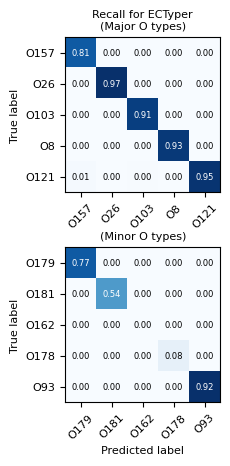

In [37]:
major_O_list = list(dict(meta["O"].value_counts()).keys())[0:5]
middle_O_list = list(dict(meta["O"].value_counts()).keys())[100:105]
major_cm = metrics.confusion_matrix(list(ectyper_merged["O"]), list(ectyper_merged["O-type"]), labels=major_O_list)
middle_cm = metrics.confusion_matrix(list(ectyper_merged["O"]), list(ectyper_merged["O-type"]), labels=middle_O_list)

major_O_count_sums = np.array(list(dict(meta["O"].value_counts()).values())[0:5])
middle_O_count_sums = np.array(list(dict(meta["O"].value_counts()).values())[100:105])
major_cm_rt = major_cm / major_O_count_sums[:, np.newaxis]
middle_cm_rt = middle_cm / middle_O_count_sums[:, np.newaxis]

# 혼동 행렬을 시각화하는 함수
def plot_confusion_matrix(ax, cm, labels, title, ylabel, xlabel):
    #plt.figure(figsize=(6, 4))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=8)
    #plt.colorbar(cax, ax=ax)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels, fontsize=8)

    # 텍스트 표시
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", fontsize=6,
                 color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8)
    #plt.tight_layout()

# 레이블 예시
labels = ['Class 1', 'Class 2', 'Class 3']

# 혼동 행렬 플롯
fig, ax = plt.subplots(2, 1, figsize=(2, 5))
#plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for ECTyper\nMajor O types")
plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for ECTyper\n(Major O types)", "True label", "")
#plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "Recall for ECTyper\nMinor O types")
plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "(Minor O types)", "True label", "Predicted label")
plt.show()

### 7. Parse GeneMark-S2 Results and MBGD Blast Results (DO NOT RUN AGAIN; takes long time to process)

#### Parse GeneMark-S2 Results

In [ ]:
fl = glob.glob("2-1.split/*/*.tab")

GMS_annot = {}
for af in fl:
    with open(af, "r") as infile:
        file_name = af.split("/")[-1].replace(".tab", "")
        GMS_annot.setdefault(file_name, {})
        for line in infile:
            seqnum, gene, pident, length = line.strip("\n").split("\t")[0:4]
            _sp, _gene = gene.split(":")
            GMS_annot[file_name][int(seqnum)] = {"species":_sp, "gene":_gene, "pident":pident, "length":length}

In [10]:
len(GMS_annot)

9561

#### Read MBGD Blast results, assign protein sequences into each clutser

In [11]:
count, nometa_count = 0, 0
try:
    #os.mkdir("MBGD_clusters_faa")
    os.mkdir("MBGD_clusters_faa_revision")
except:
    pass

with open("3-1.CD-HIT/GMS2.faa", "r") as infile:
    for idx, line in enumerate(infile):
        if idx % 100000 == 0:
            print(idx)
            
        if line.startswith(">"):
            skipLine = False
            acc = line.strip("\n").strip(">")
            sample_name = acc.split("|")[0].split(".")[0].strip("_genomic")
            
            if sample_name not in OHtable:
                nometa_count += 1
                skipLine = True
                #print(acc, sample_name) 
                continue
            
            O, H = OHtable[sample_name][:2]            
            
            """
            search_res = meta[meta.acc == sample_name]
        
            if len(search_res) != 1:
                print(acc, sample_name)
                continue
            
            O, H = list(search_res["O"])[0], list(search_res["H"])[0]
            """
            
            file_name, seqnum = acc.split("|")
            if int(seqnum) not in GMS_annot[file_name]:
                count += 1
                skipLine = True
                continue
                
            blast_info = GMS_annot[file_name][int(seqnum)]
            
            if blast_info["species"] not in Gene2Cluster:
                count += 1
                skipLine = True
                continue
                
            if blast_info["gene"] not in Gene2Cluster[blast_info["species"]]:
                count += 1
                skipLine = True
                continue
                                
            ClusterList = [int(key) for key in Gene2Cluster[blast_info["species"]][blast_info["gene"]]]
        
        else:
            if skipLine: continue
                
            for clstr in ClusterList:
                #if not os.path.exists("MBGD_clusters_faa/{}".format(clstr%1000)):
                if not os.path.exists("MBGD_clusters_faa_revision/{}".format(clstr%1000)):
                    try:
                        #os.mkdir("MBGD_clusters_faa/{}".format(clstr%1000))
                        os.mkdir("MBGD_clusters_faa_revision/{}".format(clstr%1000))
                    except:
                        pass
                    
                #outfile = open("MBGD_clusters_faa/{}/{}.faa".format(clstr%1000, clstr), "a")
                outfile = open("MBGD_clusters_faa_revision/{}/{}.faa".format(clstr%1000, clstr), "a")
            
                print(">{}:{}:{}:{}:{}".format(acc, O, H, blast_info["pident"], blast_info["length"]), file=outfile)
                print(line, end="", file=outfile)
                
                outfile.close()
        
print(count)
print(nometa_count)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
6000000
6100000
6200000
6300000
6400000
6500000
6600000
6700000
6800000
6900000
7000000
7100000
7200000
7300000
7400000
7500000
7600000
7700000
7800000
7900000
8000000
8100000
8200000
8300000
8400000
8500000
8600000
8700000
8800000
8900000
9000000
9100000
9200000
9300000
9400000
9500000
9600000
9700000
9800000
9900000
10000000
10100000
10200000
10300000
10400000
10500000
10600000
10700000
10800000
10900000
11000000
11100000
11200000
11300000
11400000
11500000
11600000
11700000
11800000
11900000
12000000
12100000
12200000
12300000

92400000
92500000
92600000
92700000
92800000
92900000
93000000
93100000
93200000
93300000
93400000
93500000
93600000
93700000
93800000
93900000
94000000
94100000
94200000
94300000
94400000
94500000
94600000
94700000
94800000
94900000
95000000
95100000
95200000
95300000
95400000
95500000
95600000
95700000
95800000
95900000
96000000
96100000
96200000
96300000
96400000
96500000
96600000
96700000
96800000
96900000
97000000
97100000
97200000
97300000
97400000
97500000
97600000
97700000
97800000
97900000
98000000
98100000
98200000
98300000
98400000
98500000
98600000
334488
0


#### CD-HIT to refine cluster definition
#### Parse CD-HIT result

In [26]:
#fl = glob.glob("3-1.CD-HIT/clusters_c90/*.c90n5.clstr")
fl = glob.glob("3-1.CD-HIT/clusters_c50/*.c50n2.clstr")
#fl = glob.glob("3-1.CD-HIT/clusters_c50/117.c50n2.clstr")
print(len(fl))

CDHIT_clstr_dict = {}
for af in fl: 
    MBGD_clusterNo = int(af.split("/")[-1].split(".")[0])
    with open(af, "r") as infile:
        for line in infile:
            if line.startswith(">"):
                CDHIT_clusterNo = int(line.split(" ")[-1].strip("\n"))
            else:
                _seqid = line.split(" ")[1].split(":")[0].strip(">")
                CDHIT_clstr_dict.setdefault(_seqid, [])
                CDHIT_clstr_dict[_seqid].append((MBGD_clusterNo, CDHIT_clusterNo))

15052


In [27]:
print(len(CDHIT_clstr_dict))

49010446


In [28]:
CDHIT_clstr_dict["ESC_GC3128AA_AS.result|3531"]

[(159993, 2), (64478, 2)]

#### Read CD-HIT results, assign gene vectors into each clutser

In [135]:
count, nometa_count = 0, 0
try:
    os.mkdir("MBGD_clusters_cdhit")
except:
    pass

with open("5-1.ESM/GMS2.faa.txt", "r") as infile:
    for idx, line in enumerate(infile):
        if idx % 100000 == 0:
            print(idx)
            
        if line.startswith(">"):
            skipLine = False
            acc = line.strip("\n").strip(">")
            sample_name = acc.split("|")[0].split(".")[0].strip("_genomic")
      
            if acc not in CDHIT_clstr_dict:
                count += 1
                skipLine = True
                continue
                
            #search_res = meta[meta.acc == sample_name]                
            #if len(search_res) != 1: # Excluded by sample filtering
            if sample_name not in OHtable:
                nometa_count += 1
                skipLine = True
                #print(acc, sample_name) 
                continue
            
            #O, H = list(search_res["O"])[0], list(search_res["H"])[0]
            O, H = OHtable[sample_name][:2]
            
            cdhit_info_list = CDHIT_clstr_dict[acc]
            
            """            
            file_name, seqnum = acc.split("|")
            if int(seqnum) not in GMS_annot[file_name]:
                count += 1
                skipLine = True
                continue
                
            #blast_info = GMS_annot[file_name][int(seqnum)]
            
            
            if blast_info["species"] not in Gene2Cluster:
                count += 1
                skipLine = True
                continue
                
            if blast_info["gene"] not in Gene2Cluster[blast_info["species"]]:
                count += 1
                skipLine = True
                continue
                                
            ClusterList = [int(key) for key in Gene2Cluster[blast_info["species"]][blast_info["gene"]]]
            """
        
        else:
            if skipLine: continue
                
            for cdhit_info in cdhit_info_list:
                if not os.path.exists("MBGD_clusters_cdhit/{}".format(cdhit_info[0]%1000)):
                    try:
                        os.mkdir("MBGD_clusters_cdhit/{}".format(cdhit_info[0]%1000))
                    except:
                        pass

                outfile = open("MBGD_clusters_cdhit/{}/{}_{}.vecs".format(cdhit_info[0]%1000, cdhit_info[0], cdhit_info[1]), "a")

                #print(">{}:{}:{}:{}:{}".format(acc, O, H, blast_info["pident"], blast_info["length"]), file=outfile)
                print(">{}:{}:{}".format(acc, O, H), file=outfile)
                print(line, end="", file=outfile)

                outfile.close()
        
print(count)
print(nometa_count)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
6000000
6100000
6200000
6300000
6400000
6500000
6600000
6700000
6800000
6900000
7000000
7100000
7200000
7300000
7400000
7500000
7600000
7700000
7800000
7900000
8000000
8100000
8200000
8300000
8400000
8500000
8600000
8700000
8800000
8900000
9000000
9100000
9200000
9300000
9400000
9500000
9600000
9700000
9800000
9900000
10000000
10100000
10200000
10300000
10400000
10500000
10600000
10700000
10800000
10900000
11000000
11100000
11200000
11300000
11400000
11500000
11600000
11700000
11800000
11900000
12000000
12100000
12200000
12300000

92400000
92500000
92600000
92700000
92800000
92900000
93000000
93100000
93200000
93300000
93400000
93500000
93600000
93700000
93800000
93900000
94000000
94100000
94200000
94300000
94400000
94500000
94600000
94700000
94800000
94900000
95000000
95100000
95200000
95300000
95400000
95500000
95600000
95700000
95800000
95900000
96000000
96100000
96200000
96300000
96400000
96500000
96600000
96700000
96800000
96900000
97000000
97100000
97200000
97300000
97400000
97500000
97600000
97700000
97800000
97900000
98000000
98100000
98200000
98300000
98400000
98500000
98600000
332890
103248


### 8. Run Random Forest model for each gene cluster

interpreter version

In [268]:
for clstr in ClusterMeta:
#for clstr in ["100"]:
    DataMat = {"v{}".format(i):[] for i in range(320)}
    DataMat["answer"] = []
    DataMat["acc"] = []
    temp_vecs = {}
    
    clstr = int(clstr)
    if not os.path.isfile("MBGD_clusters/{}/{}.vecs".format(clstr%1000, clstr)): continue
    
    with open("MBGD_clusters/{}/{}.log4".format(clstr%1000, clstr), "w") as outfile:
        with open("MBGD_clusters/{}/{}.vecs".format(clstr%1000, clstr), "r") as infile:
            for line in infile:
                if line.startswith(">"): # odd lines
                    acc, O, H, pident, length = line.strip("\n").strip(">").split(":")
                    continue
                    
                # even lines; deal with only valid samples
                sample_acc = acc.split("|")[0].split(".")[0].replace("_genomic", "")
                if sample_acc in list(meta["acc"]):
                    vecs = line.strip("\n").split(" ")                    
                    temp_vecs.setdefault(sample_acc, [])
                    temp_vecs[sample_acc].append([float(vec) for vec in vecs])
                    continue
            
            for sample_acc in temp_vecs:
                mean_vec = np.mean(temp_vecs[sample_acc], axis = 0)
                DataMat["acc"].append(sample_acc)
                DataMat["answer"].append(list(meta[meta["acc"] == sample_acc][O])[0])
                for i in range(len(mean_vec)):
                    DataMat["v{}".format(i)].append(mean_vec[i])
                    
            DataMat = pd.DataFrame(DataMat)

            O_stat = dict(DataMat["answer"].value_counts())
            len(O_stat), sum(O_stat.values())
            
            if sum(O_stat.values()) < 10 or len(O_stat) < 3: continue

            O_most_frequent = max(O_stat.values())/sum(O_stat.values())
            entpy = entropy(list(O_stat.values())/sum(O_stat.values()), base=2)
            normed_entpy = entpy/math.log2(len(O_stat))

            Y = DataMat["answer"].astype("category")
            X = DataMat.drop(["answer", "acc"], axis=1)
            x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

            RF_estimator = RandomForestClassifier(n_estimators=100, random_state=33, n_jobs=6, criterion="entropy", max_depth=50)
            scores = cross_val_score(RF_estimator, X, Y, cv=StratifiedKFold(n_splits = 10))

            print("File : {}, Accuracy Mean : {}, Accuracy Std : {}, Entropy(Normalized) : {}, Num of O classes : {}, Num of Data : {} (Excluded {}), Frequency of Most Prevalent O type : {}".format(clstr, scores.mean(), scores.std(), normed_entpy, len(O_stat), sum(O_stat.values()), len(meta)-sum(O_stat.values()), O_most_frequent),
                 file=outfile)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


File : 100, Accuracy Mean : 0.6712377992041022, Accuracy Std : 0.0364819566804358, Entropy(Normalized) : 0.7051886310353674, Num of O classes : 188, Num of Data : 9539 (Excluded 0), Frequency of Most Prevalent O type : 0.27424258307998745


compiler version (for multiprocessing)

In [13]:
cmd_list = ["python3 sub.py {}".format(clstr) for clstr in ClusterMeta]
def worker(cmd): 
    p = Popen(cmd, shell=True)
    p.wait()

pool = Pool( processes = 20 )
results =[pool.apply_async(worker, [cmd]) for cmd in cmd_list]
ans = [res.get() for res in results]

Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <modul

Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <modul

Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <modul

Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <modul

Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <module>
    clstr_cdhit = int(sys.argv[2])
IndexError: list index out of range
Traceback (most recent call last):
  File "/home/disk6/230504_enterobase_data/sub.py", line 17, in <modul

...

  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
  File "/usr/lib/python3.10/subprocess.py", line 1941, in _wait
    (pid, sts) = self._try_wait(0)
  File "/usr/lib/python3.10/subprocess.py", line 1941, in _wait
    (pid, sts) = self._try_wait(0)
  File "/usr/lib/python3.10/subprocess.py", line 1941, in _wait
    (pid, sts) = self._try_wait(0)
  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
KeyboardInterrupt
  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
Process ForkPoolWorker-

KeyboardInterrupt: 

Process ForkPoolWorker-35:
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/tmp/ipykernel_344/3608099236.py", line 4, in worker
    p.wait()
  File "/usr/lib/python3.10/subprocess.py", line 1207, in wait
    return self._wait(timeout=timeout)
  File "/usr/lib/python3.10/subprocess.py", line 1941, in _wait
    (pid, sts) = self._try_wait(0)
  File "/usr/lib/python3.10/subprocess.py", line 1899, in _try_wait
    (pid, sts) = os.waitpid(self.pid, wait_flags)
KeyboardInterrupt
Process ForkPoolWorker-26:
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiproce

Process ForkPoolWorker-25:
Process ForkPoolWorker-40:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    

  File "/usr/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/process.py", l

### 9. Screen Genes related to O serotype determination

In [38]:
!cat MBGD_clusters_cdhit_c90/*/*.log5 > MBGD_genes.log5

cat: 'MBGD_clusters_cdhit_c90/*/*.log5': No such file or directory


In [21]:
criterion_count = 0
acc_values = []
genome_values = []
Otype_values = []

target_clstr = set()
print("\t".join(["numO", "numData", "accuracy_mean", "accuracy_std", "major O", "entpy", "MBGD_clstrID", "CDHIT_clstrID", "gene_name", "gene_description"]))

for af in glob.glob("MBGD_clusters_cdhit/*/*.log6"):
    #with open("MBGD_genes.log5", "r") as infile:
    with open(af, "r") as infile:
        for line in infile:
            clstr, accuracy_mean, accuracy_std, norm_entpy, numO, numData, numMajor = [val.split(" : ")[-1] for val in line.strip("\n").split(",")]
            clstrMBGD, clstrCDHIT, numO = int(clstr.split("_")[0]), clstr.split("_")[1], int(numO)
            numData, numData_excluded = [int(a) for a in numData.rstrip(")").split(" (Excluded ")]
            genome_values.append(numData)
            Otype_values.append(numO)
            accuracy_mean, accuracy_std, norm_entpy, numMajor = float(accuracy_mean), float(accuracy_std), float(norm_entpy), float(numMajor)
            
            if numO >=10 and int(numData) > 1000:
                acc_values.append(accuracy_mean)

            if numO >=10 and numData >= 5000 and numMajor < 0.4 and accuracy_mean >= 0.7:
                if numO >=10 and numData >= 8000 and numMajor < 0.4 and accuracy_mean >= 0.7:
                    print("*{}\t{}\t{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}\t{}\t{}\t{}\t{}".format(numO, numData, accuracy_mean, accuracy_std, numMajor, norm_entpy, clstrMBGD, clstrCDHIT, ClusterMeta[str(clstrMBGD)]["gene"], ClusterMeta[str(clstrMBGD)]["descr"]), sep="\t")

                    target_clstr.add((clstrMBGD, clstrCDHIT))
                    criterion_count += 1
                else:
                    print("{}\t{}\t{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}\t{}\t{}\t{}\t{}".format(numO, numData, accuracy_mean, accuracy_std, numMajor, norm_entpy, clstrMBGD, clstrCDHIT, ClusterMeta[str(clstrMBGD)]["gene"], ClusterMeta[str(clstrMBGD)]["descr"]), sep="\t")

    #print(criterion_count)

numO	numData	accuracy_mean	accuracy_std	major O	entpy	MBGD_clstrID	CDHIT_clstrID	gene_name	gene_description
*183	9274	0.76	0.05	0.28	0.70	7478	4	wzzE	LPS O-antigen chain length protein
*186	9101	0.72	0.02	0.29	0.70	1911	0	wzxC	Polysaccharide biosynthesis protein
*186	9102	0.77	0.07	0.29	0.70	19	11	wcaL	Glycosyl transferase family 1
*186	9102	0.77	0.08	0.29	0.70	2726	0	wcaK	Colanic acid biosynthesis pyruvyl transferase
*188	9534	0.76	0.02	0.27	0.71	684	0	hisD	Histidinol dehydrogenase
*188	9521	0.71	0.05	0.27	0.70	201	1	wecC	UDP-glucose 6-dehydrogenase
*187	9175	0.76	0.11	0.28	0.70	35854	1	wcaM	Colanic acid biosynthesis protein WcaM
177	6199	0.73	0.07	0.39	0.56	449771	12	stfR	Phage tail fiber protein


In [40]:
# Duplicated WcaL records
target_clstr.remove((1838, "0"))
target_clstr.remove((2656, "0"))

In [185]:
acc_values = np.array(acc_values, dtype='float')

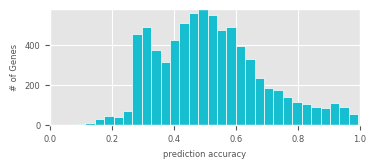

In [225]:
rcParams['figure.figsize'] = 4,1.5
plt.style.use('ggplot')
plt.hist(acc_values, bins=30, color='tab:cyan', edgecolor="white")
plt.xticks(fontsize=6)#, rotation=90)
plt.yticks(fontsize=6)
#plt.yscale('log')
plt.xlim(0,1)
plt.ylabel('# of Genes', fontsize=6)
plt.xlabel('prediction accuracy', fontsize=6)
#plt.show()
plt.margins(0)
plt.savefig("fig2c.png")

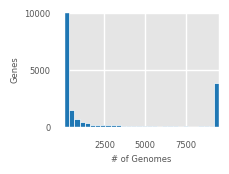

In [1679]:
genome_values = np.array(genome_values, dtype='float')
rcParams['figure.figsize'] = 2,1.5
plt.style.use('ggplot')
plt.hist(genome_values, bins=30, color='tab:blue', edgecolor="white")
plt.xticks(fontsize=6)#, rotation=90)
plt.yticks(fontsize=6)
#plt.yscale('log')
#plt.xlim(0,1)
plt.ylabel('Genes', fontsize=6)
plt.xlabel('# of Genomes', fontsize=6)
#plt.show()
plt.margins(0)
plt.savefig("fig2c.png")

In [1689]:
len(genome_values[genome_values>8000])
#len(genome_values)

4284

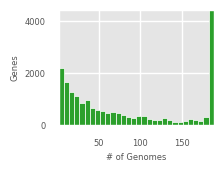

In [1681]:
Otype_values = np.array(Otype_values, dtype='float')
rcParams['figure.figsize'] = 2,1.5
plt.style.use('ggplot')
plt.hist(Otype_values, bins=30, color='tab:green', edgecolor="white")
plt.xticks(fontsize=6)#, rotation=90)
plt.yticks(fontsize=6)
#plt.yscale('log')
#plt.xlim(0,1)
plt.ylabel('Genes', fontsize=6)
plt.xlabel('# of Genomes', fontsize=6)
#plt.show()
plt.margins(0)
plt.savefig("fig2c.png")

In [1692]:
len(Otype_values[Otype_values<150])

14403

### 10. Compare Classfication Performance for each genes

In [112]:
gene_clsf_list = []
dimVec = 320
temp_vecs = {}

for clstrMBGD, clstrCDHIT in target_clstr:
    DataMat = {"acc":[], "answer":[]}
    for i in range(dimVec):
        DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)] = []        
        
    with open("MBGD_clusters_cdhit/{}/{}_{}.vecs".format(int(clstrMBGD)%1000, clstrMBGD, clstrCDHIT), "r") as infile:
        for line in infile:
            if line.startswith(">"): # odd lines
                acc, O, H = line.strip("\n").strip(">").split(":")[:3]
                continue
            else:
                sample_acc = acc.split("|")[0].split(".")[0].replace("_genomic", "")
                if sample_acc in OHtable:
                    vecs = line.strip("\n").split(" ")
                    temp_vecs.setdefault(sample_acc, [])
                    temp_vecs[sample_acc].append([float(vec) for vec in vecs])
                    
        duplicate_count = 0
        for sample_acc in temp_vecs:
            mean_vec = np.mean(temp_vecs[sample_acc], axis = 0)
            DataMat["acc"].append(sample_acc)
            DataMat["answer"].append(OHtable[sample_acc][0])
            for i in range(len(mean_vec)):
                DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)].append(mean_vec[i])
            if len(temp_vecs[sample_acc]) > 1: duplicate_count += 1
        #print(duplicate_count)
        
    gene_clsf_list.append({"DataMat":pd.DataFrame(DataMat),
                           "clstrID":{"MBGD":clstrMBGD, "CDHIT":clstrCDHIT},
                          })

In [113]:
gene_clsf_list[0]["DataMat"]["answer"].value_counts()[:20]

O157    2600
O26      926
O103     429
O8       234
O121     217
O25      174
O149     159
O145     154
O6       148
O91      142
O45      112
O2       111
O55      106
O75      103
O22      103
O165      98
O1        95
O104      91
O113      88
O16       87
Name: answer, dtype: int64

In [114]:
for gene_clsf in gene_clsf_list:
    nFold = 5.0
    target_O_list = [label for label, count in dict(gene_clsf["DataMat"]["answer"].value_counts()).items() if count >= nFold]
    DataMat_test = gene_clsf["DataMat"]
    DataMat_test = DataMat_test[DataMat_test["answer"].isin(target_O_list)]
    
    Y = DataMat_test["answer"].astype("category")
    X = DataMat_test.drop(["answer", "acc"], axis=1)
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=1/nFold, stratify=Y)

    RF_estimator = RandomForestClassifier(n_estimators=100, random_state=int(time.time()), n_jobs=40, criterion="entropy", max_depth=10,
                                         class_weight="balanced")
    RF_estimator.fit(X, Y)
    
    major_labels = list(Y.value_counts()[:10].keys())
    minor_labels = list(Y.value_counts()[-100:-90].keys())
    y_pred = RF_estimator.predict(x_test)    
    
    gene_clsf["clf"] = RF_estimator
    gene_clsf["major_labels"] = major_labels
    gene_clsf["minor_labels"] = minor_labels
    gene_clsf["conf_matrix_major"] = metrics.confusion_matrix(y_test, y_pred, labels=major_labels)
    gene_clsf["conf_matrix_minor"] = metrics.confusion_matrix(y_test, y_pred, labels=minor_labels)
    #gene_clsf["clf_report"] = classification_report(y_test, y_pred)
    gene_clsf["clf_report"] = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
    #ene_clsf["clf_report_major"] = classification_report(y_test, y_pred, labels=major_labels)
    #ene_clsf["clf_report_minor"] = classification_report(y_test, y_pred, labels=minor_labels)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

In [115]:
major_O_list = list(dict(meta["O"].value_counts()).keys())[0:5]
#major_O_list.remove("O111")
middle_O_list = list(dict(meta["O"].value_counts()).keys())[100:105]

nFold = 5
skf = StratifiedKFold(n_splits=nFold)
#x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=1/nFold, stratify=Y)

for gene_clsf in gene_clsf_list:    
    target_O_list = [label for label, count in dict(gene_clsf["DataMat"]["answer"].value_counts()).items() if count >= nFold]
    DataMat_test = gene_clsf["DataMat"]
    DataMat_test = DataMat_test[DataMat_test["answer"].isin(target_O_list)]
    
    Y = DataMat_test["answer"].astype("category")
    X = DataMat_test.drop(["answer", "acc"], axis=1)
    
    #all_conf_matrix_major = np.zeros((len(Y.cat.categories), len(Y.cat.categories)))
    #all_conf_matrix_minor = np.zeros((len(Y.cat.categories), len(Y.cat.categories)))
    all_conf_matrix_major = np.zeros((len(major_O_list), len(major_O_list)))
    all_conf_matrix_minor = np.zeros((len(middle_O_list), len(middle_O_list)))
    clf_reports = []    
    
    for train_index, test_index in skf.split(X, Y):
        x_train, x_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
        RF_estimator = RandomForestClassifier(n_estimators=100, random_state=int(time.time()), n_jobs=40, criterion="entropy", max_depth=10,
                                              class_weight="balanced")
        RF_estimator.fit(x_train, y_train)
        y_pred = RF_estimator.predict(x_test)
        
        #major_labels = list(Y.value_counts()[:10].keys())
        #minor_labels = list(Y.value_counts()[-100:-90].keys())
        
        all_conf_matrix_major += confusion_matrix(y_test, y_pred, labels=major_O_list)
        all_conf_matrix_minor += confusion_matrix(y_test, y_pred, labels=middle_O_list)
        clf_reports.append(classification_report(y_test, y_pred, output_dict=True))
    
    gene_clsf["clf"] = RF_estimator
    gene_clsf["conf_matrix_major"] = all_conf_matrix_major / nFold
    gene_clsf["conf_matrix_minor"] = all_conf_matrix_minor / nFold
    gene_clsf["clf_report_mean"] = clf_report_mean
    gene_clsf["clf_report_std"] = clf_report_std

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

NameError: name 'clf_report_mean' is not defined

In [116]:
all_conf_matrix_major

array([[2.525e+03, 0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00],
       [1.000e+00, 9.160e+02, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 3.740e+02, 1.000e+00, 0.000e+00],
       [9.000e+00, 0.000e+00, 4.000e+00, 4.600e+01, 1.000e+01],
       [3.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 2.100e+02]])

In [121]:
#OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O6"]
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O25", "O149", "O145", "O6"]

In [122]:
print(ClusterMeta[str(gene_clsf_list[0]["clstrID"]["MBGD"])]["gene"])
# show major results
display(gene_clsf_list[0]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[[i for i in OtypeList if i != "O111"]])
#display(gene_clsf_list[0]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[["O157"]])
display(gene_clsf_list[0]["clf_report"].loc[["accuracy", "macro avg", "weighted avg"]])

wzxC


,precision,recall,f1-score,support
O157,0.992218,0.980769,0.986460,520.0
O26,0.989247,0.994595,0.991914,185.0
O103,0.765306,0.872093,0.815217,86.0
O8,0.900000,0.191489,0.315789,47.0
O121,0.605634,0.977273,0.747826,44.0
O25,0.928571,0.742857,0.825397,35.0
O149,0.933333,0.875000,0.903226,32.0
O145,1.000000,1.000000,1.000000,31.0
O6,0.717949,0.933333,0.811594,30.0


,precision,recall,f1-score,support
accuracy,0.811947,0.811947,0.811947,0.811947
macro avg,0.645439,0.624619,0.581526,1808.000000
weighted avg,0.861262,0.811947,0.798579,1808.000000


ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (10).

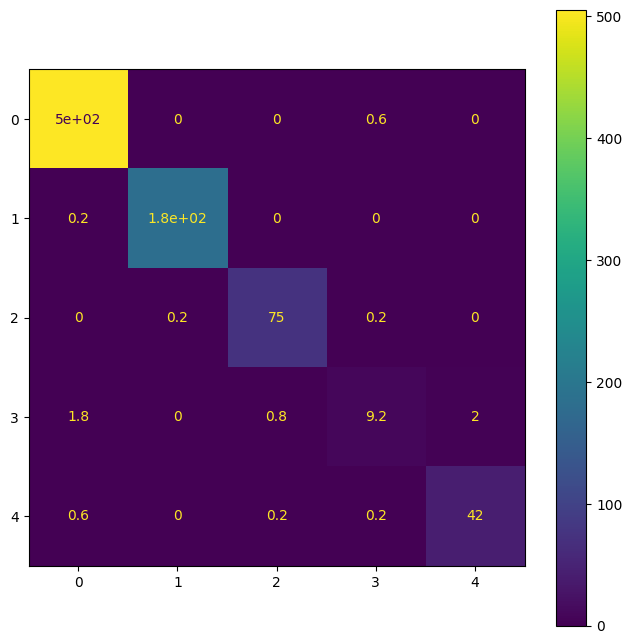

In [123]:
ConfusionMatrixDisplay(gene_clsf_list[0]["conf_matrix_major"], display_labels=gene_clsf_list[0]["major_labels"]).plot()

In [ ]:
ConfusionMatrixDisplay(gene_clsf_list[0]["conf_matrix_minor"], display_labels=gene_clsf_list[0]["minor_labels"]).plot()

In [124]:
print(ClusterMeta[str(gene_clsf_list[1]["clstrID"]["MBGD"])]["gene"])
# show major results
display(gene_clsf_list[1]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[OtypeList])
#display(gene_clsf_list[0]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[["O157"]])
display(gene_clsf_list[1]["clf_report"].loc[["accuracy", "macro avg", "weighted avg"]])

wcaK


,precision,recall,f1-score,support
O157,0.996124,0.988462,0.992278,520.0
O26,0.989305,1.000000,0.994624,185.0
O103,0.987805,0.941860,0.964286,86.0
O8,0.937500,0.638298,0.759494,47.0
O121,1.000000,0.954545,0.976744,44.0
O25,0.965517,0.800000,0.875000,35.0
O149,0.937500,0.937500,0.937500,32.0
O145,0.968750,1.000000,0.984127,31.0
O6,0.925926,0.833333,0.877193,30.0


,precision,recall,f1-score,support
accuracy,0.914823,0.914823,0.914823,0.914823
macro avg,0.797115,0.833086,0.787819,1808.000000
weighted avg,0.937055,0.914823,0.917502,1808.000000


In [125]:
print(ClusterMeta[str(gene_clsf_list[2]["clstrID"]["MBGD"])]["gene"])
# show major results
display(gene_clsf_list[2]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[OtypeList])
#display(gene_clsf_list[0]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[["O157"]])
display(gene_clsf_list[2]["clf_report"].loc[["accuracy", "macro avg", "weighted avg"]])

wecC


,precision,recall,f1-score,support
O157,0.994106,0.967495,0.980620,523.0
O26,1.000000,0.983871,0.991870,186.0
O103,0.988372,0.988372,0.988372,86.0
O8,0.960000,0.872727,0.914286,55.0
O121,0.977273,0.977273,0.977273,44.0
O25,0.909091,0.857143,0.882353,35.0
O149,0.941176,1.000000,0.969697,32.0
O145,1.000000,1.000000,1.000000,31.0
O6,1.000000,1.000000,1.000000,30.0


,precision,recall,f1-score,support
accuracy,0.945032,0.945032,0.945032,0.945032
macro avg,0.906406,0.929732,0.903517,1892.000000
weighted avg,0.961415,0.945032,0.948429,1892.000000


In [126]:
print(ClusterMeta[str(gene_clsf_list[3]["clstrID"]["MBGD"])]["gene"])
# show major results
display(gene_clsf_list[3]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[OtypeList])
#display(gene_clsf_list[0]["clf_report"].drop(["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).loc[["O157"]])
display(gene_clsf_list[3]["clf_report"].loc[["accuracy", "macro avg", "weighted avg"]])

wzzE


,precision,recall,f1-score,support
O157,0.996094,0.975143,0.985507,523.0
O26,1.000000,0.994624,0.997305,186.0
O103,0.976190,0.953488,0.964706,86.0
O8,0.905660,0.872727,0.888889,55.0
O121,1.000000,0.976744,0.988235,43.0
O25,0.970588,0.942857,0.956522,35.0
O149,1.000000,0.937500,0.967742,32.0
O145,0.968750,1.000000,0.984127,31.0
O6,0.967742,1.000000,0.983607,30.0


,precision,recall,f1-score,support
accuracy,0.951903,0.951903,0.951903,0.951903
macro avg,0.888202,0.918545,0.890878,1892.000000
weighted avg,0.961549,0.951903,0.952131,1892.000000


In [138]:
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O25", "O149", "O145", "O6"] # O111
prc_table = gene_clsf_list[0]["clf_report"].loc[OtypeList][["precision"]].rename(
    columns={"precision":ClusterMeta[str(gene_clsf_list[0]["clstrID"]["MBGD"])]["gene"]})
#prc_table = gene_clsf_list[0]["clf_report"].loc[OtypeList][["f1-score"]].rename(
#    columns={"precision":ClusterMeta[str(gene_clsf_list[0]["clstrID"]["MBGD"])]["gene"]})

for i in range(1, len(gene_clsf_list)):
    prc_table = pd.merge(prc_table,
                         gene_clsf_list[i]["clf_report"].loc[OtypeList][["precision"]].rename(
                           columns={"precision":ClusterMeta[str(gene_clsf_list[i]["clstrID"]["MBGD"])]["gene"]}),
#                         gene_clsf_list[i]["clf_report"].loc[OtypeList][["f1-score"]].rename(
#                           columns={"precision":ClusterMeta[str(gene_clsf_list[i]["clstrID"]["MBGD"])]["gene"]}),
                         left_index=True, right_index=True, how="outer")

In [135]:
prc_table

,f1-score_x,f1-score_y,f1-score_x,f1-score_y,f1-score_x,f1-score_y,f1-score_x,f1-score_y,f1-score
O157,0.986460,0.992278,0.980620,0.985507,0.990347,0.987488,0.990347,0.989372,0.989392
O26,0.991914,0.994624,0.991870,0.997305,0.997319,0.991914,0.994595,0.989189,0.997305
O103,0.815217,0.964286,0.988372,0.964706,0.971098,0.982659,0.970760,0.988235,0.964706
O8,0.315789,0.759494,0.914286,0.888889,0.886792,0.905660,0.860000,0.888889,0.927273
O121,0.747826,0.976744,0.977273,0.988235,0.988506,0.964706,0.988506,1.000000,0.977273
O25,0.825397,0.875000,0.882353,0.956522,0.909091,0.909091,0.923077,0.898551,0.985507
O149,0.903226,0.937500,0.969697,0.967742,1.000000,0.967742,1.000000,1.000000,0.984127
O145,1.000000,0.984127,1.000000,0.984127,1.000000,1.000000,0.983607,1.000000,1.000000
O6,0.811594,0.877193,1.000000,0.983607,0.949153,0.967742,0.983051,1.000000,0.895522


In [1484]:
RF_estimator = RandomForestClassifier(n_estimators=100, random_state=int(time.time()), n_jobs=40, criterion="entropy", max_depth=10,
                                              class_weight="balanced")

le = LabelEncoder()  

precision = cross_val_score(RF_estimator,
                            gene_clsf_list[0]["DataMat"].drop(["answer", "acc"], axis=1),
                            gene_clsf_list[0]["DataMat"]["answer"].astype("category"),
                            cv=10, scoring='precision_micro')
#le.fit_transform(

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [1614]:
for i in range(len(gene_clsf_list)):
    gene_clsf_list[i]["CVPredict"] = cross_val_predict(RF_estimator,
                  gene_clsf_list[i]["DataMat"].drop(["answer", "acc"], axis=1),
                  gene_clsf_list[i]["DataMat"]["answer"].astype("category"),
                  cv=StratifiedKFold(n_splits = 10))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/

In [1626]:
pd.DataFrame(classification_report(gene_clsf_list[0]["DataMat"]["answer"],
                                   gene_clsf_list[0]["CVPredict"],
                                   output_dict=True)).T.drop(["accuracy", "macro avg", "weighted avg"]).sort_values(
                                    "support", ascending=False).loc[OtypeList]

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
O157,0.984783,0.970769,0.977726,2600.0
O26,0.988159,0.991361,0.989757,926.0
O103,0.758130,0.869464,0.809989,429.0
O8,0.446602,0.196581,0.272997,234.0
O121,0.573034,0.235023,0.333333,217.0
O25,0.894309,0.632184,0.740741,174.0
O149,0.931818,0.773585,0.845361,159.0
O145,0.986928,0.980519,0.983713,154.0
O6,0.732877,0.722973,0.727891,148.0


In [1710]:
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O6"] # O111
i = 0
def prc_temp(i):
    prc_temp = pd.DataFrame(classification_report(gene_clsf_list[i]["DataMat"]["answer"],
                                   gene_clsf_list[i]["CVPredict"],
                                   output_dict=True)).T.drop(["accuracy", "macro avg", "weighted avg"]).sort_values(
                                    "support", ascending=False).loc[OtypeList]
    return prc_temp

prc_table = prc_temp(0)[["precision"]].rename(
    columns={"precision":ClusterMeta[str(gene_clsf_list[0]["clstrID"]["MBGD"])]["gene"]})

for i in range(1, len(gene_clsf_list)):    
    prc_table = pd.merge(prc_table,
                         prc_temp(i)[["precision"]].rename(
                           columns={"precision":ClusterMeta[str(gene_clsf_list[i]["clstrID"]["MBGD"])]["gene"]}),
                         left_index=True, right_index=True, how="outer")

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

In [1711]:
prc_table

,wzxC,hisD,garR,glmM,wecC,wcaK,wcaL,wcaM,wzzE
O157,0.984783,0.992188,0.988712,0.989105,0.987905,0.987881,0.987490,0.985575,0.986317
O26,0.988159,0.992341,0.993414,0.993457,0.994553,0.991304,0.994553,0.994565,0.992391
O103,0.758130,0.960557,0.962963,0.962791,0.978774,0.976247,0.971831,0.976359,0.966903
O8,0.446602,0.728448,0.675676,0.824427,0.816092,0.798507,0.812261,0.819231,0.803774
O121,0.573034,0.972222,0.985981,0.990610,0.990610,0.990610,0.981395,0.985981,0.972477
O111,0.000000,0.926267,0.909502,0.976415,0.962791,0.962791,0.962791,0.962791,0.928251
O25,0.894309,0.865031,0.893082,0.875000,0.838983,0.836066,0.852459,0.838710,0.788618
O149,0.931818,0.943038,0.943038,0.936306,0.961538,0.961538,0.961538,0.967742,0.973856
O145,0.986928,0.980519,0.986928,0.955975,0.955414,0.948718,0.955128,0.915152,0.918750
O6,0.732877,0.939189,0.903226,0.660377,0.627273,0.617117,0.616071,0.641860,0.634259


/tmp/ipykernel_2815099/2081617310.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)


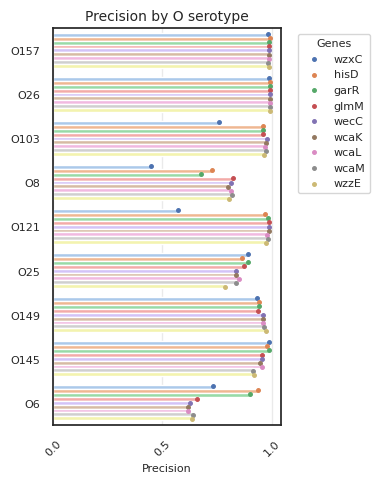

In [1632]:
df_melted = prc_table.T.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted.rename(columns={'index': 'Type'}, inplace=True)

#pastel_palette = sns.color_palette("deep")
# 박스 플롯 생성
plt.figure(figsize=(4, 5))
sns.set(style="white")
barplot = sns.barplot(x='Value', y='Feature', hue='Type', data=df_melted, alpha=1, palette=sns.color_palette("pastel"))
barplot.legend_.remove()
pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)

plt.title('Precision by O serotype', fontsize=10)
plt.xlabel('Precision', fontsize=8)
plt.ylabel('')
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
#plt.legend(title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#.yaxis.set_major_locator(MultipleLocator(0.2))
plt.grid(True, axis="x", alpha=0.4)

handles, labels = pointplot.get_legend_handles_labels()
plt.legend(handles=handles[0:len(df_melted['Type'].unique())], labels=labels[0:len(df_melted['Type'].unique())], title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_660/2427745591.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  pointplot = sns.pointplot(x='Feature', y='Value', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)


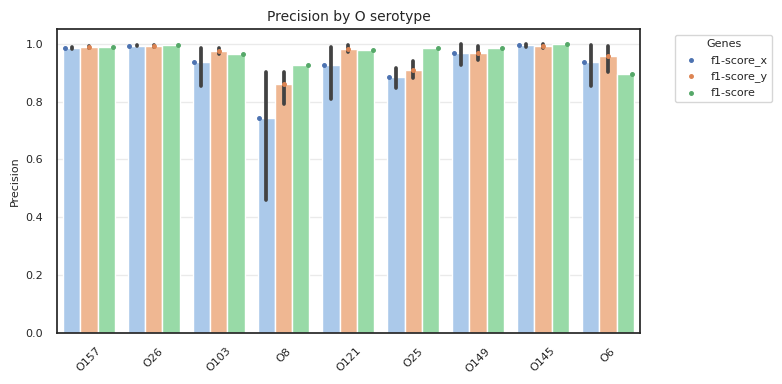

In [136]:
#df_melted = prc_table.loc[["O157", "O26", "O103", "O8", "O121"]].T.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted = prc_table.T.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted.rename(columns={'index': 'Type'}, inplace=True)

# 박스 플롯 생성
plt.figure(figsize=(8, 4))  # 가로 방향으로 그릴 때, 가로 폭을 더 크게 설정
sns.set(style="white")
barplot = sns.barplot(x='Feature', y='Value', hue='Type', data=df_melted, alpha=1, palette=sns.color_palette("pastel"))
barplot.legend_.remove()
pointplot = sns.pointplot(x='Feature', y='Value', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)

plt.title('Precision by O serotype', fontsize=10)
plt.ylabel('Precision', fontsize=8)  # y 축 이름을 Precision으로 변경
plt.xlabel('')
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True, axis="y", alpha=0.4)  # y 축에 그리드 추가

# 범례 설정
handles, labels = pointplot.get_legend_handles_labels()
plt.legend(handles=handles[0:len(df_melted['Type'].unique())], labels=labels[0:len(df_melted['Type'].unique())], title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2815099/2081617310.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)


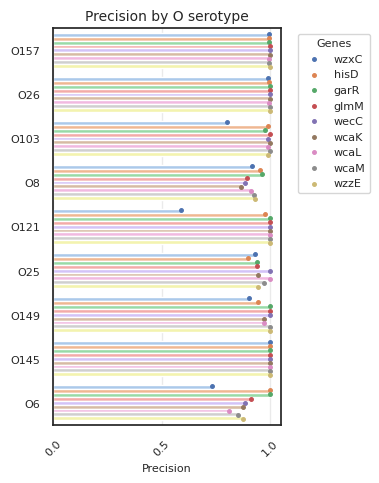

In [1120]:
df_melted = prc_table.T.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted.rename(columns={'index': 'Type'}, inplace=True)

#pastel_palette = sns.color_palette("deep")
# 박스 플롯 생성
plt.figure(figsize=(4, 5))
sns.set(style="white")
barplot = sns.barplot(x='Value', y='Feature', hue='Type', data=df_melted, alpha=1, palette=sns.color_palette("pastel"))
barplot.legend_.remove()
pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)

plt.title('Precision by O serotype', fontsize=10)
plt.xlabel('Precision', fontsize=8)
plt.ylabel('')
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
#plt.legend(title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#.yaxis.set_major_locator(MultipleLocator(0.2))
plt.grid(True, axis="x", alpha=0.4)

handles, labels = pointplot.get_legend_handles_labels()
plt.legend(handles=handles[0:len(df_melted['Type'].unique())], labels=labels[0:len(df_melted['Type'].unique())], title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

In [139]:
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O25", "O149", "O145", "O6"] # O111
i = 0
def recall_temp(i):
    recall_temp = pd.DataFrame(classification_report(gene_clsf_list[i]["DataMat"]["answer"],
                                   gene_clsf_list[i]["CVPredict"],
                                   output_dict=True)).T.drop(["accuracy", "macro avg", "weighted avg"]).sort_values(
                                    "support", ascending=False).loc[OtypeList]
    return recall_temp

recall_table = recall_temp(0)[["recall"]].rename(
    columns={"recall":ClusterMeta[str(gene_clsf_list[0]["clstrID"]["MBGD"])]["gene"]})

for i in range(1, len(gene_clsf_list)):    
    recall_table = pd.merge(recall_table,
                         recall_temp(i)[["recall"]].rename(
                           columns={"recall":ClusterMeta[str(gene_clsf_list[i]["clstrID"]["MBGD"])]["gene"]}),
                         left_index=True, right_index=True, how="outer")

KeyError: 'CVPredict'

In [137]:
recall_table

NameError: name 'recall_table' is not defined

/tmp/ipykernel_2815099/2481888821.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)


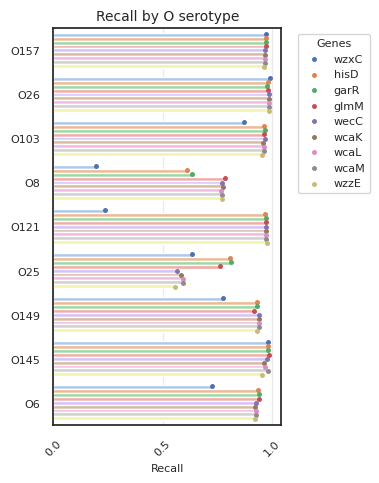

In [1664]:
df_melted = recall_table.T.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted.rename(columns={'index': 'Type'}, inplace=True)

#pastel_palette = sns.color_palette("deep")
# 박스 플롯 생성
plt.figure(figsize=(4, 5))
sns.set(style="white")
barplot = sns.barplot(x='Value', y='Feature', hue='Type', data=df_melted, alpha=1, palette=sns.color_palette("pastel"))
barplot.legend_.remove()
pointplot = sns.pointplot(x='Value', y='Feature', hue='Type', data=df_melted, dodge=0.75, join=False, palette=sns.color_palette("deep"), markers='o', scale=0.4, ci=None)

plt.title('Recall by O serotype', fontsize=10)
plt.xlabel('Recall', fontsize=8)
plt.ylabel('')
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
#plt.legend(title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#.yaxis.set_major_locator(MultipleLocator(0.2))
plt.grid(True, axis="x", alpha=0.4)

handles, labels = pointplot.get_legend_handles_labels()
plt.legend(handles=handles[0:len(df_melted['Type'].unique())], labels=labels[0:len(df_melted['Type'].unique())], title='Genes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

### 10. MSA analysisfor each gene clusters

In [31]:
for clstrMBGD, clstrCDHIT in target_clstr:
    with open("MSA/{}_{}.faa".format(clstrMBGD, clstrCDHIT), "w") as outfile: 
        with open("MBGD_clusters_faa/{}/{}.faa".format(clstrMBGD%1000, clstrMBGD)) as infile:
            for record in SeqIO.parse(infile, "fasta"):            
                for comp in CDHIT_clstr_dict[record.id.split(":")[0]]:
                    if comp == (clstrMBGD, int(clstrCDHIT)):
                        SeqIO.write(record, outfile, "fasta")

In [235]:
def alnSiteCompositionDF(aln, characters="ACDEFGHIKLMNPQRSTVWY"):
    alnRows = aln.get_alignment_length()
    compDict = {char:[0]*alnRows for char in characters}
    for record in aln:
        header = record.id
        seq = record.seq
        for aaPos in range(len(seq)):
            aa = seq[aaPos]
            if aa in characters:
                compDict[aa][aaPos] += 1    
    return pd.DataFrame.from_dict(compDict)

#### First, check with HisD gene 

In [892]:
target_file = "684_0" #684_0, 117_3, 66_0

am = AlignIO.read("MSA/{}.addfrag.mafft.msa".format(target_file), "fasta")

###

first_seq = am[0]
positions_to_remove = [pos for pos, char in enumerate(first_seq) if char == '-']
new_alignment = MultipleSeqAlignment([])
for record in am:
    new_seq = "".join([char for pos, char in enumerate(record.seq) if pos not in positions_to_remove])
    new_record = SeqRecord(Seq(new_seq), id=record.id, description=record.description)
    new_alignment.append(new_record)
    
am = new_alignment

###

alignment_length = am.get_alignment_length()
aa_composition = []

for i in range(alignment_length):
    column = am[:, i]
    aa_counts = {}
    total_count = len(column)

    for aa in column:
        if aa not in aa_counts:
            aa_counts[aa] = 1
        else:
            aa_counts[aa] += 1

    # Calculate the frequency of each amino acid
    aa_frequencies = {aa: count / total_count for aa, count in aa_counts.items()}
    aa_composition.append(aa_frequencies)
    
###

max_composition = [max(position.values()) for position in aa_composition]
df_max_composition = pd.DataFrame({
    'Position': range(1, len(max_composition) + 1),
    'Max Composition': max_composition
})

(0.5, 1.0)

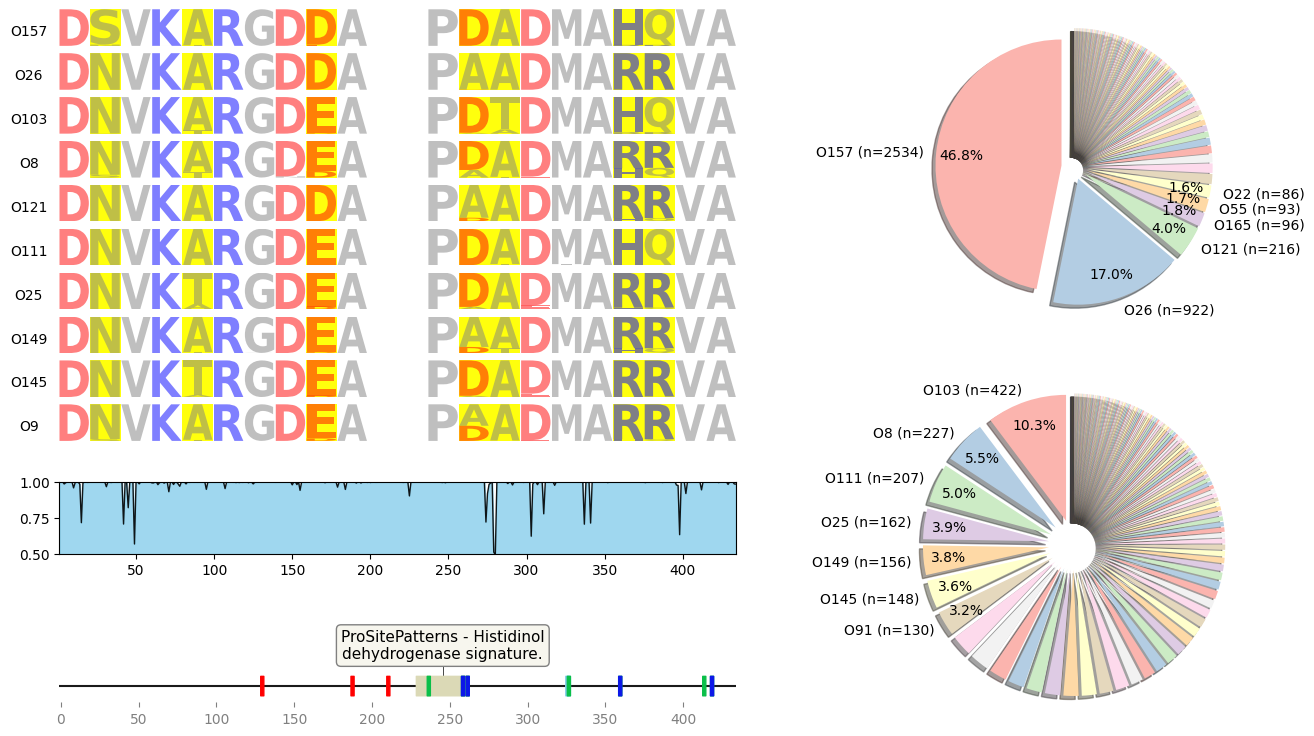

In [1087]:
target_file = "684_0" 

plt.figure(figsize=(16, 9))
target_pos = 48
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O9"]

### 
### 제일 윗부분 LOGO 그리는 부분 ###
### + 위치별 통계
###

msa_group_by = {}
target_pos_ratio = {}
for record in am:
    Otype = record.id.split(":")[1]
    msa_group_by.setdefault(Otype, [])
    msa_group_by[Otype].append((str(record.seq[40:50]), str(record.seq[272:282])))
    
    target_pos_ratio.setdefault(record.seq[target_pos], {})
    target_pos_ratio[record.seq[target_pos]].setdefault(Otype, 0)
    target_pos_ratio[record.seq[target_pos]][Otype] += 1

target_res = sorted(target_pos_ratio.items(), key=lambda item: sum(item[1].values()), reverse=True)
#print(target_res[0])
    
###

outermost_grid = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.2)

###



right_grid = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1, 1], subplot_spec=outermost_grid[1])


rx1 = plt.subplot(right_grid[0])
first_res = target_res[0]
O_stats = sorted(first_res[1].items(), key=lambda item: item[1], reverse=True)
#print(O_stats)

def my_autopct_1(pct):
    return ('%1.1f%%' % pct) if pct >= 1.5 else ''

rx1.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 6 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels
        shadow=True,
        pctdistance=0.80,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_1,
        explode=[0.1]*len(O_stats),
        startangle=90,
       )

rx2 = plt.subplot(right_grid[1])
second_res = target_res[1]

O_stats = sorted(second_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_2(pct):
    return ('%1.1f%%' % pct) if pct >= 3.0 else ''

rx2.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 7 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels 
        shadow=True,
        pctdistance=0.8,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_2,
        explode=[0.2]*len(O_stats),
        startangle=90,
       )


###

outer_grid = gridspec.GridSpecFromSubplotSpec(3, 1, height_ratios=[6, 1, 1.5], subplot_spec=outermost_grid[0])#, hspace=0.2)

   

#plt.style.use('default')

inner_grid = gridspec.GridSpecFromSubplotSpec(nrows=len(OtypeList), ncols=2, subplot_spec=outer_grid[0], width_ratios=[1, 1])

#axs1, axs2, axs3 = plt.subplot(inner_grid[0]), plt.subplot(inner_grid[1]), plt.subplot(inner_grid[2])
#fig, axs = ax1.subplots(nrows=len(OtypeList), ncols=2, figsize=[7,4], gridspec_kw={'width_ratios': [1, 1]})
highlights = [[1,4,8],
              [1,2,6,7],
             ]

for idx, Otype in enumerate(OtypeList):
    for i in range(2):
        #ax = fig.add_subplot()
        #ax = axs[idx,i]
        #ax = fig.add_subplot(gs[idx, i])
        ax = plt.subplot(inner_grid[idx, i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        if i == 0:
            ax.set_ylabel(OtypeList[idx], rotation="horizontal")
            ax.yaxis.set_label_coords(-0.1, 0.2)
        target_alignment = [seqs[i] for seqs in  msa_group_by[Otype]]
        #print(msa_group_by[Otype])
        counts_mat = lm.alignment_to_matrix(target_alignment)
        aa_logo = lm.Logo(counts_mat, color_scheme="charge", ax=ax, alpha=0.5)
        #aa_logo.style_xticks(anchor=0, spacing=5)
        for position in highlights[i]:
            aa_logo.highlight_position(p=position, color="Yellow", alpha=0.95)

###
### InterProScan 결과 그리는 부분 ###
###

features = []

with open("MSA/{}.interproscan.tsv".format(target_file), "r") as infile:
    for line in infile:
        fields = line.strip().split("\t")
        feat_name = fields[3]+" - "+fields[5]
        #feat_name = fields[3]
        #print(feat_name)
        if fields[3] not in ["ProSitePatterns"]: continue #Pfam
        _start, _end = int(fields[6]), int(fields[7])
        
        features.append(GraphicFeature(start=_start, end=_end, strand=0,
                                       label = feat_name,
                                       #label=None,
                                       open_left=True,
                                       open_right=True,
                                       color="#dbd9b6",
                                       linecolor="#dbd9b6",
        ))
        
with open("MSA/684.uniprot.features.json", "r") as infile:
    uniprot_features = json.load(infile)
    
for uniprot_feature in uniprot_features["features"]:
    _start = uniprot_feature["location"]["start"]["value"]
    _end = uniprot_feature["location"]["end"]["value"]
    #_name = ""
    flag = False
    
    if "ligand" in uniprot_feature:
        _name = None
        
        #_name = uniprot_feature["ligand"]["name"] + uniprot_feature["type"]
        #_name = uniprot_feature["ligand"]["name"]
        
        if uniprot_feature["ligand"]["name"] == "NAD(+)": _color, _linecolor, _alpha = "red", "red", 1
        elif uniprot_feature["ligand"]["name"] == "Zn(2+)": _color, _linecolor, _alpha = "#0c17e8", "#0c17e8", 0.4
        elif uniprot_feature["ligand"]["name"] == "substrate": _color, _linecolor, _alpha = "#0abf49", "#0abf49", 1
        
        #print(_start, _end, _color, _linecolor)
        
        flag = True
        
    elif uniprot_feature["type"] == "Active site":
        
        #_name = uniprot_feature["description"] + uniprot_feature["type"]
        #_name = uniprot_feature["description"]
        
        _name = None
        _color, _linecolor, _alpha = "skyblue", "skyblue", 1
        flag = True
        
    if flag:
        features.append(GraphicFeature(start=_start, end=_end, strand=0,
                                       label = _name,
                                       #label = None,
                                       open_left=True,
                                       open_right=True,
                                       color=_color,
                                       linecolor = _linecolor,
                                       alpha=_alpha, # 의미 없음
        ))
    

ax2 = plt.subplot(outer_grid[2])
record = GraphicRecord(sequence_length=max(df_max_composition['Position']), features=features, feature_level_height=0)
#record._format_label(feat_name, max_label_length=200, max_line_length=200)
record.plot(ax=ax2, max_label_length=100, max_line_length=40)#, figure_width=10)
#record.plot(ax=ax2)

ax3 = plt.subplot(outer_grid[1])
ax3.plot(df_max_composition['Position'], df_max_composition['Max Composition'], marker='', color="black", alpha=0.9, linewidth=1)
#ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.margins(x=0)
ax3.set_ylim(0.5,1)

In [1061]:
feature_json["features"][0]["type"] == "Active site"

True

In [1037]:
feature_json["features"][10]["type"]
feature_json["features"][10]["ligand"]["name"]
feature_json["features"][10]

{'type': 'Binding site',
 'location': {'start': {'value': 327, 'modifier': 'EXACT'},
  'end': {'value': 327, 'modifier': 'EXACT'}},
 'description': '',
 'evidences': [{'evidenceCode': 'ECO:0000305',
   'source': 'PubMed',
   'id': '11842181'}],
 'ligand': {'name': 'substrate'}}

#### garR gene

In [882]:
target_file = "66_0" #684_0, 117_3, 66_0

am = AlignIO.read("MSA/{}.addfrag.mafft.msa".format(target_file), "fasta")

###

first_seq = am[0]
positions_to_remove = [pos for pos, char in enumerate(first_seq) if char == '-']
new_alignment = MultipleSeqAlignment([])
for record in am:
    new_seq = "".join([char for pos, char in enumerate(record.seq) if pos not in positions_to_remove])
    new_record = SeqRecord(Seq(new_seq), id=record.id, description=record.description)
    new_alignment.append(new_record)
    
am = new_alignment

###

alignment_length = am.get_alignment_length()
aa_composition = []

for i in range(alignment_length):
    column = am[:, i]
    aa_counts = {}
    total_count = len(column)

    for aa in column:
        if aa not in aa_counts:
            aa_counts[aa] = 1
        else:
            aa_counts[aa] += 1

    # Calculate the frequency of each amino acid
    aa_frequencies = {aa: count / total_count for aa, count in aa_counts.items()}
    aa_composition.append(aa_frequencies)
    
###

max_composition = [max(position.values()) for position in aa_composition]
df_max_composition = pd.DataFrame({
    'Position': range(1, len(max_composition) + 1),
    'Max Composition': max_composition
})

(0.5, 1.0)

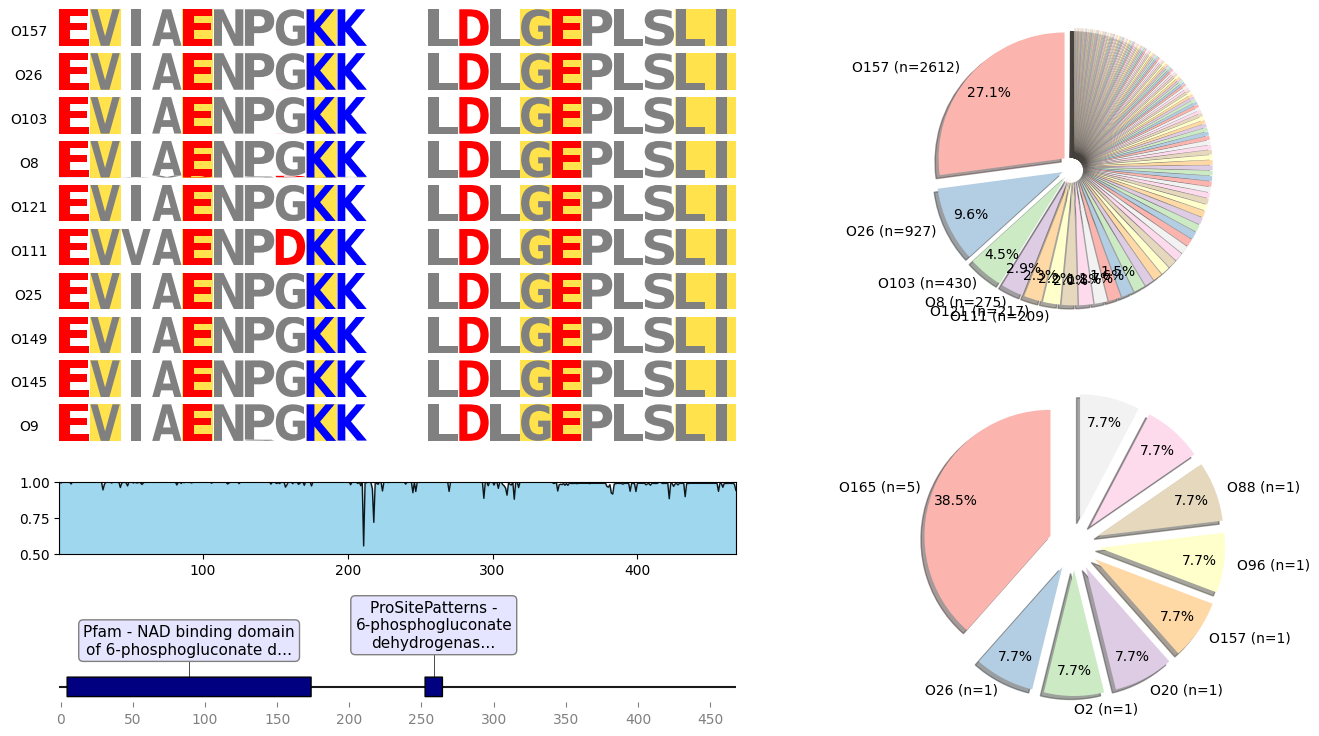

In [886]:
target_file = "66_0" 

plt.figure(figsize=(16, 9))
target_pos = 48
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O9"]

### 
### 제일 윗부분 LOGO 그리는 부분 ###
### + 위치별 통계
###

msa_group_by = {}
target_pos_ratio = {}
for record in am:
    Otype = record.id.split(":")[1]
    msa_group_by.setdefault(Otype, [])
    msa_group_by[Otype].append((str(record.seq[40:50]), str(record.seq[270:280])))
    
    target_pos_ratio.setdefault(record.seq[target_pos], {})
    target_pos_ratio[record.seq[target_pos]].setdefault(Otype, 0)
    target_pos_ratio[record.seq[target_pos]][Otype] += 1

target_res = sorted(target_pos_ratio.items(), key=lambda item: sum(item[1].values()), reverse=True)
#print(target_res[0])
    
###

outermost_grid = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.2)

###



right_grid = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1, 1], subplot_spec=outermost_grid[1])


rx1 = plt.subplot(right_grid[0])
first_res = target_res[0]
O_stats = sorted(first_res[1].items(), key=lambda item: item[1], reverse=True)
#print(O_stats)

def my_autopct_1(pct):
    return ('%1.1f%%' % pct) if pct >= 1.5 else ''

rx1.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 6 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels
        shadow=True,
        pctdistance=0.80,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_1,
        explode=[0.1]*len(O_stats),
        startangle=90,
       )

rx2 = plt.subplot(right_grid[1])
second_res = target_res[1]

O_stats = sorted(second_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_2(pct):
    return ('%1.1f%%' % pct) if pct >= 3.0 else ''

rx2.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 7 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels 
        shadow=True,
        pctdistance=0.8,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_2,
        explode=[0.2]*len(O_stats),
        startangle=90,
       )


###

outer_grid = gridspec.GridSpecFromSubplotSpec(3, 1, height_ratios=[6, 1, 1.5], subplot_spec=outermost_grid[0], hspace=0.2)

   

#plt.style.use('default')

inner_grid = gridspec.GridSpecFromSubplotSpec(nrows=len(OtypeList), ncols=2, subplot_spec=outer_grid[0], width_ratios=[1, 1])

#axs1, axs2, axs3 = plt.subplot(inner_grid[0]), plt.subplot(inner_grid[1]), plt.subplot(inner_grid[2])
#fig, axs = ax1.subplots(nrows=len(OtypeList), ncols=2, figsize=[7,4], gridspec_kw={'width_ratios': [1, 1]})
highlights = [[1,4,8],
              [3,4,8,9],
             ]

for idx, Otype in enumerate(OtypeList):
    for i in range(2):
        #ax = fig.add_subplot()
        #ax = axs[idx,i]
        #ax = fig.add_subplot(gs[idx, i])
        ax = plt.subplot(inner_grid[idx, i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        if i == 0:
            ax.set_ylabel(OtypeList[idx], rotation="horizontal")
            ax.yaxis.set_label_coords(-0.1, 0.2)
        target_alignment = [seqs[i] for seqs in  msa_group_by[Otype]]
        #print(msa_group_by[Otype])
        counts_mat = lm.alignment_to_matrix(target_alignment)
        aa_logo = lm.Logo(counts_mat, color_scheme="charge", ax=ax)
        #aa_logo.style_xticks(anchor=0, spacing=5)
        for position in highlights[i]:
            aa_logo.highlight_position(p=position, color="gold", alpha=.7)

###
### InterProScan 결과 그리는 부분 ###
###

features = []

with open("MSA/{}.interproscan.tsv".format(target_file), "r") as infile:
    for line in infile:
        fields = line.strip().split("\t")
        feat_name = fields[3]+" - "+fields[5]
        #print(feat_name)
        #if fields[3] not in ["ProSitePatterns", "Pfam"]: continue #Pfam
        if "bind" not in feat_name:
            if fields[3] not in ["ProSitePatterns"]:
                continue
        else:
            if fields[3] in ["SUPERFAMILY"]:
                continue
        _start, _end = int(fields[6]), int(fields[7])
        
        features.append(GraphicFeature(start=_start, end=_end, strand=0,
                                       label = feat_name
        ))

ax2 = plt.subplot(outer_grid[2])
record = GraphicRecord(sequence_length=max(df_max_composition['Position']), features=features)
record.plot(ax=ax2)#, figure_width=10)

ax3 = plt.subplot(outer_grid[1])
ax3.plot(df_max_composition['Position'], df_max_composition['Max Composition'], marker='', color="black", alpha=0.9, linewidth=1)
#ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.margins(x=0)
ax3.set_ylim(0.5,1)

#### check with GlmM gene 

In [887]:
target_file = "117_3" #684_0, 117_3, 66_0

am = AlignIO.read("MSA/{}.addfrag.mafft.msa".format(target_file), "fasta")

###

first_seq = am[0]
positions_to_remove = [pos for pos, char in enumerate(first_seq) if char == '-']
new_alignment = MultipleSeqAlignment([])
for record in am:
    new_seq = "".join([char for pos, char in enumerate(record.seq) if pos not in positions_to_remove])
    new_record = SeqRecord(Seq(new_seq), id=record.id, description=record.description)
    new_alignment.append(new_record)
    
am = new_alignment

###

alignment_length = am.get_alignment_length()
aa_composition = []

for i in range(alignment_length):
    column = am[:, i]
    aa_counts = {}
    total_count = len(column)

    for aa in column:
        if aa not in aa_counts:
            aa_counts[aa] = 1
        else:
            aa_counts[aa] += 1

    # Calculate the frequency of each amino acid
    aa_frequencies = {aa: count / total_count for aa, count in aa_counts.items()}
    aa_composition.append(aa_frequencies)
    
###

max_composition = [max(position.values()) for position in aa_composition]
df_max_composition = pd.DataFrame({
    'Position': range(1, len(max_composition) + 1),
    'Max Composition': max_composition
})

(0.5, 1.0)

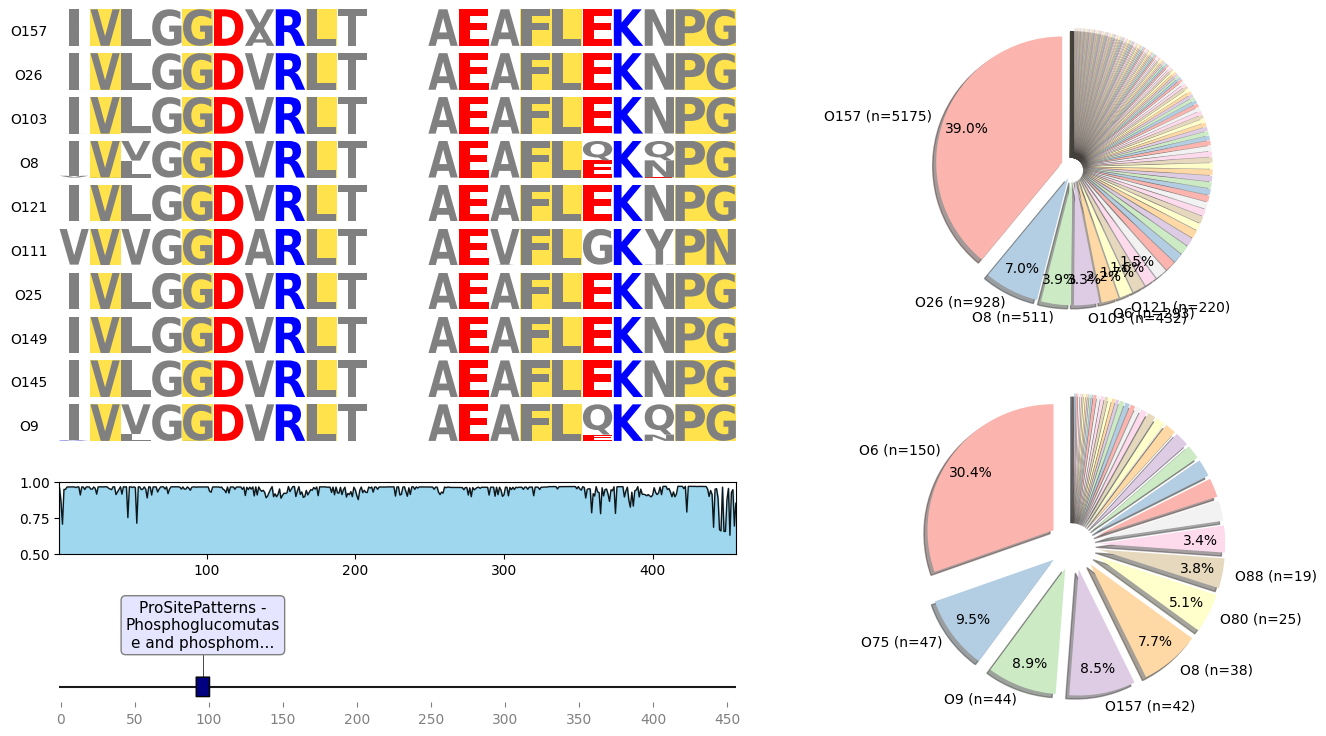

In [889]:
target_file = "117_3" 

plt.figure(figsize=(16, 9))
target_pos = 48
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O9"]

### 
### 제일 윗부분 LOGO 그리는 부분 ###
### + 위치별 통계
###

msa_group_by = {}
target_pos_ratio = {}
for record in am:
    Otype = record.id.split(":")[1]
    msa_group_by.setdefault(Otype, [])
    msa_group_by[Otype].append((str(record.seq[40:50]), str(record.seq[270:280])))
    
    target_pos_ratio.setdefault(record.seq[target_pos], {})
    target_pos_ratio[record.seq[target_pos]].setdefault(Otype, 0)
    target_pos_ratio[record.seq[target_pos]][Otype] += 1

target_res = sorted(target_pos_ratio.items(), key=lambda item: sum(item[1].values()), reverse=True)
#print(target_res[0])
    
###

outermost_grid = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.2)

###



right_grid = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1, 1], subplot_spec=outermost_grid[1])


rx1 = plt.subplot(right_grid[0])
first_res = target_res[0]
O_stats = sorted(first_res[1].items(), key=lambda item: item[1], reverse=True)
#print(O_stats)

def my_autopct_1(pct):
    return ('%1.1f%%' % pct) if pct >= 1.5 else ''

rx1.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 6 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels
        shadow=True,
        pctdistance=0.80,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_1,
        explode=[0.1]*len(O_stats),
        startangle=90,
       )

rx2 = plt.subplot(right_grid[1])
second_res = target_res[1]

O_stats = sorted(second_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_2(pct):
    return ('%1.1f%%' % pct) if pct >= 3.0 else ''

rx2.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 7 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels 
        shadow=True,
        pctdistance=0.8,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_2,
        explode=[0.2]*len(O_stats),
        startangle=90,
       )


###

outer_grid = gridspec.GridSpecFromSubplotSpec(3, 1, height_ratios=[6, 1, 1.5], subplot_spec=outermost_grid[0], hspace=0.2)

   

#plt.style.use('default')

inner_grid = gridspec.GridSpecFromSubplotSpec(nrows=len(OtypeList), ncols=2, subplot_spec=outer_grid[0], width_ratios=[1, 1])

#axs1, axs2, axs3 = plt.subplot(inner_grid[0]), plt.subplot(inner_grid[1]), plt.subplot(inner_grid[2])
#fig, axs = ax1.subplots(nrows=len(OtypeList), ncols=2, figsize=[7,4], gridspec_kw={'width_ratios': [1, 1]})
highlights = [[1,4,8],
              [3,4,8,9],
             ]

for idx, Otype in enumerate(OtypeList):
    for i in range(2):
        #ax = fig.add_subplot()
        #ax = axs[idx,i]
        #ax = fig.add_subplot(gs[idx, i])
        ax = plt.subplot(inner_grid[idx, i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        if i == 0:
            ax.set_ylabel(OtypeList[idx], rotation="horizontal")
            ax.yaxis.set_label_coords(-0.1, 0.2)
        target_alignment = [seqs[i] for seqs in  msa_group_by[Otype]]
        #print(msa_group_by[Otype])
        counts_mat = lm.alignment_to_matrix(target_alignment)
        aa_logo = lm.Logo(counts_mat, color_scheme="charge", ax=ax)
        #aa_logo.style_xticks(anchor=0, spacing=5)
        for position in highlights[i]:
            aa_logo.highlight_position(p=position, color="gold", alpha=.7)

###
### InterProScan 결과 그리는 부분 ###
###

features = []

with open("MSA/{}.interproscan.tsv".format(target_file), "r") as infile:
    for line in infile:
        fields = line.strip().split("\t")
        feat_name = fields[3]+" - "+fields[5]
        #print(feat_name)
        if "bind" not in feat_name:
            if fields[3] not in ["ProSitePatterns"]: continue #Pfam
        _start, _end = int(fields[6]), int(fields[7])
        
        features.append(GraphicFeature(start=_start, end=_end, strand=0,
                                       label = feat_name
        ))

ax2 = plt.subplot(outer_grid[2])
record = GraphicRecord(sequence_length=max(df_max_composition['Position']), features=features)
record.plot(ax=ax2)#, figure_width=10)

ax3 = plt.subplot(outer_grid[1])
ax3.plot(df_max_composition['Position'], df_max_composition['Max Composition'], marker='', color="black", alpha=0.9, linewidth=1)
#ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.margins(x=0)
ax3.set_ylim(0.5,1)

#### WecC

In [890]:
target_file = "201_1" #684_0, 117_3, 66_0

am = AlignIO.read("MSA/{}.addfrag.mafft.msa".format(target_file), "fasta")

###

first_seq = am[0]
positions_to_remove = [pos for pos, char in enumerate(first_seq) if char == '-']
new_alignment = MultipleSeqAlignment([])
for record in am:
    new_seq = "".join([char for pos, char in enumerate(record.seq) if pos not in positions_to_remove])
    new_record = SeqRecord(Seq(new_seq), id=record.id, description=record.description)
    new_alignment.append(new_record)
    
am = new_alignment

###

alignment_length = am.get_alignment_length()
aa_composition = []

for i in range(alignment_length):
    column = am[:, i]
    aa_counts = {}
    total_count = len(column)

    for aa in column:
        if aa not in aa_counts:
            aa_counts[aa] = 1
        else:
            aa_counts[aa] += 1

    # Calculate the frequency of each amino acid
    aa_frequencies = {aa: count / total_count for aa, count in aa_counts.items()}
    aa_composition.append(aa_frequencies)
    
###

max_composition = [max(position.values()) for position in aa_composition]
df_max_composition = pd.DataFrame({
    'Position': range(1, len(max_composition) + 1),
    'Max Composition': max_composition
})

(0.5, 1.0)

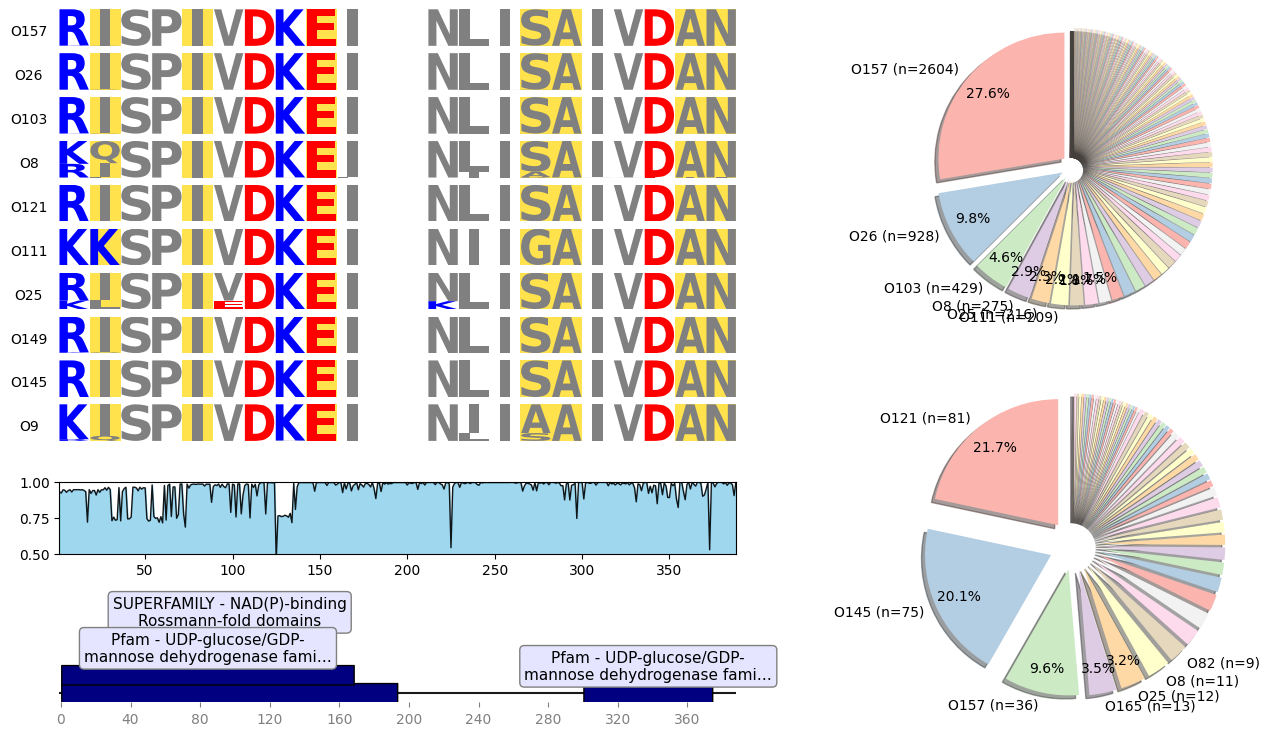

In [891]:
target_file = "201_1"

plt.figure(figsize=(16, 9))
target_pos = 48
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O9"]

### 
### 제일 윗부분 LOGO 그리는 부분 ###
### + 위치별 통계
###

msa_group_by = {}
target_pos_ratio = {}
for record in am:
    Otype = record.id.split(":")[1]
    msa_group_by.setdefault(Otype, [])
    msa_group_by[Otype].append((str(record.seq[40:50]), str(record.seq[270:280])))
    
    target_pos_ratio.setdefault(record.seq[target_pos], {})
    target_pos_ratio[record.seq[target_pos]].setdefault(Otype, 0)
    target_pos_ratio[record.seq[target_pos]][Otype] += 1

target_res = sorted(target_pos_ratio.items(), key=lambda item: sum(item[1].values()), reverse=True)
#print(target_res[0])
    
###

outermost_grid = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.2)

###



right_grid = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1, 1], subplot_spec=outermost_grid[1])


rx1 = plt.subplot(right_grid[0])
first_res = target_res[0]
O_stats = sorted(first_res[1].items(), key=lambda item: item[1], reverse=True)
#print(O_stats)

def my_autopct_1(pct):
    return ('%1.1f%%' % pct) if pct >= 1.5 else ''

rx1.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 6 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels
        shadow=True,
        pctdistance=0.80,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_1,
        explode=[0.1]*len(O_stats),
        startangle=90,
       )

rx2 = plt.subplot(right_grid[1])
second_res = target_res[1]

O_stats = sorted(second_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_2(pct):
    return ('%1.1f%%' % pct) if pct >= 3.0 else ''

rx2.pie([stats[1] for stats in O_stats], # Sizes
        labels=[lb+" (n={})".format(O_stats[idx][1]) if idx < 7 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)], # Labels 
        shadow=True,
        pctdistance=0.8,
        colors=plt.cm.Pastel1.colors,
        autopct=my_autopct_2,
        explode=[0.2]*len(O_stats),
        startangle=90,
       )


###

outer_grid = gridspec.GridSpecFromSubplotSpec(3, 1, height_ratios=[6, 1, 1.5], subplot_spec=outermost_grid[0], hspace=0.2)

   

#plt.style.use('default')

inner_grid = gridspec.GridSpecFromSubplotSpec(nrows=len(OtypeList), ncols=2, subplot_spec=outer_grid[0], width_ratios=[1, 1])

#axs1, axs2, axs3 = plt.subplot(inner_grid[0]), plt.subplot(inner_grid[1]), plt.subplot(inner_grid[2])
#fig, axs = ax1.subplots(nrows=len(OtypeList), ncols=2, figsize=[7,4], gridspec_kw={'width_ratios': [1, 1]})
highlights = [[1,4,8],
              [3,4,8,9],
             ]

for idx, Otype in enumerate(OtypeList):
    for i in range(2):
        #ax = fig.add_subplot()
        #ax = axs[idx,i]
        #ax = fig.add_subplot(gs[idx, i])
        ax = plt.subplot(inner_grid[idx, i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        if i == 0:
            ax.set_ylabel(OtypeList[idx], rotation="horizontal")
            ax.yaxis.set_label_coords(-0.1, 0.2)
        target_alignment = [seqs[i] for seqs in  msa_group_by[Otype]]
        #print(msa_group_by[Otype])
        counts_mat = lm.alignment_to_matrix(target_alignment)
        aa_logo = lm.Logo(counts_mat, color_scheme="charge", ax=ax)
        #aa_logo.style_xticks(anchor=0, spacing=5)
        for position in highlights[i]:
            aa_logo.highlight_position(p=position, color="gold", alpha=.7)

###
### InterProScan 결과 그리는 부분 ###
###

features = []

with open("MSA/{}.interproscan.tsv".format(target_file), "r") as infile:
    for line in infile:
        fields = line.strip().split("\t")
        feat_name = fields[3]+" - "+fields[5]
        #print(feat_name)
        #if fields[3] not in ["ProSitePatterns", "Pfam"]: continue #Pfam
        if "bind" not in feat_name:
            if fields[3] not in ["ProSitePatterns"]:
                continue
        _start, _end = int(fields[6]), int(fields[7])
        
        features.append(GraphicFeature(start=_start, end=_end, strand=0,
                                       label = feat_name
        ))

ax2 = plt.subplot(outer_grid[2])
record = GraphicRecord(sequence_length=max(df_max_composition['Position']), features=features)
record.plot(ax=ax2)#, figure_width=10)

ax3 = plt.subplot(outer_grid[1])
ax3.plot(df_max_composition['Position'], df_max_composition['Max Composition'], marker='', color="black", alpha=0.9, linewidth=1)
#ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.fill_between(df_max_composition['Position'], df_max_composition['Max Composition'], color='skyblue', alpha=0.8)
ax3.margins(x=0)
ax3.set_ylim(0.5,1)

### 11. Make model with all O serotype-related genes 

In [618]:
DataMat_list = []
dimVec = 320
temp_vecs = {}

for clstrMBGD, clstrCDHIT in target_clstr:
    DataMat = {"acc":[], "answer":[]}
    for i in range(dimVec):
        DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)] = []        
        
    with open("MBGD_clusters_cdhit/{}/{}_{}.vecs".format(int(clstrMBGD)%1000, clstrMBGD, clstrCDHIT), "r") as infile:
        for line in infile:
            if line.startswith(">"): # odd lines
                acc, O, H = line.strip("\n").strip(">").split(":")[:3]
                continue
            else:
                sample_acc = acc.split("|")[0].split(".")[0].replace("_genomic", "")
                if sample_acc in OHtable:
                    vecs = line.strip("\n").split(" ")
                    temp_vecs.setdefault(sample_acc, [])
                    temp_vecs[sample_acc].append([float(vec) for vec in vecs])
                    
        duplicate_count = 0
        for sample_acc in temp_vecs:
            mean_vec = np.mean(temp_vecs[sample_acc], axis = 0)
            DataMat["acc"].append(sample_acc)
            DataMat["answer"].append(OHtable[sample_acc][0])
            for i in range(len(mean_vec)):
                DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)].append(mean_vec[i])
            if len(temp_vecs[sample_acc]) > 1: duplicate_count += 1
        #print(duplicate_count)
        
    DataMat_list.append(pd.DataFrame(DataMat))

In [1543]:
print(duplicate_count)

9538


In [1556]:
DataMat_list[0]

,acc,answer,MBGD1911_CDHIT0_v0,MBGD1911_CDHIT0_v1,MBGD1911_CDHIT0_v2,MBGD1911_CDHIT0_v3,MBGD1911_CDHIT0_v4,MBGD1911_CDHIT0_v5,MBGD1911_CDHIT0_v6,MBGD1911_CDHIT0_v7,...,MBGD1911_CDHIT0_v310,MBGD1911_CDHIT0_v311,MBGD1911_CDHIT0_v312,MBGD1911_CDHIT0_v313,MBGD1911_CDHIT0_v314,MBGD1911_CDHIT0_v315,MBGD1911_CDHIT0_v316,MBGD1911_CDHIT0_v317,MBGD1911_CDHIT0_v318,MBGD1911_CDHIT0_v319
0,ESC_WA9194AA_AS,O103,-0.041374,-0.020403,0.355850,0.188765,0.015738,-0.148668,-0.022359,-0.079294,...,-0.024481,0.006376,-0.029504,0.071570,0.045503,0.053914,-0.038993,0.159895,0.047145,0.198038
1,ESC_IC0849AA_AS,O26,-0.026937,0.004451,0.353622,0.179119,-0.019858,-0.175519,-0.030774,-0.076648,...,-0.040665,0.013483,-0.045980,0.081517,0.044293,0.059160,-0.050886,0.130697,0.064409,0.208223
2,ESC_IC0814AA_AS,O26,-0.069832,0.155147,0.322466,0.150924,-0.055135,-0.080169,0.008754,-0.082179,...,-0.116398,0.085383,-0.028954,0.039357,0.021656,-0.085468,-0.096272,0.121437,-0.000128,0.211809
3,ESC_IC4460AA_AS,O45,-0.048297,0.027791,0.370220,0.201571,-0.044902,-0.163182,-0.017984,-0.076089,...,-0.044881,0.017809,-0.045885,0.061306,0.036233,0.033134,-0.068109,0.129655,0.039758,0.241145
4,ESC_WA9273AA_AS,O88,-0.074144,0.155663,0.347382,0.168043,0.063973,-0.064858,0.012259,-0.108077,...,-0.128071,0.085198,-0.059547,0.013009,0.042354,-0.052107,-0.073438,0.133453,-0.008480,0.224804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9096,ESC_FC7528AA_AS,O165,-0.099079,0.216267,0.406196,0.194170,0.011439,-0.087805,0.112050,-0.088928,...,-0.163859,0.019075,-0.147917,0.017894,0.084333,-0.054253,-0.074459,0.217446,-0.090441,0.332016
9097,ESC_GC7513AA_AS,O165,-0.099079,0.216267,0.406196,0.194170,0.011439,-0.087805,0.112050,-0.088928,...,-0.163859,0.019075,-0.147917,0.017894,0.084333,-0.054253,-0.074459,0.217446,-0.090441,0.332016
9098,ESC_TA2167AA_AS,O25,-0.093719,0.179401,0.403718,0.201563,0.040238,-0.109353,0.127868,-0.117365,...,-0.137905,0.032260,-0.143855,-0.000307,0.115989,-0.042201,-0.070243,0.191264,-0.087154,0.344947
9099,ESC_HA9918AA_AS,O136,-0.075517,0.139673,0.385956,0.188540,0.017681,-0.092639,0.092992,-0.083692,...,-0.156088,0.009175,-0.129219,0.014494,0.061576,-0.040926,-0.081918,0.204677,-0.082018,0.285814


In [1555]:
DataMat_allgene = DataMat_list[1]

for i in [j for j in range(2, len(DataMat_list))]:
    DataMat_allgene = DataMat_allgene.merge(DataMat_list[i].drop('answer', axis=1), left_on = "acc", right_on = "acc")

DataMat_allgene

,acc,answer,MBGD684_CDHIT0_v0,MBGD684_CDHIT0_v1,MBGD684_CDHIT0_v2,MBGD684_CDHIT0_v3,MBGD684_CDHIT0_v4,MBGD684_CDHIT0_v5,MBGD684_CDHIT0_v6,MBGD684_CDHIT0_v7,...,MBGD7478_CDHIT4_v310,MBGD7478_CDHIT4_v311,MBGD7478_CDHIT4_v312,MBGD7478_CDHIT4_v313,MBGD7478_CDHIT4_v314,MBGD7478_CDHIT4_v315,MBGD7478_CDHIT4_v316,MBGD7478_CDHIT4_v317,MBGD7478_CDHIT4_v318,MBGD7478_CDHIT4_v319
0,ESC_WA9194AA_AS,O103,-0.064089,0.004280,0.251786,0.107711,0.069841,-0.092719,0.015529,-0.089750,...,-0.076960,-0.002971,-0.001243,0.081685,0.043393,-0.110099,-0.111353,0.167942,-0.018575,0.012998
1,ESC_IC0849AA_AS,O26,-0.055227,0.020347,0.249250,0.100844,0.045755,-0.109174,0.007843,-0.086366,...,-0.078316,-0.002525,0.001287,0.083899,0.041645,-0.104942,-0.109295,0.162048,-0.013404,0.016024
2,ESC_IC0814AA_AS,O26,-0.083824,0.120810,0.228480,0.082048,0.022236,-0.045608,0.034195,-0.090053,...,-0.092173,0.012142,0.007563,0.075460,0.039364,-0.134151,-0.116764,0.162363,-0.024718,0.016775
3,ESC_IC4460AA_AS,O45,-0.069863,0.033705,0.258794,0.120590,0.029611,-0.102213,0.015941,-0.085395,...,-0.058781,0.003540,0.008866,0.070731,0.049228,-0.101754,-0.116471,0.148062,-0.003507,0.025468
4,ESC_WA9273AA_AS,O88,-0.082880,0.130933,0.272993,0.114571,0.091685,-0.041965,0.030579,-0.107894,...,-0.073768,0.023898,-0.013686,0.050946,0.051825,-0.144559,-0.118048,0.152024,-0.001682,0.017759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9533,ESC_ZB5922AA_AS,O111,-0.108585,0.051156,0.043469,-0.057081,0.176274,0.024256,0.097176,-0.111974,...,-0.029148,0.056047,-0.005588,0.104650,0.082309,-0.182189,-0.082546,0.117712,-0.004971,0.024992
9534,ESC_SA8308AA_AS,O111,-0.108956,0.052344,0.041550,-0.065436,0.175821,0.021233,0.091624,-0.109577,...,-0.028349,0.055013,-0.004799,0.104325,0.082151,-0.181951,-0.081563,0.117839,-0.003485,0.023894
9535,ESC_TA2251AA_AS,O9,-0.115584,0.049921,0.042948,-0.058060,0.186715,0.019458,0.090922,-0.107048,...,-0.034333,0.032849,-0.045194,0.079314,0.102952,-0.223324,-0.070774,0.105064,0.011606,-0.007375
9536,ESC_AC4864AA_AS,O9,-0.102641,0.048481,0.047120,-0.024606,0.163865,0.048413,0.085212,-0.118461,...,-0.028092,0.039458,-0.010376,0.077553,0.074043,-0.218167,-0.082194,0.118305,0.018400,-0.019910


In [1564]:
DataMat_allgene_1911 = pd.merge(DataMat_allgene, DataMat_list[0].drop('answer', axis=1), on='acc', how='left').fillna(0)

In [1565]:
DataMat_allgene_1911

,acc,answer,MBGD684_CDHIT0_v0,MBGD684_CDHIT0_v1,MBGD684_CDHIT0_v2,MBGD684_CDHIT0_v3,MBGD684_CDHIT0_v4,MBGD684_CDHIT0_v5,MBGD684_CDHIT0_v6,MBGD684_CDHIT0_v7,...,MBGD1911_CDHIT0_v310,MBGD1911_CDHIT0_v311,MBGD1911_CDHIT0_v312,MBGD1911_CDHIT0_v313,MBGD1911_CDHIT0_v314,MBGD1911_CDHIT0_v315,MBGD1911_CDHIT0_v316,MBGD1911_CDHIT0_v317,MBGD1911_CDHIT0_v318,MBGD1911_CDHIT0_v319
0,ESC_WA9194AA_AS,O103,-0.064089,0.004280,0.251786,0.107711,0.069841,-0.092719,0.015529,-0.089750,...,-0.024481,0.006376,-0.029504,0.071570,0.045503,0.053914,-0.038993,0.159895,0.047145,0.198038
1,ESC_IC0849AA_AS,O26,-0.055227,0.020347,0.249250,0.100844,0.045755,-0.109174,0.007843,-0.086366,...,-0.040665,0.013483,-0.045980,0.081517,0.044293,0.059160,-0.050886,0.130697,0.064409,0.208223
2,ESC_IC0814AA_AS,O26,-0.083824,0.120810,0.228480,0.082048,0.022236,-0.045608,0.034195,-0.090053,...,-0.116398,0.085383,-0.028954,0.039357,0.021656,-0.085468,-0.096272,0.121437,-0.000128,0.211809
3,ESC_IC4460AA_AS,O45,-0.069863,0.033705,0.258794,0.120590,0.029611,-0.102213,0.015941,-0.085395,...,-0.044881,0.017809,-0.045885,0.061306,0.036233,0.033134,-0.068109,0.129655,0.039758,0.241145
4,ESC_WA9273AA_AS,O88,-0.082880,0.130933,0.272993,0.114571,0.091685,-0.041965,0.030579,-0.107894,...,-0.128071,0.085198,-0.059547,0.013009,0.042354,-0.052107,-0.073438,0.133453,-0.008480,0.224804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9533,ESC_ZB5922AA_AS,O111,-0.108585,0.051156,0.043469,-0.057081,0.176274,0.024256,0.097176,-0.111974,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9534,ESC_SA8308AA_AS,O111,-0.108956,0.052344,0.041550,-0.065436,0.175821,0.021233,0.091624,-0.109577,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9535,ESC_TA2251AA_AS,O9,-0.115584,0.049921,0.042948,-0.058060,0.186715,0.019458,0.090922,-0.107048,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9536,ESC_AC4864AA_AS,O9,-0.102641,0.048481,0.047120,-0.024606,0.163865,0.048413,0.085212,-0.118461,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [1603]:
dict(DataMat_allgene["answer"].value_counts())["O121"]

217

In [1566]:
#Y = DataMat_allgene["answer"].astype("category")
#X = DataMat_allgene.drop(["answer", "acc"], axis=1)
Y = DataMat_allgene_1911["answer"].astype("category")
X = DataMat_allgene_1911.drop(["answer", "acc"], axis=1)

RF_estimator = RandomForestClassifier(n_estimators=100, random_state=int(time.time()), n_jobs=40, criterion="entropy", max_depth=10, class_weight="balanced")
scores = cross_val_score(RF_estimator, X, Y, cv=StratifiedKFold(n_splits = 10))

print(scores.mean(), scores.std())

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


0.8923213904672656 0.019223014347414014


### 12. Feature Importance for elucidating key gene for O serotype determination

In [1253]:
nFold = 5.0
target_O_list = [label for label, count in dict(DataMat_allgene["answer"].value_counts()).items() if count >= nFold]

DataMat_test = DataMat_allgene
DataMat_test = DataMat_test[DataMat_test["answer"].isin(target_O_list)]

In [1391]:
Y = DataMat_test["answer"].astype("category")
X = DataMat_test.drop(["answer", "acc"], axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)
RF_estimator.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, n_jobs=40, random_state=33)

In [1392]:
print(metrics.classification_report(list(y_test), list(RF_estimator.predict(x_test))))

              precision    recall  f1-score   support

          O1       0.90      1.00      0.95        19
        O100       1.00      0.67      0.80         3
        O102       1.00      0.75      0.86         4
        O103       0.95      0.92      0.93        86
        O104       0.89      0.94      0.92        18
        O108       1.00      0.89      0.94         9
        O109       0.62      0.83      0.71         6
         O11       0.75      0.86      0.80         7
        O112       0.75      1.00      0.86         3
        O113       0.89      0.94      0.92        18
        O114       0.80      1.00      0.89         4
        O116       0.75      0.75      0.75         4
        O117       1.00      0.80      0.89        10
        O118       0.80      1.00      0.89         4
        O119       0.00      0.00      0.00         2
        O120       0.50      0.50      0.50         2
        O121       0.98      0.98      0.98        43
        O124       1.00    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [1256]:
start_time = time.time()
importances = RF_estimator.feature_importances_
std = np.std([tree.feature_importances_ for tree in RF_estimator.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.068 seconds


In [1257]:
feature_names = DataMat.drop(["answer", "acc"], axis=1).columns
forest_importances = pd.Series(importances, index=feature_names)
top15 = forest_importances.sort_values(ascending=False)[:15]

top15

MBGD201_CDHIT1_v16      0.005996
MBGD2726_CDHIT0_v256    0.004528
MBGD19_CDHIT11_v227     0.003933
MBGD19_CDHIT11_v16      0.003852
MBGD7478_CDHIT4_v157    0.003819
MBGD2726_CDHIT0_v157    0.003614
MBGD201_CDHIT1_v41      0.003478
MBGD117_CDHIT3_v127     0.003329
MBGD201_CDHIT1_v157     0.003146
MBGD19_CDHIT11_v238     0.003137
MBGD19_CDHIT11_v229     0.003089
MBGD7478_CDHIT4_v315    0.003036
MBGD2726_CDHIT0_v140    0.003035
MBGD2726_CDHIT0_v211    0.002929
MBGD117_CDHIT3_v307     0.002821
dtype: float64

In [1258]:
[ClusterMeta[a.split("_")[0].strip("MBGD")]["gene"]+"_"+a.split("_")[-1] for a in list(top15.index)]

['wecC_v16',
 'wcaK_v256',
 'wcaL_v227',
 'wcaL_v16',
 'wzzE_v157',
 'wcaK_v157',
 'wecC_v41',
 'glmM_v127',
 'wecC_v157',
 'wcaL_v238',
 'wcaL_v229',
 'wzzE_v315',
 'wcaK_v140',
 'wcaK_v211',
 'glmM_v307']

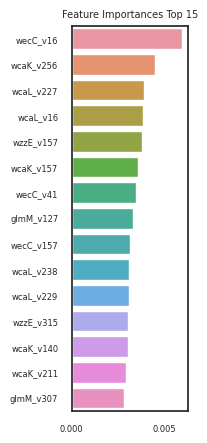

In [1668]:
plt.figure(figsize=(1.5,5))
plt.title('Feature Importances Top 15', fontsize=7)
#sns.barplot(x=top15, y=top15.index)
sns.barplot(x=top15, y=[ClusterMeta[a.split("_")[0].strip("MBGD")]["gene"]+"_"+a.split("_")[-1] for a in list(top15.index)])
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.show()

In [1259]:
major_O_list = list(dict(meta["O"].value_counts()).keys())[:5]
sf_cfm = metrics.confusion_matrix(list(y_test), list(RF_estimator.predict(x_test)), labels=major_O_list)

In [1260]:
O_count_sums = np.array([dict(y_test.value_counts())[Otype] for Otype in major_O_list])
sf_cfm_rt = sf_cfm / O_count_sums[:, np.newaxis]

In [1636]:
Y_predict = cross_val_predict(RF_estimator, X, Y, cv=StratifiedKFold(n_splits = 10))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


In [1597]:
minor_O_list = list(dict(meta["O"].value_counts()).keys())[120:125]
minor_O_list

['O14', 'O81', 'O35', 'O68', 'O158']

In [1637]:
Y

0       O103
1        O26
2        O26
3        O45
4        O88
        ... 
9533    O111
9534    O111
9535      O9
9536      O9
9537    O111
Name: answer, Length: 9524, dtype: object

In [1638]:
Y_predict

array(['O8', 'O157', 'O16', ..., 'O9', 'O9', 'O111'], dtype=object)

In [1639]:
cf_major = confusion_matrix(Y, Y_predict, labels=major_O_list)
cf_minor = confusion_matrix(Y, Y_predict, labels=minor_O_list)

In [1605]:
major_O_count_sums = np.array([dict(Y.value_counts())[Otype] for Otype in major_O_list])
minor_O_count_sums = np.array([dict(Y.value_counts())[Otype] for Otype in minor_O_list])
major_O_count_sums
#minor_O_count_sums

array([2616,  927,  430,  276,  217])

In [1606]:
major_O_count_sums[4] += 1

In [1513]:
cf
cf / major_O_count_sums[:, np.newaxis]

array([[0.97038462, 0.        , 0.        , 0.00230769, 0.        ],
       [0.        , 0.98596112, 0.        , 0.00107991, 0.        ],
       [0.002331  , 0.002331  , 0.96270396, 0.002331  , 0.        ],
       [0.        , 0.        , 0.0042735 , 0.90598291, 0.        ],
       [0.01382488, 0.        , 0.00460829, 0.        , 0.97695853]])

In [1640]:
cf_major

array([[2559,    0,    0,    8,    0],
       [   1,  915,    0,    3,    0],
       [   1,    1,  415,    2,    0],
       [   1,    0,    1,  214,    0],
       [   3,    0,    1,    0,  211]])

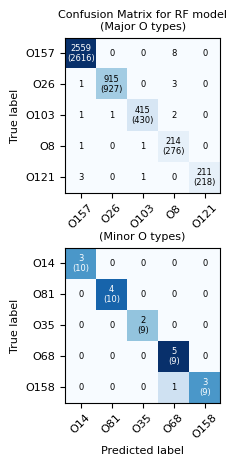

In [1608]:
# 혼동 행렬을 시각화하는 함수
def plot_confusion_matrix(ax, cm, labels, sum_value, title, ylabel, xlabel):
    #plt.figure(figsize=(6, 4))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=8)
    #plt.colorbar(cax, ax=ax)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels, fontsize=8)

    # 텍스트 표시
    fmt = ""#'.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, format(cm[i, j] if i!=j else str(cm[i, j])+"\n("+str(sum_value[i])+")", fmt),
                 ha="center", va="center", fontsize=6,
                 color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8)
    #plt.tight_layout()

# 레이블 예시
labels = ['Class 1', 'Class 2', 'Class 3']

# 혼동 행렬 플롯
fig, ax = plt.subplots(2, 1, figsize=(2, 5))
#plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for SerotypeFinder\nMajor O types")
#plot_confusion_matrix(ax[0], cf_major / major_O_count_sums[:, np.newaxis], major_O_list, "Recall for RF model\n(Major O types)", "True label", "")
plot_confusion_matrix(ax[0], cf_major, major_O_list, major_O_count_sums, "Confusion Matrix for RF model\n(Major O types)", "True label", "")
#plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "Recall for SerotypeFinder\nMinor O types")
#plot_confusion_matrix(ax[1], cf_minor / minor_O_count_sums[:, np.newaxis], minor_O_list, "(Minor O types)", "Tru e label", "Predicted label")
plot_confusion_matrix(ax[1], cf_minor, minor_O_list, minor_O_count_sums, "(Minor O types)", "True label", "Predicted label")
plt.show()

In [1412]:
major_O_count_sums

array([2616,  927,  430,  276,  218])

In [1413]:
X

,MBGD7478_CDHIT4_v0,MBGD7478_CDHIT4_v1,MBGD7478_CDHIT4_v2,MBGD7478_CDHIT4_v3,MBGD7478_CDHIT4_v4,MBGD7478_CDHIT4_v5,MBGD7478_CDHIT4_v6,MBGD7478_CDHIT4_v7,MBGD7478_CDHIT4_v8,MBGD7478_CDHIT4_v9,...,MBGD7478_CDHIT4_v310,MBGD7478_CDHIT4_v311,MBGD7478_CDHIT4_v312,MBGD7478_CDHIT4_v313,MBGD7478_CDHIT4_v314,MBGD7478_CDHIT4_v315,MBGD7478_CDHIT4_v316,MBGD7478_CDHIT4_v317,MBGD7478_CDHIT4_v318,MBGD7478_CDHIT4_v319
0,-0.054938,-0.066423,0.134155,0.104874,0.141057,-0.042934,0.042958,-0.109155,-0.077574,-0.085075,...,-0.076960,-0.002971,-0.001243,0.081685,0.043393,-0.110099,-0.111353,0.167942,-0.018575,0.012998
1,-0.051605,-0.061521,0.133450,0.099566,0.134597,-0.051922,0.041862,-0.109355,-0.081014,-0.080676,...,-0.078316,-0.002525,0.001287,0.083899,0.041645,-0.104942,-0.109295,0.162048,-0.013404,0.016024
2,-0.060090,-0.030710,0.129960,0.093640,0.128333,-0.035399,0.048198,-0.109688,-0.075913,-0.063646,...,-0.092173,0.012142,0.007563,0.075460,0.039364,-0.134151,-0.116764,0.162363,-0.024718,0.016775
3,-0.058006,-0.058403,0.133069,0.105040,0.130119,-0.056216,0.048929,-0.112252,-0.078533,-0.077292,...,-0.058781,0.003540,0.008866,0.070731,0.049228,-0.101754,-0.116471,0.148062,-0.003507,0.025468
4,-0.066083,-0.049577,0.137606,0.101910,0.118856,-0.047961,0.049378,-0.121013,-0.079805,-0.087807,...,-0.073768,0.023898,-0.013686,0.050946,0.051825,-0.144559,-0.118048,0.152024,-0.001682,0.017759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9533,-0.019440,-0.020770,0.103474,0.116140,0.226792,0.021354,0.095036,-0.104908,-0.042876,-0.082239,...,-0.029148,0.056047,-0.005588,0.104650,0.082309,-0.182189,-0.082546,0.117712,-0.004971,0.024992
9534,-0.017809,-0.021245,0.103905,0.114743,0.226301,0.021804,0.092903,-0.104111,-0.046637,-0.082292,...,-0.028349,0.055013,-0.004799,0.104325,0.082151,-0.181951,-0.081563,0.117839,-0.003485,0.023894
9535,-0.032099,-0.060866,0.039995,0.070381,0.206920,0.070042,0.142473,-0.120813,-0.033717,-0.062810,...,-0.034333,0.032849,-0.045194,0.079314,0.102952,-0.223324,-0.070774,0.105064,0.011606,-0.007375
9536,-0.054565,-0.076855,0.052226,0.054215,0.164769,0.058423,0.113068,-0.089814,-0.029721,-0.078112,...,-0.028092,0.039458,-0.010376,0.077553,0.074043,-0.218167,-0.082194,0.118305,0.018400,-0.019910


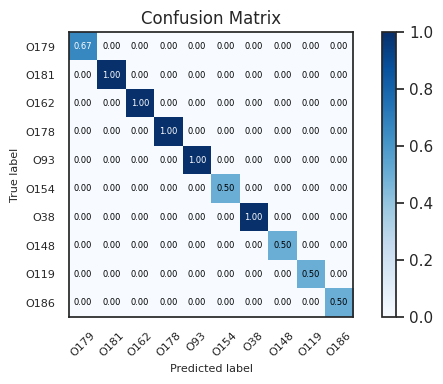

In [1261]:
# 혼동 행렬을 시각화하는 함수
def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, fontsize=8)
    plt.yticks(tick_marks, labels, fontsize=8)

    # 텍스트 표시
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", fontsize=6,
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=8)
    plt.xlabel('Predicted label', fontsize=8)
    plt.tight_layout()

# 레이블 예시
labels = ['Class 1', 'Class 2', 'Class 3']

# 혼동 행렬 플롯
plot_confusion_matrix(sf_cfm_rt, major_O_list)
plt.show()

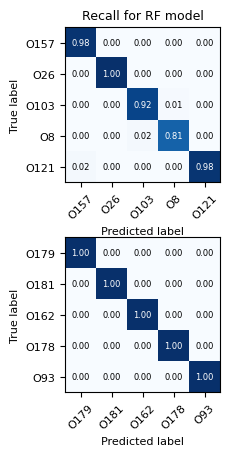

In [1393]:
major_O_list = list(dict(meta["O"].value_counts()).keys())[0:5]
#major_O_list.remove("O111")
middle_O_list = list(dict(meta["O"].value_counts()).keys())[100:105]
major_cm = metrics.confusion_matrix(list(y_test), list(RF_estimator.predict(x_test)), labels=major_O_list)
middle_cm = metrics.confusion_matrix(list(y_test), list(RF_estimator.predict(x_test)), labels=middle_O_list)

major_O_count_sums = np.array([dict(y_test.value_counts())[Otype] for Otype in major_O_list])
middle_O_count_sums = np.array([dict(y_test.value_counts())[Otype] for Otype in middle_O_list])
major_cm_rt = major_cm / major_O_count_sums[:, np.newaxis]
middle_cm_rt = middle_cm / middle_O_count_sums[:, np.newaxis]

# 혼동 행렬을 시각화하는 함수
def plot_confusion_matrix(ax, cm, labels, title):
    #plt.figure(figsize=(6, 4))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=9)
    #plt.colorbar(cax, ax=ax)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels, fontsize=8)

    # 텍스트 표시
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", fontsize=6,
                 color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel('True label', fontsize=8)
    ax.set_xlabel('Predicted label', fontsize=8)
    #plt.tight_layout()

# 레이블 예시
labels = ['Class 1', 'Class 2', 'Class 3']

# 혼동 행렬 플롯
fig, ax = plt.subplots(2, 1, figsize=(2, 5))
#plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for RF model\nMajor O types")
plot_confusion_matrix(ax[0], major_cm_rt, major_O_list, "Recall for RF model")
#plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "Recall for RF model\nMinor O types")
plot_confusion_matrix(ax[1], middle_cm_rt, middle_O_list, "")
plt.show()

### 13. Test for 9-gene GNB, SVC, MLP, RF, AdaBoost, XGB model

In [1579]:
#nFold = 10
#target_O_list = [label for label, count in dict(DataMat["answer"].value_counts()).items() if count >= nFold]
target_O_list = [label for label, count in dict(DataMat_allgene_1911["answer"].value_counts()).items() if count >= 2]
#DataMat_test = DataMat[DataMat["answer"].isin(target_O_list)]
DataMat_test = DataMat_allgene_1911[DataMat_allgene_1911["answer"].isin(target_O_list)]

In [1581]:
len(target_O_list)

174

In [1582]:
Y = DataMat_test["answer"]
X = DataMat_test.drop(["answer", "acc"], axis=1)
#Y = DataMat_allgene_1911["answer"]
#X = DataMat_allgene_1911.drop(["answer", "acc"], axis=1)

#x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
RF_estimator = RandomForestClassifier(n_estimators=100, random_state=33, n_jobs=40, criterion="entropy", max_depth=10, class_weight="balanced")
GNB_estimator = GaussianNB()
SVC_estimator = svm.SVC(kernel="linear", class_weight="balanced")
MLP_estimator = MLPClassifier(solver='adam', random_state=0, hidden_layer_sizes=[500])
KNN_estimator = KNeighborsClassifier(n_jobs=40)
#ADB_estimator = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=50, random_state=33, class_weight="balanced"),
#                                   n_estimators=100, random_state=33,)
XGB_estimator = xgb.XGBClassifier(n_jobs=40, max_depth=10, eta=0.1)

models_metric = {}
for model, estimator in {"RF": RF_estimator, "XGB": XGB_estimator, "GNB": GNB_estimator, "MLP": MLP_estimator, "SVC": SVC_estimator, "KNN": KNN_estimator
                         }.items():
                        #"ADB": ADB_estimator,
    #scoring_auroc = make_scorer(roc_auc_score, multi_class='ovo')#,needs_proba=True)
    #scores_auroc = cross_validate(estimator, X, Y, cv=StratifiedKFold(n_splits = nFold), scoring=scoring_auroc)

    metrics = {
        "f1" : [],
        "recall" : [],
        "prc": [],
        "acc": [],
        #"auroc": scores_auroc
    }
    
    le = LabelEncoder()    
    Y_trans = le.fit_transform(Y) if model == "XGB" else Y
    
    #for train_idx, test_idx in StratifiedKFold(n_splits = nFold).split(X, Y_trans):
    for train_idx, test_idx in StratifiedShuffleSplit(n_splits = nFold).split(X, Y_trans):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        if model == "XGB": y_train, y_test = Y_trans[train_idx], Y_trans[test_idx]
        else: y_train, y_test = Y_trans.iloc[train_idx], Y_trans.iloc[test_idx]        

        clf = estimator.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        metrics["f1"].append(f1_score(y_test, y_pred, average="weighted"))
        metrics["recall"].append(recall_score(y_test, y_pred, average="weighted"))
        metrics["prc"].append(precision_score(y_test, y_pred, average="weighted"))
        metrics["acc"].append(accuracy_score(y_test, y_pred))
    
    models_metric[model] = metrics

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is i

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is i

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is i

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is i

In [1583]:
models_metric

{'RF': {'f1': [0.901093282409023,
   0.9012832243786483,
   0.8831848273849918,
   0.9042082045464852,
   0.8959820291066428,
   0.9064277827992161,
   0.903171657762761,
   0.8910619312681243,
   0.8931466003974694,
   0.9034724020510908],
  'recall': [0.9055613850996852,
   0.9087093389296957,
   0.8908709338929696,
   0.906610703043022,
   0.9003147953830011,
   0.9087093389296957,
   0.9087093389296957,
   0.8971668415529905,
   0.8971668415529905,
   0.912906610703043],
  'prc': [0.9063628468409838,
   0.9058270585486639,
   0.8899743262741688,
   0.9123287446159104,
   0.9028493737622727,
   0.9166930878623752,
   0.9063732119780178,
   0.8949802863010381,
   0.9012130878598839,
   0.9068882804992228],
  'acc': [0.9055613850996852,
   0.9087093389296957,
   0.8908709338929696,
   0.906610703043022,
   0.9003147953830011,
   0.9087093389296957,
   0.9087093389296957,
   0.8971668415529905,
   0.8971668415529905,
   0.912906610703043]},
 'XGB': {'f1': [0.894855018518003,
   0.87925

In [1708]:
#np.mean(models_metric["SVC"]["acc"])
#np.std(models_metric["SVC"]["acc"])

0.013108077060189191

In [1575]:
models_metric_save = models_metric

In [1576]:
with open('models_metric_previous1911.json', 'w') as json_file:
    json.dump(models_metric_save, json_file)

In [1709]:
sf_report

,precision,recall,f1-score,support
O1,0.930233,0.842105,0.883978,95.000000
O10,1.000000,0.857143,0.923077,7.000000
O100,0.750000,0.642857,0.692308,14.000000
O100/O154,0.000000,0.000000,0.000000,0.000000
O101,0.304348,0.608696,0.405797,23.000000
...,...,...,...,...
O9a/O101,0.000000,0.000000,0.000000,0.000000
nan,0.000000,0.000000,0.000000,0.000000
accuracy,0.822204,0.822204,0.822204,0.822204
macro avg,0.575055,0.487125,0.512586,9539.000000


In [941]:
ec_report

,precision,recall,f1-score,support
-,0.000000,0.000000,0.000000,0.000000
O1,0.957143,0.728261,0.827160,92.000000
O10,0.666667,0.857143,0.750000,7.000000
O100,0.714286,0.714286,0.714286,14.000000
O100/O154,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
O99,1.000000,0.961538,0.980392,26.000000
nan,0.000000,0.000000,0.000000,282.000000
accuracy,0.797587,0.797587,0.797587,0.797587
macro avg,0.600476,0.513229,0.536351,9530.000000


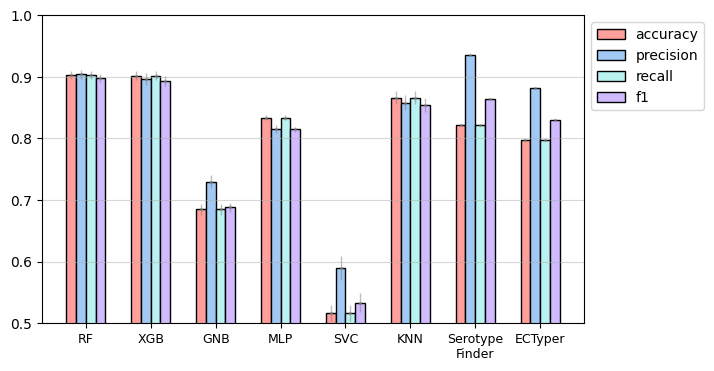

In [1585]:
models = list(models_metric.keys())

plt.style.use('default')
fig = plt.figure(figsize=(7,4))

N = len(models_metric) + 2
ind = np.arange(N)  
#width = 0.25
width = 0.15
hex_code = sns.color_palette("pastel6").as_hex()
  
#acc_vals_mean = [np.mean(models_metric[model]["acc"]) for model in models] 
acc_vals_mean = [np.mean(models_metric[model]["acc"]) for model in models] + [sf_report.loc["accuracy"]["precision"], ec_report.loc["accuracy"]["precision"]]
acc_vals_std = [np.std(models_metric[model]["acc"]) for model in models] + [0, 0]
bar1 = plt.bar(ind-1.5*width, acc_vals_mean, width, color = hex_code[2], edgecolor="black") 
bar1_err = plt.errorbar(ind-1.5*width, acc_vals_mean, acc_vals_std, color = "grey", alpha=0.5, fmt="o", markersize=1.5, elinewidth=1) 
#bar1 = plt.errorbar(ind-width, acc_vals, width = width, color = hex_code[5]) 

prc_vals_mean = [np.mean(models_metric[model]["prc"]) for model in models] + [sf_report.loc["weighted avg"]["precision"], ec_report.loc["weighted avg"]["precision"]]
prc_vals_std = [np.std(models_metric[model]["prc"]) for model in models] + [0, 0]
bar2 = plt.bar(ind-0.5*width, prc_vals_mean, width, color=hex_code[0], edgecolor="black") 
bar2_err = plt.errorbar(ind-0.5*width, prc_vals_mean, prc_vals_std, color = "grey", alpha=0.5, fmt="o", markersize=1.5, elinewidth=1) 

rec_vals_mean = [np.mean(models_metric[model]["recall"]) for model in models] + [sf_report.loc["weighted avg"]["recall"], ec_report.loc["weighted avg"]["recall"]]
rec_vals_std = [np.std(models_metric[model]["recall"]) for model in models] + [0, 0]
bar3 = plt.bar(ind+0.5*width, rec_vals_mean, width, color=hex_code[5], edgecolor="black") 
bar3_err = plt.errorbar(ind+0.5*width, rec_vals_mean, rec_vals_std, color = "grey", alpha=0.5, fmt="o", markersize=1.5, elinewidth=1) 

f1_vals_mean = [np.mean(models_metric[model]["f1"]) for model in models] + [sf_report.loc["weighted avg"]["f1-score"], ec_report.loc["weighted avg"]["f1-score"]]
f1_vals_std = [np.std(models_metric[model]["f1"]) for model in models] + [0, 0]
bar4 = plt.bar(ind+1.5*width, f1_vals_mean, width, color = hex_code[3], edgecolor="black") 
bar4_err = plt.errorbar(ind+1.5*width, f1_vals_mean, f1_vals_std, color = "grey", alpha=0.5, fmt="o", markersize=1.5, elinewidth=1) 

#plt.xlabel("Models") 
plt.ylim((0.5, 1)) 
#plt.ylabel('') 
plt.title("") 

plt.xticks(ind, models + ["Serotype\nFinder", "ECTyper"], fontsize=9, rotation=0) 
plt.legend( (bar1, bar2, bar3, bar4), ('accuracy', 'precision', "recall", 'f1'), loc='upper left', bbox_to_anchor=(1,1))
plt.grid(axis="y", alpha=0.5)
plt.style.use('default')
#plt.tight_layout()
plt.show() 

In [ ]:
Y = DataMat_test["answer"]
X = DataMat_test.drop(["answer", "acc"], axis=1)

rfecv = RFECV(estimator=RF_estimator, step=1, cv=StratifiedKFold(n_splits = nFold), scoring='accuracy')   #5-fold cross-validation
rfecv = rfecv.fit(X, Y)

#여기

In [1440]:
rfecv

RFECV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
      estimator=RandomForestClassifier(class_weight='balanced',
                                       criterion='entropy', max_depth=10,
                                       n_jobs=40, random_state=1724305988),
      scoring='accuracy')

In [1460]:
combined = dict(zip(list(X.columns[rfecv.get_support()]), list(rfecv.estimator_.feature_importances_)))
sorted_combined = sorted(combined.items(), key=lambda x: x[1], reverse=True)

In [1461]:
sorted_combined

[('MBGD201_CDHIT1_v16', 0.011643536556065521),
 ('MBGD2726_CDHIT0_v238', 0.007191356194956404),
 ('MBGD2726_CDHIT0_v157', 0.006488054943571021),
 ('MBGD201_CDHIT1_v41', 0.006314264280939961),
 ('MBGD2726_CDHIT0_v41', 0.006290782604839288),
 ('MBGD19_CDHIT11_v16', 0.006230003566096853),
 ('MBGD7478_CDHIT4_v157', 0.006016111410164334),
 ('MBGD35854_CDHIT1_v157', 0.005944587064648375),
 ('MBGD35854_CDHIT1_v16', 0.005665139584672372),
 ('MBGD201_CDHIT1_v208', 0.005582745821141764),
 ('MBGD201_CDHIT1_v94', 0.005490742232850829),
 ('MBGD2726_CDHIT0_v16', 0.005472713461765077),
 ('MBGD66_CDHIT0_v299', 0.005292012854607706),
 ('MBGD19_CDHIT11_v238', 0.005143984500637598),
 ('MBGD201_CDHIT1_v157', 0.005052042958968894),
 ('MBGD19_CDHIT11_v297', 0.004970650201856619),
 ('MBGD117_CDHIT3_v133', 0.004878579227273026),
 ('MBGD201_CDHIT1_v215', 0.004783813651816938),
 ('MBGD117_CDHIT3_v127', 0.004726091145459028),
 ('MBGD117_CDHIT3_v206', 0.00465773437545564),
 ('MBGD201_CDHIT1_v76', 0.00456253837589

In [1462]:
sorted_combined[:15]

[('MBGD201_CDHIT1_v16', 0.011643536556065521),
 ('MBGD2726_CDHIT0_v238', 0.007191356194956404),
 ('MBGD2726_CDHIT0_v157', 0.006488054943571021),
 ('MBGD201_CDHIT1_v41', 0.006314264280939961),
 ('MBGD2726_CDHIT0_v41', 0.006290782604839288),
 ('MBGD19_CDHIT11_v16', 0.006230003566096853),
 ('MBGD7478_CDHIT4_v157', 0.006016111410164334),
 ('MBGD35854_CDHIT1_v157', 0.005944587064648375),
 ('MBGD35854_CDHIT1_v16', 0.005665139584672372),
 ('MBGD201_CDHIT1_v208', 0.005582745821141764),
 ('MBGD201_CDHIT1_v94', 0.005490742232850829),
 ('MBGD2726_CDHIT0_v16', 0.005472713461765077),
 ('MBGD66_CDHIT0_v299', 0.005292012854607706),
 ('MBGD19_CDHIT11_v238', 0.005143984500637598),
 ('MBGD201_CDHIT1_v157', 0.005052042958968894)]

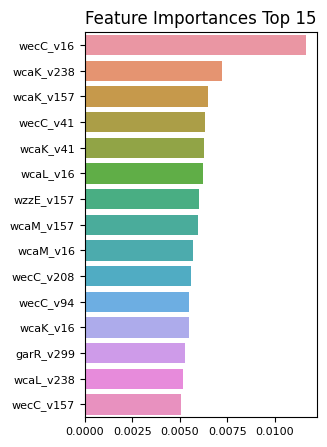

In [1466]:
plt.figure(figsize=(3,5))
plt.title('Feature Importances Top 15')
#sns.barplot(x=top15, y=top15.index)
#sns.barplot(x=top15, y=[ClusterMeta[a.split("_")[0].strip("MBGD")]["gene"]+"_"+a.split("_")[-1] for a in list(top15.index)])
sns.barplot(x=[comp[1] for comp in sorted_combined[:15]],
            y=[ClusterMeta[comp[0].split("_")[0].strip("MBGD")]["gene"]+"_"+comp[0].split("_")[-1]
               for comp in sorted_combined[:15]])
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

In [56]:
start_time = time.time()
importances = RF_estimator.feature_importances_
std = np.std([tree.feature_importances_ for tree in RF_estimator.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### 10. Re-map the genes to 19-gene DB

In [26]:
fl = glob.glob("2-1.split/overall_reduced_DB2/*.tab")
target_acc = {}

for af in fl:
    with open(af, "r") as infile:
        file_name = af.split("/")[-1].replace(".tab", "")
        
        for line in infile:
            seqnum, gene, pident, length = line.strip("\n").split("\t")[0:4]
            _sp, _gene = gene.split(":")
            if _sp in Gene2Cluster:
                if _gene in Gene2Cluster[_sp]:
                    clstr_cand = Gene2Cluster[_sp][_gene]
                    for clstr in clstr_cand:
                        if int(clstr) in target_clstr:
                            target_acc.setdefault("{}|{}".format(file_name, seqnum), [])
                            target_acc["{}|{}".format(file_name, seqnum)].append(clstr)

In [27]:
table = {}

for sample in [af.split("/")[-1].replace(".tab", "") for af in glob.glob("2-1.split/overall_reduced_DB/*.tab")]:
    for clstr in target_clstr:
        table.setdefault(sample, {})
        table[sample].setdefault(clstr, [])

for k, v in target_acc.items():
    sample = k.split("|")[0]
    if sample in table:
        for clstr in v:
            if int(clstr) in table[sample]:
                table[sample][int(clstr)].append(k)

In [28]:
table_v2 = {}

with open("5-1.ESM/GMS2.faa.txt", "r") as infile:
    for line in infile:
        if line.startswith(">"):
            acc = line.strip("\n").strip(">")
            if acc in target_acc:
                read = True
            else:
                read = False
                
        elif read:
            vecs = [float(vec) for vec in line.strip("\n").split(" ")]
            table_v2[acc] = vecs           

Make Dataframe for Learning

In [29]:
DataMat_train = {"{}_v{}".format(j, i):[] for i in range(320) for j in target_clstr}
DataMat_train["acc"] = []
DataMat_train["entero_acc"] = []
DataMat_train["answer"] = []

for _sp in table:
    try:
        DataMat_train["answer"].append(meta[meta["acc"] == _sp.split(".")[0].split("_genomic")[0]]["O"].item())
    except ValueError: # 
        continue
    DataMat_train["acc"].append(_sp)
    DataMat_train["entero_acc"].append(_sp.split(".")[0].split("_genomic")[0])
    
    for clstr in target_clstr:
    #for clstr in [117, 201]:
        vecs = [-1.0]*320
        if clstr in table[_sp]:
            accs = table[_sp][clstr]
            accs_vec = [np.array(table_v2[acc]) for acc in accs if acc in table_v2]
            if len(accs_vec) == 0:
                vecs = np.array([-1.0]*320)
            else:
                vecs = np.mean(accs_vec, axis = 0)            
        
        for i in range(320):
            DataMat_train["{}_v{}".format(clstr, i)].append(vecs[i])

DataMat_train = pd.DataFrame(DataMat_train)

In [30]:
#DataMat = DataMat_train[["{}_v{}".format(j, i) for i in range(320) for j in [7478]] + ["acc", "entero_acc", "answer"]]
#DataMat = DataMat_train[DataMat_train["answer"].isin(major_O_list)]
DataMat = DataMat_train

In [31]:
DataMat

,641_v0,35854_v0,16_v0,19_v0,35_v0,2726_v0,684_v0,1838_v0,5807_v0,946_v0,...,709_v319,1355_v319,3039_v319,2656_v319,103_v319,117_v319,5503_v319,acc,entero_acc,answer
0,-0.135782,-0.090709,-0.103040,-0.089163,-0.063095,-0.086706,-0.039358,-0.149827,-1.0,-0.010608,...,-0.145045,-1.000000,-1.000000,-0.122343,-0.010573,-0.050315,-1.0,ESC_RB8374AA_AS.result,ESC_RB8374AA_AS,O157
1,-0.124685,-0.085331,-0.105417,-0.099698,-0.054258,-0.090749,-0.039583,-0.156035,-1.0,-0.023223,...,0.010906,-1.000000,-1.000000,-0.117492,-0.003188,-0.064546,-1.0,ESC_LB5116AA_AS.result,ESC_LB5116AA_AS,O8
2,-0.135782,-0.090709,-0.106160,-0.089344,-0.063563,-0.087238,-0.039358,-0.149827,-1.0,-0.010608,...,-0.145045,-1.000000,-1.000000,-0.122343,-0.011842,-0.050315,-1.0,ESC_LB2408AA_AS_genomic,ESC_LB2408AA_AS,O157
3,-0.141779,-0.088926,-0.102908,-0.085588,-0.056755,-0.088844,-0.040349,-0.155545,-1.0,-0.013995,...,-0.064569,-0.124819,-1.000000,-0.012273,0.010629,-0.063459,-1.0,ESC_LB8485AA_AS.result,ESC_LB8485AA_AS,O120
4,-0.135244,-0.092205,-0.102969,-0.088587,-0.062772,-0.086706,-0.039358,-0.149411,-1.0,-0.010608,...,-0.145045,-1.000000,-1.000000,-0.120698,-0.017422,-0.050315,-1.0,ESC_LA5511AA_AS.scaffold,ESC_LA5511AA_AS,O157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9534,-0.137959,-0.087042,-0.106291,-0.092925,-0.055101,-0.085787,-0.035016,-0.099433,-1.0,0.019826,...,-0.074014,-0.060022,0.034206,-0.035087,-0.009482,-0.058866,-1.0,ESC_BA6974AA_AS.scaffold,ESC_BA6974AA_AS,O104
9535,-0.137606,-0.035844,-0.101686,-0.092043,-0.059079,-0.088362,-0.041593,-0.156349,-1.0,0.011084,...,-0.068700,-1.000000,0.083594,-0.119553,-0.002485,-0.063260,-1.0,ESC_WB0828AA_AS.result,ESC_WB0828AA_AS,O153
9536,-0.135782,-0.090709,-0.103027,-0.089163,-0.063095,-0.086706,-0.039358,-0.149827,-1.0,-0.010608,...,-0.145045,-1.000000,-1.000000,-0.122343,-0.017942,-0.050315,-1.0,ESC_OB7424AA_AS.result,ESC_OB7424AA_AS,O157
9537,-0.135782,-0.090709,-0.103051,-0.089163,-0.063095,-0.086706,-0.039358,-0.149827,-1.0,-0.010608,...,-0.145045,-1.000000,-1.000000,-0.122343,-0.010573,-0.050315,-1.0,ESC_HA4910AA_AS.scaffold,ESC_HA4910AA_AS,O157


In [32]:
DataMat["3039_v319"].value_counts()#[-1.0]

-1.000000    8212
 0.034206      80
 0.104968      77
 0.078020      59
 0.083945      53
             ... 
 0.119855       1
 0.042970       1
 0.133656       1
 0.159037       1
 0.126536       1
Name: 3039_v319, Length: 250, dtype: int64

### 11. Test for GNB, SVC, MLP, RF, AdaBoost, XGB model

In [ ]:
nFold = 3
target_O_list = [label for label, count in dict(DataMat["answer"].value_counts()).items() if count >= nFold]
DataMat_test = DataMat[DataMat["answer"].isin(target_O_list)]

Y = DataMat_test["answer"]
X = DataMat_test.drop(["answer", "acc", "entero_acc"], axis=1)

#estimator = svm.SVC(kernel="linear", class_weight="balanced")
#estimator = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=50, random_state=33, class_weight="balanced"),
#                                   n_estimators=100, random_state=33,)
#estimator = KNeighborsClassifier(n_jobs=40)
#estimator = LogisticRegression(multi_class="ovr", solver="lbfgs", class_weight="balanced", n_jobs=40)
for train_idx, test_idx in StratifiedKFold(n_splits = nFold).split(X, Y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    clf = estimator.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

In [ ]:
nFold = 10
target_O_list = [label for label, count in dict(DataMat["answer"].value_counts()).items() if count >= nFold]
DataMat_test = DataMat[DataMat["answer"].isin(target_O_list)]

Y = DataMat_test["answer"]
X = DataMat_test.drop(["answer", "acc", "entero_acc"], axis=1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
RF_estimator = RandomForestClassifier(n_estimators=100, random_state=33, n_jobs=40, criterion="entropy", max_depth=10, class_weight="balanced")
GNB_estimator = GaussianNB()
SVC_estimator = svm.SVC(kernel="linear", class_weight="balanced")
MLP_estimator = MLPClassifier(solver='adam', random_state=0, hidden_layer_sizes=[500])
KNN_estimator = KNeighborsClassifier(n_jobs=40)
#ADB_estimator = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=50, random_state=33, class_weight="balanced"),
#                                   n_estimators=100, random_state=33,)
XGB_estimator = xgb.XGBClassifier(n_jobs=40, max_depth=10, eta=0.1)

models_metric = {}
for model, estimator in {"RF": RF_estimator, "XGB": XGB_estimator, #"GNB": GNB_estimator, "MLP": MLP_estimator, "SVC": SVC_estimator, "KNN": KNN_estimator
                         }.items():
                        #"ADB": ADB_estimator,
    #scoring_auroc = make_scorer(roc_auc_score, multi_class='ovo')#,needs_proba=True)
    #scores_auroc = cross_validate(estimator, X, Y, cv=StratifiedKFold(n_splits = nFold), scoring=scoring_auroc)

    metrics = {
        "f1" : [],
        "prc": [],
        "acc": [],
        #"auroc": scores_auroc
    }
    
    le = LabelEncoder()    
    Y_trans = le.fit_transform(Y) if model == "XGB" else Y
    
    for train_idx, test_idx in StratifiedKFold(n_splits = nFold).split(X, Y_trans):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        if model == "XGB": y_train, y_test = Y_trans[train_idx], Y_trans[test_idx]
        else: y_train, y_test = Y_trans.iloc[train_idx], Y_trans.iloc[test_idx]        

        clf = estimator.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        metrics["f1"].append(f1_score(y_test, y_pred, average="weighted"))
        metrics["prc"].append(precision_score(y_test, y_pred, average="weighted"))
        metrics["acc"].append(accuracy_score(y_test, y_pred))
    
    models_metric[model] = metrics

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning

In [39]:
models_metric

{'RF': {'f1': [0.9440906897457183,
   0.935538736088244,
   0.9307026511480799,
   0.934266806987271,
   0.9416313784183078,
   0.9374537369609947,
   0.9427938791764503,
   0.9462971560330558,
   0.9428574601077079,
   0.9311878539965415],
  'prc': [0.9519366068873432,
   0.9413187090906204,
   0.9392891685562865,
   0.9418392825279103,
   0.9450262467469003,
   0.9423216840835332,
   0.9469310801112754,
   0.9528436342252153,
   0.9450397883785225,
   0.9336442804572639],
  'acc': [0.9469122426868906,
   0.9382448537378115,
   0.9317443120260022,
   0.9360780065005417,
   0.9458288190682557,
   0.940347071583514,
   0.9468546637744034,
   0.9490238611713666,
   0.9479392624728851,
   0.9370932754880694]},
 'GNB': {'f1': [0.7311599029559372,
   0.72239160855911,
   0.7480979577585716,
   0.7300547576016202,
   0.7524645884077807,
   0.7712527615619134,
   0.7441605070526754,
   0.7322863172421882,
   0.7418241400051201,
   0.7324149793424869],
  'prc': [0.8334508987689018,
   0.809634

In [44]:
models_metric_save = models_metric

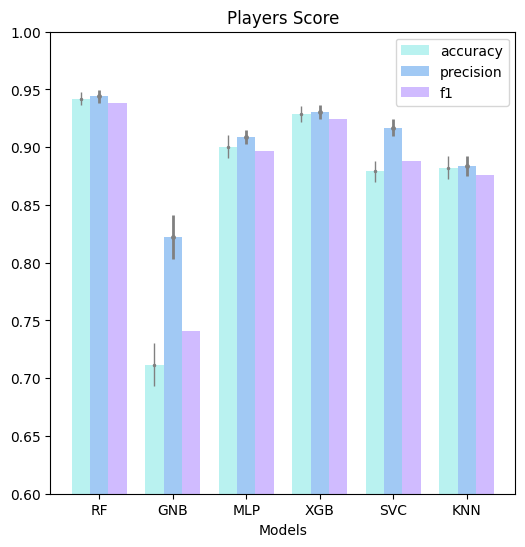

In [38]:
models = list(models_metric.keys())

plt.style.use('default')
fig = plt.figure(figsize=(6,6))

N = len(models_metric)
ind = np.arange(N)  
width = 0.25
hex_code = sns.color_palette("pastel6").as_hex()
  
acc_vals_mean = [np.mean(models_metric[model]["acc"]) for model in models] 
acc_vals_std = [np.std(models_metric[model]["acc"]) for model in models] 
bar1 = plt.bar(ind-width, acc_vals_mean, width, color = hex_code[5]) 
bar1_err = plt.errorbar(ind-width, acc_vals_mean, acc_vals_std, color = "grey", fmt="o", markersize=1.5, elinewidth=1) 
#bar1 = plt.errorbar(ind-width, acc_vals, width = width, color = hex_code[5]) 

prc_vals_mean = [np.mean(models_metric[model]["prc"]) for model in models] 
prc_vals_std = [np.std(models_metric[model]["prc"]) for model in models] 
bar2 = plt.bar(ind, prc_vals_mean, width, color=hex_code[0]) 
bar2_err = plt.errorbar(ind, prc_vals_mean, prc_vals_std, color = "grey", fmt="o", markersize=2.5, elinewidth=2) 
  
f1_vals = [np.mean(models_metric[model]["f1"]) for model in models] 
bar3 = plt.bar(ind+width, f1_vals, width, color = hex_code[3]) 

plt.xlabel("Models") 
plt.ylim((0.6, 1)) 
#plt.ylabel('') 
plt.title("Players Score") 
  
plt.xticks(ind, models) 
plt.legend( (bar1, bar2, bar3), ('accuracy', 'precision', 'f1'))
plt.style.use('default')
plt.show() 

### 12. Test for 19-gene RF model

In [43]:
Y = DataMat_train["answer"]
X = DataMat_train.drop(["answer", "acc", "entero_acc"], axis=1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
RF_estimator = RandomForestClassifier(n_estimators=100, random_state=33, n_jobs=40, criterion="entropy", max_depth=10, class_weight="balanced")

try:
    RF_estimator.fit(x_train, y_train)
except ValueError:
    exit()

y_pred = RF_estimator.predict(x_test)
print("Accuracy : {}".format(accuracy_score(y_test, y_pred)))


Accuracy : 0.9156184486373166


In [33]:
Y.value_counts()[:20].keys()

Index(['O157', 'O26', 'O103', 'O8', 'O121', 'O111', 'O25', 'O149', 'O145',
       'O6', 'O91', 'O45', 'O2', 'O75', 'O55', 'O22', 'O9', 'O165', 'O1',
       'O104'],
      dtype='object')

In [101]:
#major_labels = list(Y.value_counts()[150:].keys())
major_labels = list(Y.value_counts()[:10].keys())
print(metrics.confusion_matrix(y_test, y_pred, labels=major_labels))

In [107]:
#plt.figure(figsize=(20,20))
#plt.plot(ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(y_test, y_pred, labels=major_labels),
#                               display_labels=list(major_labels)))
#ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(y_test, y_pred)).plot()
#ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(y_test, y_pred, labels=major_labels),
#                       display_labels=list(major_labels)).plot().figure_.savefig("confusion_major.png", dpi=200)
fig = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=major_labels, display_labels=list(major_labels)).figure_.savefig("confusion_major.png", dpi=200)
fig.show()

In [109]:
1

### 13. Feature Importance for elucidating key gene for O serotype determination

### 11. Test for 19-gene GNB, SVC, MLP, RF, AdaBoost, XGB model

In [37]:
feature_names = DataMat_train.drop(["answer", "acc", "entero_acc"], axis=1).columns
forest_importances = pd.Series(importances, index=feature_names)
top15 = forest_importances.sort_values(ascending=False)[:40]

top15

117_v132     0.003026
117_v53      0.002926
117_v218     0.002797
117_v286     0.002420
117_v172     0.002356
117_v30      0.002290
117_v163     0.002178
117_v112     0.002101
117_v69      0.002083
117_v20      0.001920
117_v171     0.001868
117_v226     0.001794
117_v240     0.001788
117_v177     0.001764
117_v237     0.001762
117_v105     0.001741
35_v136      0.001717
117_v81      0.001710
117_v307     0.001694
117_v204     0.001682
117_v249     0.001676
117_v264     0.001675
1355_v200    0.001599
117_v21      0.001590
1355_v233    0.001582
117_v189     0.001570
117_v214     0.001558
117_v254     0.001550
1355_v119    0.001540
117_v130     0.001528
1355_v280    0.001526
1355_v282    0.001518
117_v6       0.001514
117_v319     0.001511
117_v80      0.001465
117_v305     0.001444
117_v126     0.001439
1355_v309    0.001437
117_v92      0.001432
117_v88      0.001431
dtype: float64

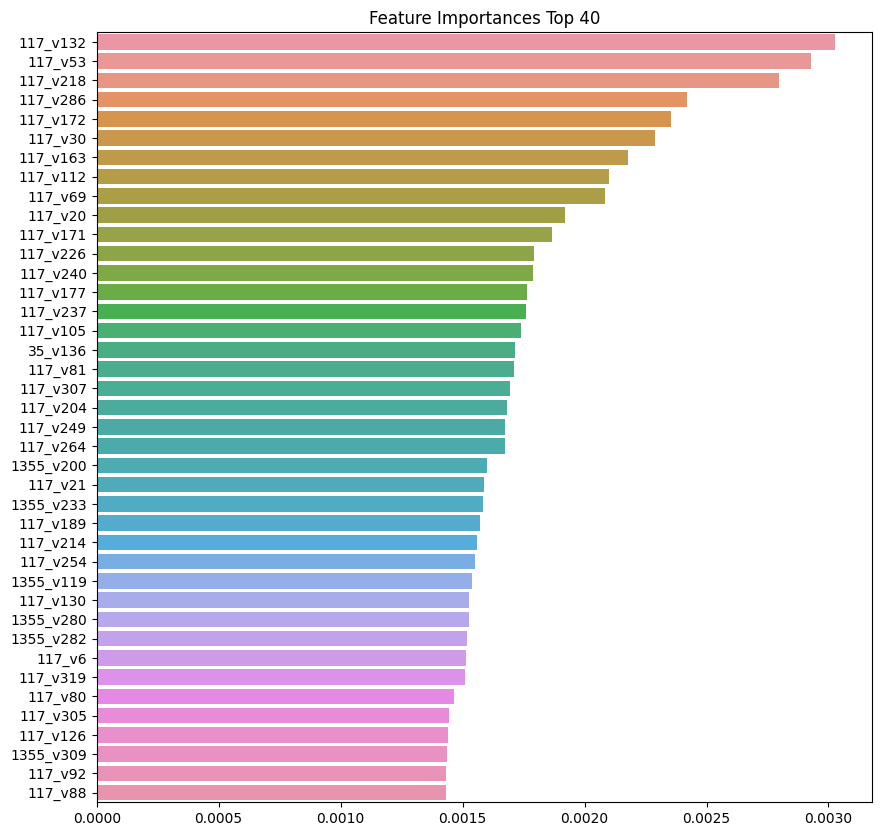

In [45]:
plt.figure(figsize=(10,10))
plt.title('Feature Importances Top 40')
sns.barplot(x=top15, y=top15.index)
plt.show()

#
Check whether genes assigned to same cluster are similar or not

#

In [106]:
table["ESC_RB8374AA_AS.result"][117]

['ESC_RB8374AA_AS.result|241',
 'ESC_RB8374AA_AS.result|242',
 'ESC_RB8374AA_AS.result|252',
 'ESC_RB8374AA_AS.result|259',
 'ESC_RB8374AA_AS.result|260',
 'ESC_RB8374AA_AS.result|861',
 'ESC_RB8374AA_AS.result|1024',
 'ESC_RB8374AA_AS.result|1260',
 'ESC_RB8374AA_AS.result|2058',
 'ESC_RB8374AA_AS.result|3610',
 'ESC_RB8374AA_AS.result|3659',
 'ESC_RB8374AA_AS.result|4832']

In [116]:
Gene2Cluster["ece"]["Z3194"]
Gene2Cluster["rle"]["RL_RS18950"]

{'117': 1, '1046': 1, '1630': 1}

##### BLAST result of 'ESC_RB8374AA_AS.result|241' -> cpsG in E.coli
##### BLAST result of 'ESC_RB8374AA_AS.result|242' -> mannose-1-phosphate guanylyltransferase/mannose-6-phosphate isomerase
##### BLAST result of 'ESC_RB8374AA_AS.result|2058' -> glucose-1-phosphate thymidylyltransferase RfbA in E.coli
##### BLAST result of 'ESC_RB8374AA_AS.result|3610' -> glucose-1-phosphate adenylyltransferase
##### BLAST result of 'ESC_RB8374AA_AS.result|3659' -> tryptophan--tRNA ligase in E.coli
##### BLAST result of 'ESC_RB8374AA_AS.result|4832' -> mannose-6-phosphate isomerase in E.coli

In [169]:
table["ESC_RB8374AA_AS.result"][201]

['ESC_RB8374AA_AS.result|228',
 'ESC_RB8374AA_AS.result|238',
 'ESC_RB8374AA_AS.result|2060',
 'ESC_RB8374AA_AS.result|2061']

##### BLAST result of 'ESC_RB8374AA_AS.result|228' -> SDR family oxidoreductase in E.coli
##### BLAST result of 'ESC_RB8374AA_AS.result|238' -> UDP-glucose 6-dehydrogenase in E.coli
##### BLAST result of 'ESC_RB8374AA_AS.result|2060' -> UDP-N-acetyl-D-mannosamine dehydrogenase in E.coli

#
Check Prevalance of each gene clusters in a genome

#

In [176]:
abundance_genome = {}

for _acc in table:
    for clstr in target_clstr:
        abundance_genome.setdefault(clstr, [])
        abundance_genome[clstr].append(len(table[_acc][clstr]))

In [183]:
for clstr in abundance_genome:
    print(clstr, ClusterMeta[str(clstr)]["gene"], 9561-abundance_genome[clstr].count(0), sep="\t")

641	rfaG	9561
35854	wcaM	9194
16	avtA	9561
19	wcaL	9561
25114	wceF	2621
27808	ospB	3761
35	galE	9561
2726	wcaK	9561
1838	wcaL	9406
5807	wzx	1244
946	rfbC	9561
7478	wzzE	9561
66	garR	9561
709	pglA	9559
201	wecC	9561
1355	rfbD	3816
3039	lgtD	1327
2656	wcaL	9416
20705		3615
103	wcaA	9561
117	glmM	9561
5503	rgpB	1323


#
blast serotypefinder's wzx sequences into MBGD database

#

In [185]:
fl = glob.glob("serotypefinder_db_toMBGD.tab")
serotypefinder_sequences = {}

for af in fl:
    with open(af, "r") as infile:
        file_name = af.split("/")[-1].replace(".tab", "")
        
        for line in infile:
            seqnum, gene, pident, length = line.strip("\n").split("\t")[0:4]
            _sp, _gene = gene.split(":")
            if _sp in Gene2Cluster:
                if _gene in Gene2Cluster[_sp]:
                    clstr_cand = Gene2Cluster[_sp][_gene]
                    for clstr in clstr_cand:
                        if int(clstr) in target_clstr:
                            serotypefinder_sequences.setdefault(seqnum, [])
                            serotypefinder_sequences[seqnum].append(clstr)

In [186]:
serotypefinder_sequences

{'wzx_5_EU694097_O3': ['5807'],
 'wzx_7_AY568960_O4': ['5807'],
 'wzx_18_AB811599_O10': ['5807'],
 'wzx_21_EU296422_O13/O129': ['5807'],
 'wzx_25_GU299793_O18ac': ['5807'],
 'wzx_26_AB811604_O19': ['5807'],
 'wzx_32_GU014554_O25': ['5807'],
 'wzx_43_AB811613_O36': ['5807'],
 'wzx_46_AB811616_O39': ['5807'],
 'wzx_56_AB811623_O49': ['5807'],
 'wzx_94_AB812037_O88': ['5807'],
 'wzx_111_HM485572_O109': ['5807'],
 'wzx_135_EU296424_O129': ['5807'],
 'wzx_139_EU296423_O135': ['5807'],
 'wzx_141_GU068043_O137': ['5807'],
 'wzx_147_AB812061_O142': ['5807'],
 'wzx_151_DQ868766_O147': ['5807'],
 'wzx_181_DQ008593_O177': ['5807'],
 'wzx_191_JN859209_O121': ['5807'],
 'wzx_206_JN887675_O111': ['5807'],
 'wzx_207_AP010960_O111': ['5807'],
 'wzx_224_AB812047_O102': ['5807'],
 'wzx_227_AB972421_O13/O129': ['5807'],
 'wzx_401_F10018-41_O18ab': ['5807']}

#
Check each gene's classification performance based on their vector

#

In [19]:
fl = [af for af in glob.glob("7.Self_test/MBGD_BLAST/*.tab") if "Eco_303" not in af and "FORC_031" not in af]
target_acc = {}
temp = []

for af in fl:
    with open(af, "r") as infile:
        file_name = af.split("/")[-1].replace(".tab", "")
        temp.append(file_name)
        
        for line in infile:
            seqnum, gene, pident, length = line.strip("\n").split("\t")[0:4]
            _sp, _gene = gene.split(":")
            if _sp in Gene2Cluster:
                if _gene in Gene2Cluster[_sp]:
                    clstr_cand = Gene2Cluster[_sp][_gene]
                    for clstr in clstr_cand:
                        if int(clstr) in target_clstr:
                            target_acc.setdefault("{}|{}".format(file_name, seqnum), [])
                            target_acc["{}|{}".format(file_name, seqnum)].append(clstr)

In [20]:
table = {}

for sample in [af.split("/")[-1].replace(".tab", "") for af in fl]:
    for clstr in target_clstr:
        table.setdefault(sample, {})
        table[sample].setdefault(clstr, [])

for k, v in target_acc.items():
    sample = k.split("|")[0]
    if sample in table:
        for clstr in v:
            if int(clstr) in table[sample]:
                table[sample][int(clstr)].append(k)

In [21]:
table_v2 = {}

with open("7.Self_test/GMS2_MFDStest_merged.faa.txt", "r") as infile:
    for line in infile:
        if line.startswith(">"):
            acc = line.strip("\n").strip(">")
            if acc in target_acc:
                read = True
            else:
                read = False
                
        elif read:
            vecs = [float(vec) for vec in line.strip("\n").split(" ")]
            #print(acc, vecs)
            #_sp, _seqnum = acc.split("|")
            table_v2[acc] = vecs           

In [22]:
DataMat_valid = {"{}_v{}".format(j, i):[] for i in range(320) for j in target_clstr}
DataMat_valid["acc"] = []
DataMat_valid["entero_acc"] = []
DataMat_valid["answer"] = []
MFDS_answer_original = {    "FORC_028" : "O26",    "FORC_029" : "O104",    "FORC_032" : "O6",    "FORC_043" : "O104",    "FORC_044" : "O157",
    "FORC_069" : "O104",    "Eco_292" : "O103",    "Eco_302" : "O25",    "Eco_342" : "O26",    "Eco_386" : "O145",
    "Eco_389" : "O103",    "Eco_435" : "O6",    "Eco_459" : "O103",    "Eco_471" : "O26",    "Eco_541" : "O145",    "Eco_551" : "O6"}

MFDS_answer_additional = {    "Eco_019" : "O145",    "Eco_028" : "O145",    "Eco_039" : "O157",    "Eco_038" : "O157",    "Eco_036" : "O26",
    "Eco_021" : "O103",    "Eco_042" : "O103",    "Eco_040" : "O111",    "Eco_041" : "O111",    "Eco_022" : "O6",    "Eco_031" : "O6",
    "Eco_014" : "O25",    "Eco_013" : "O25",    "Eco_037" : "O55",    "Eco_011" : "O104",    "Eco_030" : "O104",    "Eco_004" : "O127",
    "Eco_026" : "O127",    "Eco_001" : "O115",    "Eco_023" : "O115",    "Eco_035" : "O115",    "Eco_007" : "O36",    "Eco_015" : "O36",
    "Eco_009" : "O76",    "Eco_020" : "O76",    "Eco_027" : "O76",    "Eco_003" : "O121",    "Eco_029" : "O121",    "Eco_012" : "O121",
    "Eco_005" : "O168",    "Eco_036" : "O168",    "Eco_043" : "O168",    "Eco_010" : "O88",    "Eco_017" : "O88",    "Eco_018" : "O88",
    "Eco_008" : "O51",    "Eco_033" : "O51",    "Eco_034" : "O51",    "Eco_006" : "O177",    "Eco_025" : "O177",    "Eco_032" : "O177",
    "Eco_002" : "O116",    "Eco_016" : "O116",}

MFDS_answer = copy.deepcopy(MFDS_answer_original)

MFDS_answer.update(MFDS_answer_additional)

In [23]:
for _sp in table:
    DataMat_valid["acc"].append(_sp)
    DataMat_valid["entero_acc"].append("MFDS_test")
    DataMat_valid["answer"].append(MFDS_answer[_sp])
    
    for clstr in target_clstr:
    #for clstr in [117, 201]:
        vecs = [-1.0]*320
        if clstr in table[_sp]:
            accs = table[_sp][clstr]
            accs_vec = [np.array(table_v2[acc]) for acc in accs if acc in table_v2]
            if len(accs_vec) == 0:
                vecs = np.array([-1.0]*320)
            #if acc in table_v2:
            #    vecs = table_v2[acc]
            else:
                vecs = np.mean(accs_vec, axis = 0)            
        
        for i in range(320):
            DataMat_valid["{}_v{}".format(clstr, i)].append(vecs[i])

DataMat_valid = pd.DataFrame(DataMat_valid)

In [24]:
DataMat = DataMat_train
#DataMat = DataMat_train.append(DataMat_valid)
#DataMat = DataMat[["{}_v{}".format(j, i) for i in range(320) for j in [117, 201]] + ["acc", "entero_acc", "answer"]]

NameError: name 'DataMat_train' is not defined

In [344]:
DataMat

,641_v0,35854_v0,16_v0,19_v0,25114_v0,27808_v0,35_v0,2726_v0,1838_v0,5807_v0,...,1355_v319,3039_v319,2656_v319,20705_v319,103_v319,117_v319,5503_v319,acc,entero_acc,answer
0,-0.135782,-0.090709,-0.103284,-0.089163,-1.0,-1.000000,-0.063220,-0.086706,-0.149827,-1.000000,...,-1.000000,-1.000000,-0.122343,-1.000000,-0.010573,-0.050315,-1.000000,ESC_RB8374AA_AS.result,ESC_RB8374AA_AS,O157
1,-0.124685,-0.085331,-0.105531,-0.099698,-1.0,-1.000000,-0.054163,-0.090749,-0.156035,-1.000000,...,-1.000000,-1.000000,-0.117492,-1.000000,-0.003188,-0.064546,-1.000000,ESC_LB5116AA_AS.result,ESC_LB5116AA_AS,O8
2,-0.135782,-0.090709,-0.106347,-0.089344,-1.0,-0.005664,-0.063392,-0.087238,-0.149827,-1.000000,...,-1.000000,-1.000000,-0.122343,-0.025641,-0.011842,-0.050315,-1.000000,ESC_LB2408AA_AS_genomic,ESC_LB2408AA_AS,O157
3,-0.141779,-0.088926,-0.103058,-0.085588,-1.0,-1.000000,-0.056694,-0.088844,-0.155545,-1.000000,...,-0.124819,-1.000000,-0.012273,-1.000000,0.010629,-0.063459,-1.000000,ESC_LB8485AA_AS.result,ESC_LB8485AA_AS,O120
4,-0.135244,-0.092205,-0.103209,-0.088587,-1.0,-0.006142,-0.062891,-0.086706,-0.149411,-1.000000,...,-1.000000,-1.000000,-0.120698,-0.025641,-0.017422,-0.050315,-1.000000,ESC_LA5511AA_AS.scaffold,ESC_LA5511AA_AS,O157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,-0.135833,-0.097115,-0.107872,-0.090219,-1.0,-1.000000,-0.057129,-0.085426,-0.152350,-1.000000,...,-0.119059,-1.000000,-0.121345,-1.000000,-0.003251,-0.043063,0.066807,Eco_027,MFDS_test,O76
50,-0.133800,-0.095705,-0.101813,-0.090265,-1.0,-1.000000,-0.059067,-0.088752,-0.156512,-0.050192,...,-0.162147,-1.000000,-0.115258,-1.000000,0.001687,-0.061646,-1.000000,Eco_029,MFDS_test,O121
51,-0.136135,-0.089877,-0.105356,-0.093840,-1.0,-1.000000,-0.057366,-0.086086,-0.149601,-1.000000,...,-0.058383,0.083594,-0.119789,-1.000000,0.032163,-0.062733,0.075664,Eco_005,MFDS_test,O168
52,-0.135782,-0.090709,-0.103386,-0.088560,-1.0,-1.000000,-0.061861,-0.086706,-0.149827,-1.000000,...,-1.000000,-1.000000,-0.122343,-1.000000,-0.010573,-0.050315,-1.000000,FORC_044,MFDS_test,O157


In [345]:
train_set = DataMat[DataMat["entero_acc"] != "MFDS_test"]
valid_set = DataMat[DataMat.acc.isin(MFDS_answer_original)]

In [346]:
valid_set

,641_v0,35854_v0,16_v0,19_v0,25114_v0,27808_v0,35_v0,2726_v0,1838_v0,5807_v0,...,1355_v319,3039_v319,2656_v319,20705_v319,103_v319,117_v319,5503_v319,acc,entero_acc,answer
11,-0.135104,-0.093467,-0.105821,-0.094546,-1.000000,-1.000000,-0.059012,-0.085963,-0.144212,-1.000000,...,-0.189113,-1.000000,-0.117985,-1.000000,-0.012875,-0.059580,-1.000000,Eco_435,MFDS_test,O6
13,-0.137346,-0.098720,-0.106745,-0.087653,0.056550,-0.064717,-0.064734,-0.085305,-0.152195,-1.000000,...,-0.039342,-1.000000,-0.040094,-0.012617,0.023574,-0.063845,0.136772,Eco_459,MFDS_test,O103
18,-0.138852,-0.095567,-0.104112,-0.087288,0.087919,-0.029259,-0.058172,-0.081977,-0.150667,-1.000000,...,-0.118954,-1.000000,-0.120154,-0.021851,-0.013720,-0.061281,-1.000000,Eco_471,MFDS_test,O26
20,-0.139907,-0.069685,-0.100292,-0.090748,-1.000000,-0.027309,-0.062384,-0.089531,-0.097096,-0.085001,...,-1.000000,-1.000000,-0.080022,-0.031582,-0.021451,-0.061779,-1.000000,Eco_386,MFDS_test,O145
21,-0.139907,-0.069685,-0.089642,-0.089432,-1.000000,-0.027309,-0.042668,-0.130970,-0.115765,-1.000000,...,-0.000764,-0.011104,-0.038191,-0.031582,0.009729,-0.037927,-1.000000,Eco_541,MFDS_test,O145
24,-0.135367,-0.095867,-0.100477,-0.093740,0.079456,-0.036873,-0.060972,-0.090275,-0.152237,-1.000000,...,-1.000000,-1.000000,-0.040051,-1.000000,0.001732,-0.064425,0.135596,Eco_389,MFDS_test,O103
29,-0.137959,-0.087042,-0.101817,-0.092984,-1.000000,-1.000000,-0.055101,-0.085787,-0.099433,-1.000000,...,-1.000000,0.034206,-0.035087,-1.000000,-0.009447,-0.058865,-1.000000,FORC_029,MFDS_test,O104
31,-0.137959,-0.087042,-0.101817,-0.093128,-1.000000,-1.000000,-0.055101,-0.085787,-0.099433,-1.000000,...,-1.000000,0.034206,-0.035087,-1.000000,-0.009447,-0.058866,-1.000000,FORC_069,MFDS_test,O104
33,-0.112004,-0.087835,-0.089941,-0.085761,-1.000000,-0.060727,-0.047120,-0.062391,-0.141008,-1.000000,...,-0.082123,0.066964,-0.161844,-1.000000,0.013451,-0.045805,-1.000000,Eco_551,MFDS_test,O6
35,-0.137345,-0.096017,-0.106239,-0.091051,-0.131376,-0.064717,-0.060328,-0.085305,-0.152195,-0.000429,...,-0.058931,-1.000000,-0.040094,-0.012617,0.029173,-0.063611,0.136871,Eco_292,MFDS_test,O103


In [347]:
Y = train_set["answer"]
X = train_set.drop(["answer", "acc", "entero_acc"], axis=1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
x_valid, y_valid = valid_set.drop(["answer", "acc", "entero_acc"], axis=1), valid_set["answer"]
RF_estimator = RandomForestClassifier(n_estimators=1000, random_state=33, n_jobs=40, criterion="entropy", max_depth=50, class_weight="balanced")

try:    
    RF_estimator.fit(x_train, y_train)
except ValueError:
    exit()

y_pred = RF_estimator.predict(x_test)
print("Accuracy : {}".format(metrics.accuracy_score(y_test, y_pred)))

y_pred = RF_estimator.predict(x_valid)
print("Accuracy : {}".format(metrics.accuracy_score(y_valid, y_pred)))
print(metrics.confusion_matrix(y_valid, y_pred))
#print(metrics.confusion_matrix(y_valid, y_pred, labels=valid_set["answer"].unique()))

Accuracy : 0.9153162571876634
Accuracy : 0.7857142857142857
[[3 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 0]]


In [350]:
print(list(valid_set["answer"]))

['O6', 'O103', 'O26', 'O145', 'O145', 'O103', 'O104', 'O104', 'O6', 'O103', 'O26', 'O104', 'O26', 'O157']


In [349]:
y_pred

array(['O2', 'O103', 'O26', 'O157', 'O145', 'O103', 'O104', 'O104', 'O8',
       'O103', 'O26', 'O104', 'O26', 'O157'], dtype=object)

#
Check each gene's classification performance based on their sequence similarity

#

In [ ]:
for _acc in table:
    record_dict = SeqIO.to_dict(SeqIO.parse("2.GeneMarkS2+/{0}/{0}.faa".format(_acc), "fasta"))

    for clstr in target_clstr:
        with open("7.Self_test/geneDB/{}.faa".format(clstr), "a") as outfile:
            seqs_list = [name.split("|")[1] for name in table[_acc][clstr]]
            for seqnum in seqs_list:
                if len(list(meta[meta["acc"] == _acc.split(".")[0].strip("_genomic")]["O"])) != 1:
                    print(_acc)
                print(">{}|{}|{}".format(_acc, seqnum, list(meta[meta["acc"] == _acc.split(".")[0].strip("_genomic")]["O"])[0]), file=outfile)
                #print(_acc, clstr, seqnum)
                print(record_dict[seqnum].seq, file=outfile)        

In [191]:
table["ESC_RB8374AA_AS.result"][641]

['ESC_RB8374AA_AS.result|268', 'ESC_RB8374AA_AS.result|1524']

In [199]:
table["ESC_LB5116AA_AS.result"]

{641: ['ESC_LB5116AA_AS.result|13',
  'ESC_LB5116AA_AS.result|1223',
  'ESC_LB5116AA_AS.result|4316'],
 35854: ['ESC_LB5116AA_AS.result|1237'],
 16: ['ESC_LB5116AA_AS.result|14',
  'ESC_LB5116AA_AS.result|43',
  'ESC_LB5116AA_AS.result|59',
  'ESC_LB5116AA_AS.result|119',
  'ESC_LB5116AA_AS.result|181',
  'ESC_LB5116AA_AS.result|235',
  'ESC_LB5116AA_AS.result|489',
  'ESC_LB5116AA_AS.result|593',
  'ESC_LB5116AA_AS.result|614',
  'ESC_LB5116AA_AS.result|631',
  'ESC_LB5116AA_AS.result|941',
  'ESC_LB5116AA_AS.result|1021',
  'ESC_LB5116AA_AS.result|1139',
  'ESC_LB5116AA_AS.result|1211',
  'ESC_LB5116AA_AS.result|1273',
  'ESC_LB5116AA_AS.result|1284',
  'ESC_LB5116AA_AS.result|1340',
  'ESC_LB5116AA_AS.result|1458',
  'ESC_LB5116AA_AS.result|1627',
  'ESC_LB5116AA_AS.result|1739',
  'ESC_LB5116AA_AS.result|1772',
  'ESC_LB5116AA_AS.result|1790',
  'ESC_LB5116AA_AS.result|1853',
  'ESC_LB5116AA_AS.result|1888',
  'ESC_LB5116AA_AS.result|1986',
  'ESC_LB5116AA_AS.result|2064',
  'ESC_L

In [44]:
DataMat_list = []
dimVec = 320
temp_vecs = {}

for clstrMBGD, clstrCDHIT in [(1911, 0), (5807, 5), (5807, 12)]:
    DataMat = {"acc":[], "answer":[]}
    for i in range(dimVec):
        DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)] = []        
        
    with open("MBGD_clusters_cdhit/{}/{}_{}.vecs".format(int(clstrMBGD)%1000, clstrMBGD, clstrCDHIT), "r") as infile:
        for line in infile:
            if line.startswith(">"): # odd lines
                acc, O, H = line.strip("\n").strip(">").split(":")[:3]
                continue
            else:
                sample_acc = acc.split("|")[0].split(".")[0].replace("_genomic", "")
                if sample_acc in OHtable:
                    vecs = line.strip("\n").split(" ")
                    temp_vecs.setdefault(sample_acc, [])
                    temp_vecs[sample_acc].append([float(vec) for vec in vecs])
                    
        duplicate_count = 0
        for sample_acc in temp_vecs:
            mean_vec = np.mean(temp_vecs[sample_acc], axis = 0)
            DataMat["acc"].append(sample_acc)
            DataMat["answer"].append(OHtable[sample_acc][0])
            for i in range(len(mean_vec)):
                DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)].append(mean_vec[i])
            if len(temp_vecs[sample_acc]) > 1: duplicate_count += 1
        #print(duplicate_count)
        
    DataMat_list.append(pd.DataFrame(DataMat))

In [98]:
DataMat_list[0]

,acc,answer,MBGD1911_CDHIT0_v0,MBGD1911_CDHIT0_v1,MBGD1911_CDHIT0_v2,MBGD1911_CDHIT0_v3,MBGD1911_CDHIT0_v4,MBGD1911_CDHIT0_v5,MBGD1911_CDHIT0_v6,MBGD1911_CDHIT0_v7,...,MBGD1911_CDHIT0_v310,MBGD1911_CDHIT0_v311,MBGD1911_CDHIT0_v312,MBGD1911_CDHIT0_v313,MBGD1911_CDHIT0_v314,MBGD1911_CDHIT0_v315,MBGD1911_CDHIT0_v316,MBGD1911_CDHIT0_v317,MBGD1911_CDHIT0_v318,MBGD1911_CDHIT0_v319
0,ESC_WA9194AA_AS,O103,-0.041374,-0.020403,0.355850,0.188765,0.015738,-0.148668,-0.022359,-0.079294,...,-0.024481,0.006376,-0.029504,0.071570,0.045503,0.053914,-0.038993,0.159895,0.047145,0.198038
1,ESC_IC0849AA_AS,O26,-0.026937,0.004451,0.353622,0.179119,-0.019858,-0.175519,-0.030774,-0.076648,...,-0.040665,0.013483,-0.045980,0.081517,0.044293,0.059160,-0.050886,0.130697,0.064409,0.208223
2,ESC_IC0814AA_AS,O26,-0.069832,0.155147,0.322466,0.150924,-0.055135,-0.080169,0.008754,-0.082179,...,-0.116398,0.085383,-0.028954,0.039357,0.021656,-0.085468,-0.096272,0.121437,-0.000128,0.211809
3,ESC_IC4460AA_AS,O45,-0.048297,0.027791,0.370220,0.201571,-0.044902,-0.163182,-0.017984,-0.076089,...,-0.044881,0.017809,-0.045885,0.061306,0.036233,0.033134,-0.068109,0.129655,0.039758,0.241145
4,ESC_WA9273AA_AS,O88,-0.074144,0.155663,0.347382,0.168043,0.063973,-0.064858,0.012259,-0.108077,...,-0.128071,0.085198,-0.059547,0.013009,0.042354,-0.052107,-0.073438,0.133453,-0.008480,0.224804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9096,ESC_FC7528AA_AS,O165,-0.099079,0.216267,0.406196,0.194170,0.011439,-0.087805,0.112050,-0.088928,...,-0.163859,0.019075,-0.147917,0.017894,0.084333,-0.054253,-0.074459,0.217446,-0.090441,0.332016
9097,ESC_GC7513AA_AS,O165,-0.099079,0.216267,0.406196,0.194170,0.011439,-0.087805,0.112050,-0.088928,...,-0.163859,0.019075,-0.147917,0.017894,0.084333,-0.054253,-0.074459,0.217446,-0.090441,0.332016
9098,ESC_TA2167AA_AS,O25,-0.093719,0.179401,0.403718,0.201563,0.040238,-0.109353,0.127868,-0.117365,...,-0.137905,0.032260,-0.143855,-0.000307,0.115989,-0.042201,-0.070243,0.191264,-0.087154,0.344947
9099,ESC_HA9918AA_AS,O136,-0.075517,0.139673,0.385956,0.188540,0.017681,-0.092639,0.092992,-0.083692,...,-0.156088,0.009175,-0.129219,0.014494,0.061576,-0.040926,-0.081918,0.204677,-0.082018,0.285814


In [76]:
DataMat_list[2]

,acc,answer,MBGD5807_CDHIT12_v0,MBGD5807_CDHIT12_v1,MBGD5807_CDHIT12_v2,MBGD5807_CDHIT12_v3,MBGD5807_CDHIT12_v4,MBGD5807_CDHIT12_v5,MBGD5807_CDHIT12_v6,MBGD5807_CDHIT12_v7,...,MBGD5807_CDHIT12_v310,MBGD5807_CDHIT12_v311,MBGD5807_CDHIT12_v312,MBGD5807_CDHIT12_v313,MBGD5807_CDHIT12_v314,MBGD5807_CDHIT12_v315,MBGD5807_CDHIT12_v316,MBGD5807_CDHIT12_v317,MBGD5807_CDHIT12_v318,MBGD5807_CDHIT12_v319
0,ESC_WA9194AA_AS,O103,-0.041374,-0.020403,0.355850,0.188765,0.015738,-0.148668,-0.022359,-0.079294,...,-0.024481,0.006376,-0.029504,0.071570,0.045503,0.053914,-0.038993,0.159895,0.047145,0.198038
1,ESC_IC0849AA_AS,O26,-0.026937,0.004451,0.353622,0.179119,-0.019858,-0.175519,-0.030774,-0.076648,...,-0.040665,0.013483,-0.045980,0.081517,0.044293,0.059160,-0.050886,0.130697,0.064409,0.208223
2,ESC_IC0814AA_AS,O26,-0.069832,0.155147,0.322466,0.150924,-0.055135,-0.080169,0.008754,-0.082179,...,-0.116398,0.085383,-0.028954,0.039357,0.021656,-0.085468,-0.096272,0.121437,-0.000128,0.211809
3,ESC_IC4460AA_AS,O45,-0.048297,0.027791,0.370220,0.201571,-0.044902,-0.163182,-0.017984,-0.076089,...,-0.044881,0.017809,-0.045885,0.061306,0.036233,0.033134,-0.068109,0.129655,0.039758,0.241145
4,ESC_WA9273AA_AS,O88,-0.063618,0.181495,0.348762,0.186034,0.075028,-0.067328,0.034079,-0.107252,...,-0.125248,0.072447,-0.072794,-0.005320,0.052441,-0.044169,-0.107021,0.108573,-0.047088,0.263745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9298,ESC_EC2026AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9299,ESC_GC5911AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9300,ESC_ZB5922AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9301,ESC_SA8308AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334


In [74]:
DataMat_list[2]["answer"].value_counts()["O8"]

234

In [94]:
df1 = DataMat_list[0]
df2 = DataMat_list[2]

# acc 열을 기준으로 합치기 (inner join)
merged_df = pd.merge(df1, df2, on='acc', how='outer').drop(columns=['answer_x']).rename(columns={'answer_y': 'answer'})
columns_order = ['acc', 'answer'] + [col for col in merged_df.columns if col not in ['acc', 'answer']]
merged_df = merged_df[columns_order]

# `_v0`로 끝나는 열 찾기
for i in range(320):
    v_columns = [col for col in merged_df.columns if re.search(f'_v{i}$', col)]  # `_v{i}`로 끝나는 열 찾기
    if v_columns:  # 해당 그룹이 존재할 경우만 평균 계산
        merged_df[f'avg_v{i}'] = merged_df[v_columns].mean(axis=1, skipna=True)

# 새로운 DataFrame을 생성 (acc, answer, avg_v0~avg_v319 포함)
selected_columns = ['acc', 'answer'] + [col for col in merged_df.columns if re.match(r'avg_v\d+$', col)]
wzx_df = merged_df[selected_columns]

wzx_df

,acc,answer,avg_v0,avg_v1,avg_v2,avg_v3,avg_v4,avg_v5,avg_v6,avg_v7,...,avg_v310,avg_v311,avg_v312,avg_v313,avg_v314,avg_v315,avg_v316,avg_v317,avg_v318,avg_v319
0,ESC_WA9194AA_AS,O103,-0.041374,-0.020403,0.355850,0.188765,0.015738,-0.148668,-0.022359,-0.079294,...,-0.024481,0.006376,-0.029504,0.071570,0.045503,0.053914,-0.038993,0.159895,0.047145,0.198038
1,ESC_IC0849AA_AS,O26,-0.026937,0.004451,0.353622,0.179119,-0.019858,-0.175519,-0.030774,-0.076648,...,-0.040665,0.013483,-0.045980,0.081517,0.044293,0.059160,-0.050886,0.130697,0.064409,0.208223
2,ESC_IC0814AA_AS,O26,-0.069832,0.155147,0.322466,0.150924,-0.055135,-0.080169,0.008754,-0.082179,...,-0.116398,0.085383,-0.028954,0.039357,0.021656,-0.085468,-0.096272,0.121437,-0.000128,0.211809
3,ESC_IC4460AA_AS,O45,-0.048297,0.027791,0.370220,0.201571,-0.044902,-0.163182,-0.017984,-0.076089,...,-0.044881,0.017809,-0.045885,0.061306,0.036233,0.033134,-0.068109,0.129655,0.039758,0.241145
4,ESC_WA9273AA_AS,O88,-0.068881,0.168579,0.348072,0.177039,0.069501,-0.066093,0.023169,-0.107664,...,-0.126660,0.078823,-0.066171,0.003844,0.047398,-0.048138,-0.090229,0.121013,-0.027784,0.244275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9298,ESC_EC2026AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9299,ESC_GC5911AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9300,ESC_ZB5922AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334
9301,ESC_SA8308AA_AS,O111,-0.135514,0.233655,0.372764,0.208114,0.157431,-0.054769,0.131488,-0.155875,...,-0.155169,0.074393,-0.025391,-0.125243,-0.037184,-0.013932,-0.260965,0.037679,-0.065693,0.373334


In [110]:
Y = wzx_df["answer"].astype("category")
X = wzx_df.drop(["answer", "acc"], axis=1)
#Y = DataMat_list[0]["answer"].astype("category")
#X = DataMat_list[0].drop(["answer", "acc"], axis=1)

RF_estimator = RandomForestClassifier(n_estimators=100, random_state=int(time.time()), n_jobs=40, criterion="entropy", max_depth=10)#, class_weight="balanced")

"""#x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=1/5, stratify=Y)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=1/5)
RF_estimator.fit(x_train, y_train)

y_pred = RF_estimator.predict(x_test)    
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()"""

scores = cross_val_score(RF_estimator, X, Y, cv=StratifiedKFold(n_splits = 10))

print(scores.mean(), scores.std())

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


0.786307242761281 0.01168667767436902
